In [2]:
import os
import re
import pandas as pd
from pandas.api.types import is_numeric_dtype
from statsmodels.stats.multitest import multipletests
import numpy as np
import numpy as np, pandas as pd, scipy.stats as ss
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull
from matplotlib.gridspec import GridSpec
from ppca import PPCA
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
import matplotlib as mpl
# from fancyimpute import IterativeSVD

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
import sys
print(sys.executable)

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\python.exe


In [3]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [4]:
## Defines
# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

In [5]:
# Configs
base = r'C:\Dev_AIWM\jupyter\KNN'
cbk = f'{base}\\1212_M02'
raw_path = f'{base}\\1212_M02\\dataset'
crt_path = f'{base}\\1212_M02\\creatures'
result_M01 = f'{base}\\1212_M02\\creatures\\Results\\M01'
m01_c4 = f'{result_M01}\\C4'

In [4]:
## Compare features by Cluster

In [246]:
path1 = f'{base}/1212_M02/creatures/Results/M15_dataset08/~0516/WholeExp/C4'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'

dfc = pd.read_csv(os.path.join(path1, "KNN_df_combined.csv"))
dfc.set_index('idx_code', inplace=True)
dfc

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24076\1192232514.py:4: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  dfc = pd.read_csv(os.path.join(path1, "KNN_df_combined.csv"))


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,1
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,3
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,1
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,1
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,1
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,3
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,1


In [6]:
for column in dfc.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {dfc[column].dtype}")
    print(f"유니크한 값:")
    print(dfc[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: birthdt
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: bird
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: admd
데이터 타입: object
유니크한 값:
['2013-12-18' '2013-11-15' '2013-11-11' ... '2022-05-05' '2022-07-09'
 '2022-06-19']
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 4.          5.          6.          3.          7.          1.
  9.          8.          2.          4.75271096  0.         10.        ]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.          6.          7.          8.          4.          9.
  1.          3.         10.          2.          6.92736054  0.        ]
---------------------------------

In [6]:
keep_clusters = [2, 3]
dfc_sel = dfc[dfc['Cluster_Labels'].isin(keep_clusters)].copy()
print(dfc_sel.shape)
dfc_sel

(5300, 163)


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,3
7,1,2013-10-08,2013-10-08,2013-10-08,3.0,4.0,810,33,2,1,...,0,1,0,0,0,1,0,0,0,3
10,0,2013-09-25,2013-09-25,2013-09-25,3.0,4.0,990,42,2,1,...,0,1,0,0,0,1,0,0,0,3
11,0,2013-10-04,2013-10-04,2013-10-04,5.0,6.0,1180,31,1,0,...,0,1,0,0,0,1,0,0,0,3
15,1,2013-06-10,2013-06-10,2013-06-10,4.0,5.0,960,34,1,0,...,0,1,0,0,0,1,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20396,0,2022-06-24,2022-06-24,2022-06-24,4.0,7.0,620,32,2,1,...,0,1,0,0,0,1,0,0,0,3
20401,0,2022-08-29,2022-08-29,2022-08-29,1.0,2.0,690,31,2,1,...,0,1,0,0,0,1,0,0,0,2
20406,1,2022-11-10,2022-11-10,2022-11-10,1.0,5.0,600,38,7,2,...,0,1,0,0,0,1,0,0,0,2


In [12]:
save_dir = path1
keep_clusters = [2, 3]

In [11]:
# WILCOXON TEST

# Declare input data
input_df = dfc_sel

# 고유 클러스터 값과 클러스터 수 계산
unique_clusters = input_df['Cluster_Labels'].unique()
num_clusters = len(unique_clusters)

# 통계 및 p-값 저장용 DataFrame 생성
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대한 계산
for i in unique_clusters:
    cluster_data = input_df[input_df['Cluster_Labels'] == i]
    outside_data = input_df[input_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in input_df.columns[:-1]:  # 마지막 'Cluster_Labels' 제외
        if column != 'Cluster_Labels' and is_numeric_dtype(input_df[column]):
            valid_cluster_data = cluster_data[column].dropna()
            valid_outside_data = outside_data[column].dropna()

            # 두 집단 모두에서 유효한 데이터가 존재하고 모든 값이 같지 않을 때만 계산
            if len(valid_cluster_data) > 0 and len(valid_outside_data) > 0 and pd.concat([valid_cluster_data, valid_outside_data]).nunique() > 1:
                u_stat, p_value = mannwhitneyu(valid_cluster_data, valid_outside_data, alternative='two-sided')
                mean_val = valid_cluster_data.mean()
                std_dev = valid_cluster_data.std()

                # 결과 저장
                stats[column] = f"{mean_val:.4f} ± {std_dev:.4f}"
                if p_value < 0.01:
                    formatted_p_value = f"{p_value:.4e}" if p_value < 0.0001 else f"{p_value:.4f}"
                    p_values[column] = formatted_p_value
                else:
                    p_values[column] = "n.s."
            else:
                stats[column] = "NaN ± NaN"
                p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과를 DataFrame으로 결합
combined_df = pd.DataFrame()
for i in unique_clusters:
    combined_stats = stats_df[f'Cluster {i}'] + " (" + p_values_df[f'Cluster {i}'] + ")"
    combined_df[f'Cluster {i}'] = combined_stats

# Cluster 열을 이름을 기준으로 정렬
combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)

# 결과 출력
print("Combined Mean, Standard Deviation and P-values:")
print(combined_df)

Combined Mean, Standard Deviation and P-values:
                                    Cluster 2  \
sex_sys_val            0.5460 ± 0.4980 (n.s.)   
apgs1            3.0520 ± 1.8546 (5.9895e-20)   
apgs5            5.2514 ± 2.2271 (1.3302e-26)   
bwei         766.3654 ± 271.2368 (7.6980e-12)   
mage                33.1810 ± 4.5972 (0.0021)   
...                                       ...   
iperr_4                0.0008 ± 0.0289 (n.s.)   
iperroy_1              0.9444 ± 0.2292 (n.s.)   
iperroy_4              0.0092 ± 0.0955 (n.s.)   
iperroy_3            0.0364 ± 0.1873 (0.0065)   
iperroy_2            0.0100 ± 0.0997 (0.0003)   

                                    Cluster 3  
sex_sys_val            0.5241 ± 0.4995 (n.s.)  
apgs1            3.4860 ± 1.7420 (5.9895e-20)  
apgs5            5.9194 ± 1.8475 (1.3302e-26)  
bwei         778.9952 ± 191.8418 (7.6980e-12)  
mage                33.6296 ± 4.2174 (0.0021)  
...                                       ...  
iperr_4                0.00

In [10]:
A = dfc[dfc['Cluster_Labels'] == 2]
B = dfc[dfc['Cluster_Labels'] == 3]

rows = []
for col in dfc.columns.drop('Cluster_Labels'):
    # ── 1) 변수 유형 판단 + 단일 검정
    if not is_numeric_dtype(dfc[col]):                      # 범주형
        ct = pd.crosstab(dfc[col], dfc['Cluster_Labels'])
        p = ss.fisher_exact(ct)[1] if ct.shape == (2, 2) else ss.chi2_contingency(ct)[1]
    else:                                                   # 수치형
        x, y = A[col].dropna(), B[col].dropna()
        if x.empty or y.empty or np.unique(np.r_[x, y]).size == 1:
            p = np.nan
        else:
            normal = (ss.shapiro(x)[1] > .01) and (ss.shapiro(y)[1] > .01)
            p = ss.ttest_ind(x, y, equal_var=False)[1] if normal else ss.mannwhitneyu(x, y).pvalue
    rows.append((col, p))

# ── 2) 다중비교 보정(FDR 1 %)
res = pd.DataFrame(rows, columns=['변수', 'p'])
res['q'] = multipletests(res['p'].fillna(1), method='fdr_bh')[1]   # NaN → 1로 채워 보정

# ── 3) 논문용 포맷 함수
def fmt_p(p, thresh=0.01):
    if np.isnan(p):
        return "n/a"
    if p < 1e-6:
        return "< 10⁻⁶"
    elif p < 1e-4:
        c, e = f"{p:.1e}".split("e")          # 5.7e-05 → '5.7','-05'
        return f"{c} × 10^{int(e)}"
    elif p < thresh:                          # 0.0001 ≤ p < 0.01
        return f"{p:.4f}"
    else:                                     # p ≥ 0.01
        return "> 0.01"

res['p_fmt'] = res['p'].map(fmt_p)
res['q_fmt'] = res['q'].map(fmt_p)

# ── 4) 모든 변수 출력 (정렬은 q 값 기준)
out_cols = ['변수', 'p_fmt', 'q_fmt']
full_table = res.sort_values('q')[out_cols]
full_table

,변수,p_fmt,q_fmt
131,oxyt28_4,< 10⁻⁶,< 10⁻⁶
25,aoxyuppd,< 10⁻⁶,< 10⁻⁶
30,invfpod,< 10⁻⁶,< 10⁻⁶
140,arre36_7,< 10⁻⁶,< 10⁻⁶
34,pmirnsgnd,< 10⁻⁶,< 10⁻⁶
...,...,...,...
88,ibif_1,> 0.01,> 0.01
122,amni_2,> 0.01,> 0.01
8,gran,> 0.01,> 0.01
44,7d_PDA,> 0.01,> 0.01


In [14]:
full_table.to_excel(os.path.join(save_dir, f"C{keep_clusters}_fmt_pANDq.xlsx")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


In [12]:
combined_df.to_csv(os.path.join(save_dir, f"KNN_C{keep_clusters}_wilcoxon+p_val.csv")
                   , encoding='utf-8-sig'    # '±'표현을 위해 encoding='utf-8-sig' 사용
                  )

In [244]:
m10c5 = f'{base}/1212_M02/creatures/Results/M15_dataset08/Hierarchical/1_Whole/1_ALL/C4_WCSS-Opt'
df_dic = pd.read_excel(os.path.join(m10c5, "C4_ana+description.xlsx"))
df_dic = df_dic[['eCRF명', '항목명', 'col_name']]
df_dic.rename(columns={'col_name': 'col_name+'}, inplace=True)
df_dic = df_dic.iloc[1:].reset_index(drop=True)
df_dic

,eCRF명,항목명,col_name+
0,"임신, 분만, 신생아 정보",1분 아프가 점수,apgs1
1,"임신, 분만, 신생아 정보",5분 아프가 점수,apgs5
2,"임신, 분만, 신생아 정보",출생 체중,bwei
3,Eligibility evaluation & Demographic,산모 나이(Maternal age),mage
4,Eligibility evaluation & Demographic,임신력(Gravida),gran
...,...,...,...
142,질환 관련 정보(Ⅲ),특발성 장천공 (수술 위해 타원 전원),iperr_4
143,질환 관련 정보(Ⅲ),특발성 장천공 수술 여부 및 종류 (Neg),iperroy_1
144,질환 관련 정보(Ⅲ),특발성 장천공 수술 여부 및 종류 (Drain 후 Laparotomy),iperroy_4
145,질환 관련 정보(Ⅲ),특발성 장천공 수술 여부 및 종류 (Laparotomy),iperroy_3


In [245]:
df_merged = pd.merge(combined_df
                     , df_dic[['col_name+', 'eCRF명', '항목명']]
                     , how='left'
                     , left_on='col_name', right_on='col_name+'
                    )
df_merged.drop(columns='col_name+', inplace=True)
original_cols = combined_df.columns.tolist()
df_merged = df_merged[['eCRF명', '항목명'] + original_cols]

df_merged

KeyError: 'col_name'

In [ ]:
df_merged.to_excel(os.path.join(ipt_dir, f"C{keep_clusters}_ana+description.xlsx")
                   , encoding='utf-8-sig'
                   , index=False
                  )

In [ ]:
df_ana = df_merged.copy()
print(df_ana)
ctnm = f'{base}/1212_M02/creatures/Results/M13'    # 분석용, 건들지 말 것
df_dic = pd.read_excel(os.path.join(ctnm, "list_4_sort(features_EN).xlsx"))
df_dic

In [ ]:
df_dic_sel = df_dic[['col_name', 'cat_name']].drop_duplicates(subset='col_name')

# merge 실행
df_merged = pd.merge(df_ana
                     , df_dic_sel
                     , how='left'
                     , on='col_name'      # 기준 키: col_name
                    )

original_cols = df_ana.columns.tolist()
df_merged = df_merged[['cat_name'] + original_cols]
print(df_merged)

# 1) df_dic에서 col_name 순서를 리스트로 만들기
order_list = df_dic['col_name'].dropna().unique().tolist()
rank_map = {cname: i for i, cname in enumerate(order_list)}  # {col_name: index}

# 2) 특수 5행에 대한 우선순위 부여
#    - {인덱스: 우선순위} 형태. 0,141,142,143,144는 0~4로 설정
special_index_map = {0:0, 148:1, 149:2, 150:3, 151:4}

# 3) df_merged에 임시열(special_rank, col_rank) 추가
df_merged['special_rank'] = df_merged.index.map(lambda x: special_index_map.get(x, 9999))
df_merged['col_rank'] = df_merged['col_name'].map(lambda c: rank_map.get(c, 9999))

# 4) 정렬: (1) special_rank 오름차순 -> (2) col_rank 오름차순
df_merged.sort_values(['special_rank', 'col_rank'], inplace=True)

# 5) 임시열 제거 + 인덱스 리셋
df_merged.drop(['special_rank', 'col_rank'], axis=1, inplace=True)
df_merged.reset_index(drop=True, inplace=True)

df_merged

In [ ]:
cluster_cols = [col for col in df_merged.columns if col.startswith('Cluster')]

def parse_percentage_in_bracket(cell_text):
    """
    괄호 안에 존재하는 '실수 + %' 형태를 찾아 float로 반환
      ex) "123 (45.67%)" -> 45.67
          "abc (n.s.)"   -> np.nan
          "abc (0.55)"   -> np.nan   (뒤에 %가 없으면 무시)
    """
    if not isinstance(cell_text, str):
        return np.nan

    # 괄호 안 추출
    bracket_match = re.search(r'\((.*?)\)', cell_text)
    if not bracket_match:
        return np.nan
    
    bracket_content = bracket_match.group(1)  # 괄호 내부
    
    # 퍼센트 형태(\d+(\.\d+)?) + '%'
    match_pct = re.search(r'([-+]?\d*\.?\d+)\s*%', bracket_content)
    if match_pct:
        return float(match_pct.group(1))  # 예) "45.67" -> float(45.67)
    else:
        return np.nan

def parse_mean_pval(cell_text):
    """
    문자열 cell_text에서
      1) 처음 등장하는 숫자 -> 평균
      2) 괄호 안 숫자 -> p-value (n.s. 이면 np.nan)
    를 (mean_val, pval_val) 형태로 반환
    """
    import numpy as np
    import re
    
    if not isinstance(cell_text, str):
        return (np.nan, np.nan)
    
    # 1) 평균: 처음 등장하는 숫자
    match_mean = re.search(r'[-+]?\d*\.?\d+', cell_text)
    if match_mean:
        mean_val = float(match_mean.group(0))
    else:
        mean_val = np.nan

    # 2) p-value: 괄호 안 숫자 (n.s.는 제외)
    pval_val = np.nan
    bracket_match = re.search(r'\((.*?)\)', cell_text)
    if bracket_match:
        bracket_content = bracket_match.group(1)
        # n.s.인지 확인
        if not re.search(r'n\.s\.', bracket_content):
            # 괄호 안에 있는 숫자 추출
            match_pval = re.search(r'[-+]?\d*\.?\d+', bracket_content)
            if match_pval:
                pval_val = float(match_pval.group(0))
    
    return (mean_val, pval_val)


df_cluster_mean = pd.DataFrame(
    np.nan, index=df_merged.index, columns=cluster_cols
)
df_cluster_pval = pd.DataFrame(
    np.nan, index=df_merged.index, columns=cluster_cols
)

# 행 1~4는 스킵하고(퍼센트 데이터) 그 외만 mean, p-value 파싱
for i in df_merged.index:
    if i not in [1,2,3,4]:
        for c in cluster_cols:
            cell_text = df_merged.loc[i, c]
            mean_val, pval_val = parse_mean_pval(cell_text)
            df_cluster_mean.loc[i, c] = mean_val
            df_cluster_pval.loc[i, c] = pval_val

def highlight_min_max_in_row(row):
    """
    row.index in [1,2,3,4] → 괄호 안 퍼센트만 파싱해서 min·max 색칠
    나머지 → mean, p-value로 최솟값(파랑), 최댓값(빨강; 동률이면 p-value 가장 작은 것)
    """
    idx = row.name
    style_map = {col: '' for col in cluster_cols}

    # [1,2,3,4] 행 → 괄호 퍼센트 하이라이팅
    if idx in [1,2,3,4]:
        percent_series = pd.Series({
            col: parse_percentage_in_bracket(row[col]) for col in cluster_cols
        })
        min_val = percent_series.min()
        max_val = percent_series.max()

        # 최솟값 배경 파랑
        if not np.isnan(min_val):
            min_cols = percent_series[percent_series == min_val].index
            for c in min_cols:
                style_map[c] = 'background-color: #87cefa'

        # 최댓값 배경 빨강
        if not np.isnan(max_val):
            max_cols = percent_series[percent_series == max_val].index
            for c in max_cols:
                style_map[c] = 'background-color: #ff6347'

    else:
        # 그 외 → mean, p-value
        means = df_cluster_mean.loc[idx]
        pvals = df_cluster_pval.loc[idx]

        # (B1) 최솟값(평균) → 파랑
        min_val = means.min()
        if not np.isnan(min_val):
            min_cols = means[means == min_val].index
            for c in min_cols:
                style_map[c] = 'background-color: #87cefa'

        # (B2) 최댓값(평균) → 빨강 (동률이면 p-value 중 최소값인 것만 빨강)
        max_val = means.max()
        if not np.isnan(max_val):
            max_cols = means[means == max_val].index
            if len(max_cols) == 1:
                # 유일한 최댓값
                style_map[max_cols[0]] = 'background-color: #ff6347'
            else:
                # tie-break → p-value 가장 낮은 곳만 빨강
                sub_pvals = pvals[max_cols].dropna()  # n.s. 제외
                if len(sub_pvals) > 0:
                    min_pval = sub_pvals.min()
                    winners = sub_pvals[sub_pvals == min_pval].index
                    for w in winners:
                        style_map[w] = 'background-color: #ff6347'

    return [style_map[c] for c in cluster_cols]

df_styler = df_merged.style.apply(
    highlight_min_max_in_row,
    axis=1,
    subset=cluster_cols
)

df_styler

In [ ]:
df_styler.to_excel(os.path.join(ipt_dir, f"C{keep_clusters}_sort(ana+desc).xlsx")
                   , engine='openpyxl'
                   , encoding='utf-8-sig'
                   , index=False
                  )

In [10]:
path_map = r"E:/KNN/M15_dataset08/1_Whole/2_NEC only/C4"
map_df = pd.read_excel(os.path.join(path_map, "C4_sort(ana+desc)_EN.xlsx")
                       , dtype={"col_name": str})
map_df = (map_df[['col_name', 'Feature name']]
            .rename(columns={'Feature name': 'feature_name'}))
def clean_str(s):
    return (s.astype('string')
             .str.replace('\u00A0', ' ', regex=False)
             .str.strip())
map_df['col_name']     = clean_str(map_df['col_name'])
map_df['feature_name'] = clean_str(map_df['feature_name'])

map_df = map_df.dropna(subset=['col_name']).groupby('col_name', as_index=False).agg({'feature_name': 'first'})
print(map_df)

ipt1_dir = f'{crt_path}/Results/M13'    # 고정
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features).xlsx"))
df_dic['col_name'] = clean_str(df_dic['col_name'])

df_dic = df_dic.merge(map_df, on='col_name', how='left')
df_dic = df_dic[['cat_name', 'feature_name', 'col_name']]
df_dic

                  col_name                                       feature_name
0                   7d_PDA  Extra PDA medication ≤7 days after NEC/IBP in ...
1    And (Pos) / Total (%)                                               <NA>
2      Decease / Total (%)                                               <NA>
3                 EFYN_day      Enteral feeds ≥100 ml/kg/day before discharge
4    IBP (Pos) / Total (%)                                               <NA>
..                     ...                                                ...
146                 ster_0                        Antenatal steroid use (Neg)
147                 ster_1                        Antenatal steroid use (Pos)
148           ster_Unknown                    Antenatal steroid use (Unknown)
149                strdu_0         Steroid for BPD prevention/treatment (Neg)
150                strdu_1         Steroid for BPD prevention/treatment (Pos)

[151 rows x 2 columns]


,cat_name,feature_name,col_name
0,Perinatal factors,Antenatal steroid use (Pos),ster_1
1,Perinatal factors,Antenatal steroid use (Neg),ster_0
2,Perinatal factors,Antenatal steroid use (Unknown),ster_Unknown
3,Perinatal factors,Antenatal antibiotic use (Pos),atbyn_1
4,Perinatal factors,Antenatal antibiotic use (Neg),atbyn_0
...,...,...,...
142,Reason of Death,Cause of death: Neurological,death_NL
143,Reason of Death,Cause of death: Infection,death_Inf
144,Reason of Death,Cause of death: Gastrointestinal,death_GI
145,Reason of Death,Cause of death: Congenital anomalies,death_CA


In [11]:
os.makedirs(ipt1_dir, exist_ok=True)
df_dic.to_excel(os.path.join(ipt1_dir, "list_4_sort(features_EN).xlsx"), index=False)

In [ ]:
## Heatmap

In [7]:
ipt_dir = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/30%-6PCs/C27'
# ipt_dir = f'{crt_path}/Results/M14_dM06/1_Whole/1_ALL/C4'
# ipt_dir = f'{crt_path}/Results/M13/Hierarchical/2_SurvOnly/1_ALL/C4'
ipt1_dir = f'{crt_path}/Results/M13'    # 고정
# ipt1_dir = r'E:/KNN/M15_dataset08/2_Nec only/C4'    # 고정


df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
df_ana.set_index('idx_code', inplace=True)
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features_EN).xlsx"))
df_dic = df_dic[['cat_name', 'col_name', 'feature_name']]
print(df_dic)

df_ana

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9568\208177872.py:8: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))


              cat_name      col_name                          feature_name
0    Perinatal factors        ster_1           Antenatal steroid use (Pos)
1    Perinatal factors        ster_0           Antenatal steroid use (Neg)
2    Perinatal factors  ster_Unknown       Antenatal steroid use (Unknown)
3    Perinatal factors       atbyn_1        Antenatal antibiotic use (Pos)
4    Perinatal factors       atbyn_0        Antenatal antibiotic use (Neg)
..                 ...           ...                                   ...
151    Reason of Death      death_NL          Cause of death: Neurological
152    Reason of Death     death_Inf             Cause of death: Infection
153    Reason of Death      death_GI      Cause of death: Gastrointestinal
154    Reason of Death      death_CA  Cause of death: Congenital anomalies
155    Reason of Death     death_Otr                Cause of death: Others

[156 rows x 3 columns]


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,11
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,17
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,3
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,24
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,11
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,18
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,9


In [8]:
# # !!
# df_ana_plus = pd.read_csv(os.path.join(crt_path, "knn_prep-fin_M06.csv"))
# df_ana_plus.index.name = 'idx_code'

# # df_ana의 idx_code 기준으로 merge해서 'PDA_7d_IPERRorNTET' 컬럼 추가
# df_ana = df_ana.set_index('idx_code')
# df_ana['PDA_7d_IPERRorNTET'] = df_ana_plus['PDA_7d_IPERRorNTET']


# 컬럼 삭제 (존재 시)
if 'death_label' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death_label'])
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
]
df_ana = df_ana.drop(columns=[c for c in datetime_cols if c in df_ana.columns])


# 스케일링할 컬럼 선정 (Cluster_Labels 제외)
columns_to_scale = df_ana.columns.drop('Cluster_Labels')

# StandardScaler 적용
scaler = StandardScaler()
df_ana[columns_to_scale] = scaler.fit_transform(df_ana[columns_to_scale])

df_ana

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,0.993145,-0.361034,-1.032974,0.867691,-1.020264,-0.760507,-0.636012,0.685902,-0.243254,0.827566,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,11
1,0.993145,-0.361034,-1.032974,-1.001814,0.360486,-0.760507,-0.636012,-0.622812,-0.243254,-1.218738,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,17
2,0.993145,0.117458,-0.497525,1.034612,-1.710639,-0.760507,-0.636012,0.685902,-0.243254,1.032196,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,3
3,0.993145,0.595950,0.037925,0.834307,-1.710639,-0.760507,-0.636012,-0.149447,-0.243254,0.827566,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,24
4,0.993145,-0.361034,-1.032974,0.500467,0.590611,1.748735,0.768667,1.521251,-0.243254,0.213674,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,0.993145,0.117458,0.573375,0.867691,-2.401014,-0.760507,-0.636012,0.268227,-0.243254,0.622935,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,11
20409,0.993145,-0.361034,0.037925,-0.768126,1.050861,0.912321,0.768667,-0.845572,-0.243254,-1.014108,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,18
20410,-1.006903,0.117458,0.037925,2.737197,-0.790139,0.075907,-0.636012,1.660476,-0.243254,1.236826,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,9


In [9]:
selected_cols = df_dic['col_name'].tolist()
df_selected = df_ana[selected_cols + ['Cluster_Labels']]
df_heatmap  = df_selected.groupby('Cluster_Labels').mean().T.loc[selected_cols]

# selected_cols = df_dic['col_name'].tolist()
# missing = [c for c in selected_cols if c not in df_ana.columns]
# if missing:
#     print("⚠️ Not exist in df_ana.column() (Exceptions):", missing)
# selected_cols = [c for c in selected_cols if c in df_ana.columns]

# # 실제 분석용 데이터 생성
# df_selected = df_ana[selected_cols + ['Cluster_Labels']]
# df_heatmap = df_selected.groupby('Cluster_Labels').mean().T.loc[selected_cols]



expanded_idx, expanded_data = [], []
previous_cat = None
cat_name_positions, cat_labels = [], []
current_pos = 0

# feature_name을 사용하되, 비어있으면 col_name으로 대체
for cat, col, fname in zip(df_dic['cat_name'], df_dic['col_name'], df_dic['feature_name']):
    if cat != previous_cat:
        expanded_idx.append('')  # 빈 줄
        expanded_data.append([np.nan] * df_heatmap.shape[1])
        cat_name_positions.append(current_pos + 0.5)
        cat_labels.append(cat)
        current_pos += 1
        previous_cat = cat

    label = fname if (pd.notna(fname) and str(fname).strip() != '') else col
    expanded_idx.append(label)                         # ← 여기가 핵심: 표시 이름을 feature_name으로
    expanded_data.append(df_heatmap.loc[col].values)   # 데이터 추출 키는 여전히 col_name
    current_pos += 1

df_heatmap_expanded = pd.DataFrame(expanded_data, index=expanded_idx, columns=df_heatmap.columns)

mask = df_heatmap_expanded.isna().copy()
mask[df_heatmap_expanded.index == ''] = True

# 그림 전체 설정
fig = plt.figure(figsize=(15, len(df_heatmap_expanded) * 0.3))
gs = GridSpec(1, 7, width_ratios=[1, 1, 1, 1, 1, 0.1, 0.1], figure=fig)

# 히트맵 축 설정
ax = fig.add_subplot(gs[0, :5])

# Heatmap settings
sns.heatmap(
    df_heatmap_expanded,
    cmap='coolwarm',
    annot=False,
    cbar=False,
    linewidths=0,
    mask=df_heatmap_expanded.isna(),
    ax=ax
)

# 빈 문자열 ('')이 '-'로 보이는 것을 방지하기 위해 yticklabels을 다시 지정
yticks_labels = [' ' if idx == '' else idx for idx in df_heatmap_expanded.index.tolist()]
ax.set_yticks(np.arange(len(yticks_labels)) + 0.5)
ax.set_yticklabels(yticks_labels, fontsize=10, fontweight='normal')

# 히트맵 축 라벨 및 타이틀 설정
ax.set_xlabel('Clusters', fontsize=15, fontweight='bold')
ax.set_title('Heatmap of entire KNN by clusters', fontsize=17, fontweight='bold')

# cat_name 전용 축을 추가하여 왼쪽 정렬로 삽입
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(cat_name_positions)
ax2.set_yticklabels(cat_labels, fontsize=14, fontweight='bold', va='center', ha='right')

# cat_name 축 눈금 및 테두리 제거
ax2.tick_params(axis='y', length=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)

# cat_name 위치를 충분히 왼쪽으로 이동
ax2.set_xlim(ax.get_xlim())
ax2.set_ylabel('')
ax2.yaxis.set_label_position("left")
ax2.yaxis.tick_left()

# cat_name 라벨의 좌우 위치 세부 조정
ax2.yaxis.set_tick_params(pad=50)

# 컬러바 축 추가
cbar_ax = fig.add_subplot(gs[0, 6])
hm = ax.collections[0]
cb = fig.colorbar(hm, cax=cbar_ax)
cb.set_label('Z-score', rotation=90, fontsize=15, labelpad=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(ipt_dir, "Heatmap_EN plot.pdf"), format='pdf', bbox_inches='tight')
plt.show()

KeyError: "['ivh_0', 'ivh_1', 'ivh_2', 'ivh_3', 'ivh_4', 'bir1', 'bir2', 'bir3', 'bir4'] not in index"

In [10]:
set(df_dic['col_name']) - set(df_ana.columns)

{'bir1', 'bir2', 'bir3', 'bir4', 'ivh_0', 'ivh_1', 'ivh_2', 'ivh_3', 'ivh_4'}

In [11]:
selected_cols = df_dic['col_name'].tolist()
df_selected = df_ana[selected_cols + ['Cluster_Labels']]
df_heatmap  = df_selected.groupby('Cluster_Labels').mean().T.loc[selected_cols]

expanded_idx, expanded_data = [], []
previous_cat = None
cat_name_positions, cat_labels = [], []
current_pos = 0

# feature_name을 사용하되, 비어있으면 col_name으로 대체
for cat, col, fname in zip(df_dic['cat_name'], df_dic['col_name'], df_dic['feature_name']):
    if cat != previous_cat:
        expanded_idx.append('')  # 빈 줄
        expanded_data.append([np.nan] * df_heatmap.shape[1])
        cat_name_positions.append(current_pos + 0.5)
        cat_labels.append(cat)
        current_pos += 1
        previous_cat = cat

    label = fname if (pd.notna(fname) and str(fname).strip() != '') else col
    expanded_idx.append(label)                         # ← 여기가 핵심: 표시 이름을 feature_name으로
    expanded_data.append(df_heatmap.loc[col].values)   # 데이터 추출 키는 여전히 col_name
    current_pos += 1

df_heatmap_expanded = pd.DataFrame(expanded_data, index=expanded_idx, columns=df_heatmap.columns)

mask = df_heatmap_expanded.isna().copy()
mask[df_heatmap_expanded.index == ''] = True

# 그림 전체 설정
fig = plt.figure(figsize=(15, len(df_heatmap_expanded) * 0.3))
gs = GridSpec(1, 7, width_ratios=[1, 1, 1, 1, 1, 0.1, 0.1], figure=fig)

# 히트맵 축 설정
ax = fig.add_subplot(gs[0, :5])

# Heatmap settings
sns.heatmap(
    df_heatmap_expanded,
    cmap='coolwarm',
    annot=False,
    cbar=False,
    linewidths=0,
    mask=df_heatmap_expanded.isna(),
    ax=ax
)

# 빈 문자열 ('')이 '-'로 보이는 것을 방지하기 위해 yticklabels을 다시 지정
yticks_labels = [' ' if idx == '' else idx for idx in df_heatmap_expanded.index.tolist()]
ax.set_yticks(np.arange(len(yticks_labels)) + 0.5)
ax.set_yticklabels(yticks_labels, fontsize=10, fontweight='normal')

# 히트맵 축 라벨 및 타이틀 설정
ax.set_xlabel('Clusters', fontsize=15, fontweight='bold')
ax.set_title('Heatmap of entire KNN by clusters', fontsize=17, fontweight='bold')

# cat_name 전용 축을 추가하여 왼쪽 정렬로 삽입
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(cat_name_positions)
ax2.spines['left'].set_position(('outward', 180))
ax2.tick_params(axis='y', pad=6)
plt.subplots_adjust(left=0.22)
ax2.set_yticklabels(cat_labels, fontsize=14, fontweight='bold', va='center', ha='right')

# cat_name 축 눈금 및 테두리 제거
ax2.tick_params(axis='y', length=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)

# cat_name 위치를 충분히 왼쪽으로 이동
ax2.set_xlim(ax.get_xlim())
ax2.set_ylabel('')
ax2.yaxis.set_label_position("left")
ax2.yaxis.tick_left()

# cat_name 라벨의 좌우 위치 세부 조정
ax2.yaxis.set_tick_params(pad=50)

# 컬러바 축 추가
cbar_ax = fig.add_subplot(gs[0, 6])
hm = ax.collections[0]
cb = fig.colorbar(hm, cax=cbar_ax)
cb.set_label('Z-score', rotation=90, fontsize=15, labelpad=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(ipt_dir, "Heatmap_EN plot.pdf"), format='pdf', bbox_inches='tight')
plt.show()

KeyError: "['ivh_0', 'ivh_1', 'ivh_2', 'ivh_3', 'ivh_4', 'bir1', 'bir2', 'bir3', 'bir4'] not in index"

In [35]:
df_ana

,sex_sys_val,apgs1,apgs5,bwei,mage,gran,parn,bhei,bheiuk,bhead,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,0.993145,-0.361034,-1.032974,0.867691,-1.020264,-0.760507,-0.636012,0.685902,-0.243254,0.827566,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,11
1,0.993145,-0.361034,-1.032974,-1.001814,0.360486,-0.760507,-0.636012,-0.622812,-0.243254,-1.218738,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,17
2,0.993145,0.117458,-0.497525,1.034612,-1.710639,-0.760507,-0.636012,0.685902,-0.243254,1.032196,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,3
3,0.993145,0.595950,0.037925,0.834307,-1.710639,-0.760507,-0.636012,-0.149447,-0.243254,0.827566,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,24
4,0.993145,-0.361034,-1.032974,0.500467,0.590611,1.748735,0.768667,1.521251,-0.243254,0.213674,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,0.993145,0.117458,0.573375,0.867691,-2.401014,-0.760507,-0.636012,0.268227,-0.243254,0.622935,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,11
20409,0.993145,-0.361034,0.037925,-0.768126,1.050861,0.912321,0.768667,-0.845572,-0.243254,-1.014108,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,18
20410,-1.006903,0.117458,0.037925,2.737197,-0.790139,0.075907,-0.636012,1.660476,-0.243254,1.236826,...,-0.039684,0.157396,-0.15173,-0.036447,-0.018549,0.151221,-0.052528,-0.135325,-0.0403,9


In [ ]:
# EFYN_day 결측으로 인한 인원확인

▶ Cluster‑wise overview
           n of EFYN_day(NaN)         n of Deceased  \
Cluster                                               
1           33 / 8009 (0.41%)     25 / 8009 (0.31%)   
2        2245 / 2392 (93.85%)  2285 / 2392 (95.53%)   
3          121 / 2908 (4.16%)    171 / 2908 (5.88%)   
4          128 / 7043 (1.82%)    110 / 7043 (1.56%)   

        n of EFYN_day(NaN) +Deceased  
Cluster                               
1                   8 / 8009 (0.10%)  
2               2200 / 2392 (91.97%)  
3                  86 / 2908 (2.96%)  
4                  62 / 7043 (0.88%)  


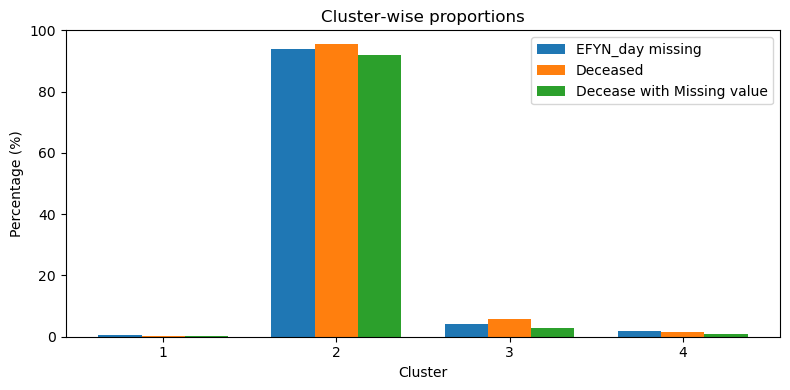

In [75]:
summary = []
for clus, g in df_ana.groupby('Cluster_Labels'):
    n_tot        = len(g)
    n_nan        = g['EFYN_day'].isna().sum()
    n_death      = (g['death_label'] == 1).sum()
    n_nan_death  = g['EFYN_day'].isna() & (g['death_label'] == 1)
    n_nan_death  = n_nan_death.sum()

    summary.append({
        "Cluster"        : clus,
        # ── 표(프린트용) 문자열 ────────────────────────────
        "n of EFYN_day(NaN)"   : f"{n_nan} / {n_tot} ({n_nan/n_tot:.2%})",
        "n of Deceased"     : f"{n_death} / {n_tot} ({n_death/n_tot:.2%})",
        "n of EFYN_day(NaN) +Deceased"  : f"{n_nan_death} / {n_tot} ({n_nan_death/n_tot:.2%})",
        # ── 그래프용 숫자(비율) ────────────────────────────
        "EFYN_NaN_pct"   : n_nan / n_tot * 100,
        "Deaths_pct"     : n_death / n_tot * 100,
        "NaN+Death_pct"  : n_nan_death / n_tot * 100
    })

summary_df = (pd.DataFrame(summary)
                .set_index("Cluster")
                .sort_index())

# 보기 좋은 표 출력
print("▶ Cluster‑wise overview")
print(summary_df[["n of EFYN_day(NaN)", "n of Deceased", "n of EFYN_day(NaN) +Deceased"]])

# -----------------------------------------------------------
# ❷ 시각화 : 비율 막대그래프
# -----------------------------------------------------------
plot_df = summary_df[["EFYN_NaN_pct", "Deaths_pct", "NaN+Death_pct"]]

x = np.arange(len(plot_df))            # 클러스터 위치
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, plot_df['EFYN_NaN_pct'],  width, label='EFYN_day missing')
ax.bar(x        , plot_df['Deaths_pct'],     width, label='Deceased')
ax.bar(x + width, plot_df['NaN+Death_pct'],  width, label='Decease with Missing value')

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.astype(str))
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Cluster')
ax.set_ylim(0, 100)
ax.set_title('Cluster‑wise proportions')
ax.legend()
plt.tight_layout()
plt.show()

In [81]:
print(df_ana['birthdt'].info())
print(df_ana['death_dt'].info())

<class 'pandas.core.series.Series'>
Int64Index: 20352 entries, 0 to 20412
Series name: birthdt
Non-Null Count  Dtype         
--------------  -----         
0 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 318.0 KB
None
<class 'pandas.core.series.Series'>
Int64Index: 20352 entries, 0 to 20412
Series name: death_dt
Non-Null Count  Dtype         
--------------  -----         
0 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 318.0 KB
None


                count        mean  median        std
Cluster_Labels                                      
1                  25   24.360000    20.0  14.067930
2                2285   12.757549     7.0  15.186316
3                 171  137.461988   116.0  72.713722
4                 110   71.763636    58.5  44.859808


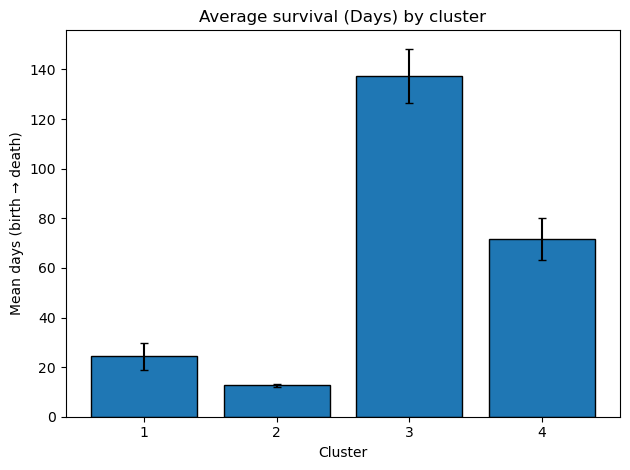

In [89]:
df_ana['birthdt']  = pd.to_datetime(df_ana['birthdt'],  format='%Y-%m-%d', errors='coerce')
df_ana['death_dt'] = pd.to_datetime(df_ana['death_dt'], format='%Y-%m-%d', errors='coerce')
df_ana['survival_days'] = (df_ana['death_dt'] - df_ana['birthdt']).dt.days

valid = df_ana['survival_days'].notna()             # 사망 기록이 있는 환자만 선택
summary = (
    df_ana.loc[valid]
          .groupby('Cluster_Labels')['survival_days']
          .agg(['count', 'mean', 'median', 'std'])
          .sort_index()
)
print(summary)

means = summary['mean']
ses   = summary['std'] / summary['count']**0.5     # 표준오차
ci95  = 1.96 * ses                                 # 95 % 신뢰구간

plt.bar(means.index.astype(str), means, yerr=ci95, edgecolor='black', capsize=3)
plt.ylabel('Mean days (From Birth to Death)')
plt.xlabel('Cluster')
plt.title('Average survival (Days) by cluster')
plt.tight_layout()
plt.show()

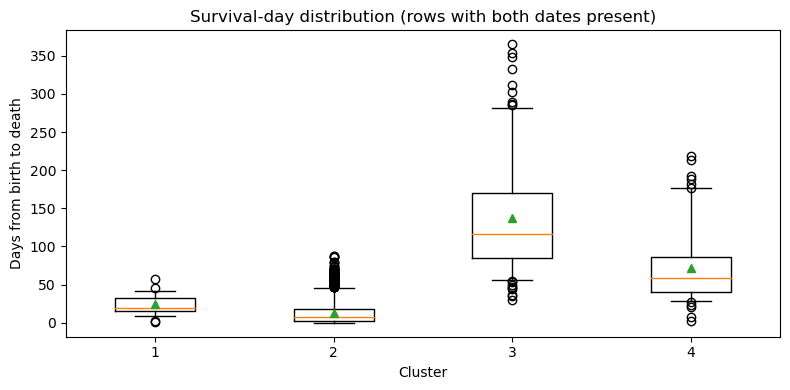

                count        mean  median        std
Cluster_Labels                                      
1                  25   24.360000    20.0  14.067930
2                2285   12.757549     7.0  15.186316
3                 171  137.461988   116.0  72.713722
4                 110   71.763636    58.5  44.859808


In [91]:
# 1) 두 날짜 모두 있는 행만 선택
mask   = df_ana['birthdt'].notna() & df_ana['death_dt'].notna()
df_sub = df_ana.loc[mask].copy()

# 2) 생존 일수 다시 계산
df_sub['survival_days'] = (df_sub['death_dt'] - df_sub['birthdt']).dt.days

# 3) 클러스터별 데이터 배열
clusters = sorted(df_sub['Cluster_Labels'].unique())
box_data = [df_sub.loc[df_sub['Cluster_Labels'] == c, 'survival_days'].values
            for c in clusters]

# 4) Box‑and‑whisker plot
plt.figure(figsize=(8, 4))
plt.boxplot(
    box_data,
    labels=[str(c) for c in clusters],
    showmeans=True,        # ◆ : 표본평균 표시
    meanline=False,
    whis=(5, 95)           # 수염을 5–95 퍼센타일로 제한(극단값 완화)
)

plt.ylabel('Days (From birth to death)')
plt.xlabel('Cluster')
plt.title('Survival‑day distribution')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 보조적으로, 클러스터별 표본 수·평균·중앙값 확인
summary = (
    df_sub.groupby('Cluster_Labels')['survival_days']
          .agg(['count', 'mean', 'median', 'std'])
          .sort_index()
)
print(summary)

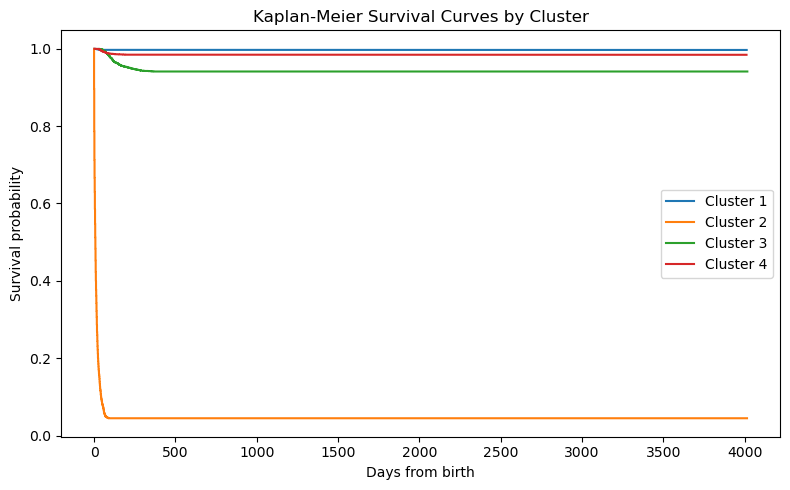

In [98]:
try:
    from lifelines import KaplanMeierFitter
    lifelines_available = True
except ImportError:
    lifelines_available = False

# --- Load the data (expects df_ana already available in notebook scope) ---
# NOTE: Adapt the following line if df_ana is not yet in memory.
try:
    df = df_ana.copy()
except NameError:
    raise NameError("⚠️  df_ana is not defined in the current session.")

# Ensure datetime conversion
df['birthdt'] = pd.to_datetime(df['birthdt'], format='%Y-%m-%d', errors='coerce')
df['death_dt'] = pd.to_datetime(df['death_dt'], format='%Y-%m-%d', errors='coerce')

# Define an end-of-follow‑up date (use dataset extraction date or today)
censor_date = pd.Timestamp('2023-12-31')  # adjust if a better cut‑off exists

# Durations & event indicator
df['duration'] = np.where(
    df['death_dt'].notna(),
    (df['death_dt'] - df['birthdt']).dt.days,
    (censor_date - df['birthdt']).dt.days
)
df['event_observed'] = df['death_dt'].notna().astype(int)

# Filter rows where both dates are present or at least birthdt present
df = df[df['birthdt'].notna() & df['duration'].notna()]

# Prepare plot
plt.figure(figsize=(8, 5))

if lifelines_available:
    kmf = KaplanMeierFitter()
    for cluster in sorted(df['Cluster_Labels'].unique()):
        mask = df['Cluster_Labels'] == cluster
        kmf.fit(
            durations=df.loc[mask, 'duration'],
            event_observed=df.loc[mask, 'event_observed'],
            label=f'Cluster {cluster}'
        )
        kmf.plot(ci_show=False)  # hides confidence band for clarity
else:
    # Manual survival curve computation (basic)
    for cluster in sorted(df['Cluster_Labels'].unique()):
        sub = df.loc[df['Cluster_Labels'] == cluster, ['duration', 'event_observed']]
        # Kaplan‑Meier estimate
        sub = sub.sort_values('duration')
        n = len(sub)
        surv = 1.0
        times, survival = [], []
        for t, e in zip(sub['duration'], sub['event_observed']):
            times.append(t)
            if e == 1:
                surv *= (n - 1) / n
            survival.append(surv)
            n -= 1
        plt.step(times, survival, where='post', label=f'Cluster {cluster}')

plt.xlabel('Days from birth')
plt.ylabel('Survival probability')
plt.title('Kaplan‑Meier Survival Curves by Cluster')
plt.legend()
plt.tight_layout()
plt.show()

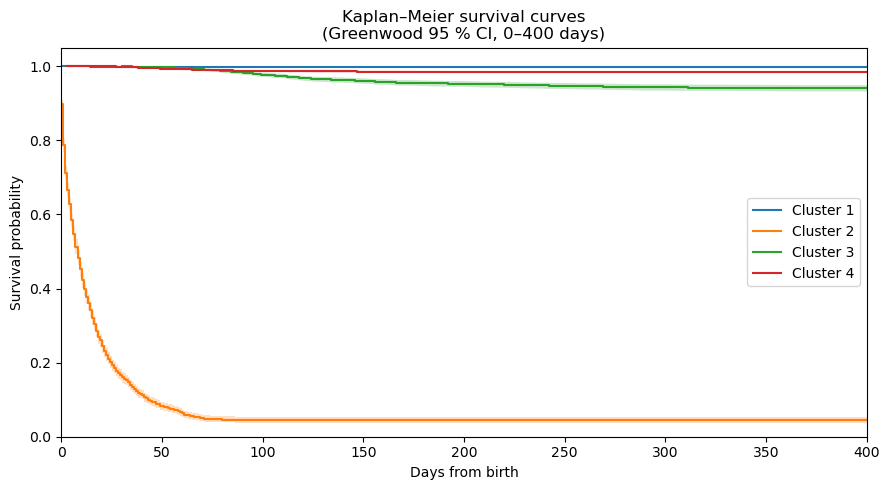

In [105]:
def km_greenwood(durations, events, alpha=0.05):
    df_t = (pd.DataFrame({'t': durations, 'e': events})
              .groupby('t')
              .agg(d=('e', 'sum'), n=('e', 'size'))
              .sort_index())
    df_t['n_at_risk'] = df_t['n'][::-1].cumsum()[::-1]

    S, var = [], []
    surv, g_sum = 1.0, 0.0
    for _, r in df_t.iterrows():
        surv *= 1 - r.d / r.n_at_risk
        g_sum += r.d / (r.n_at_risk * (r.n_at_risk - r.d))
        S.append(surv)
        var.append(surv**2 * g_sum)

    t   = df_t.index.to_numpy()
    S   = np.array(S)
    se  = np.sqrt(var)

    z = 1.96
    lnlnS = np.log(-np.log(S))
    delta = z * se / (S * np.log(S))
    lo = np.exp(-np.exp(lnlnS + delta))
    hi = np.exp(-np.exp(lnlnS - delta))
    return t, S, lo, hi

# ── 플롯 ────────────────────────────────────────────────
plt.figure(figsize=(9, 5))

for c in sorted(df['Cluster_Labels'].unique()):
    m = df['Cluster_Labels'] == c
    t, S, lo, hi = km_greenwood(df.loc[m, 'duration'].values,
                                df.loc[m, 'event_observed'].values)
    plt.step(t, S, where='post', label=f'Cluster {c}')
    plt.fill_between(t, lo, hi, step='post', alpha=0.25)

plt.xlabel('Days from birth')
plt.ylabel('Survival probability')
plt.title('Kaplan–Meier survival curves\n(Greenwood 95 % CI, 0–400 days)')
plt.ylim(0, 1.05)
plt.xlim(0, 400)                     # ← 여기서 0–400 일로 한정
plt.xticks(np.arange(0, 401, 50))    # (선택) 50 일 간격 눈금
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  g_sum += r.d / (r.n_at_risk * (r.n_at_risk - r.d))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:25: RuntimeWarning: invalid value encountered in scalar multiply
  var.append(surv**2 * g_sum)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:31: RuntimeWarning: divide by zero encountered in log
  ll    = np.exp(-np.exp(np.log(-np.log(S)) + z * se / (S*np.log(S))))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:31: RuntimeWarning: invalid value encountered in multiply
  ll    = np.exp(-np.exp(np.log(-np.log(S)) + z * se / (S*np.log(S))))
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19388\2680860368.py:32: RuntimeWarning: divide by zero encountered in log
  ul    = np.exp(-np.exp(np.log(-np.log(S)) - z * se / (S*np.log(S))))
C:\Users\Public\Documents\EST

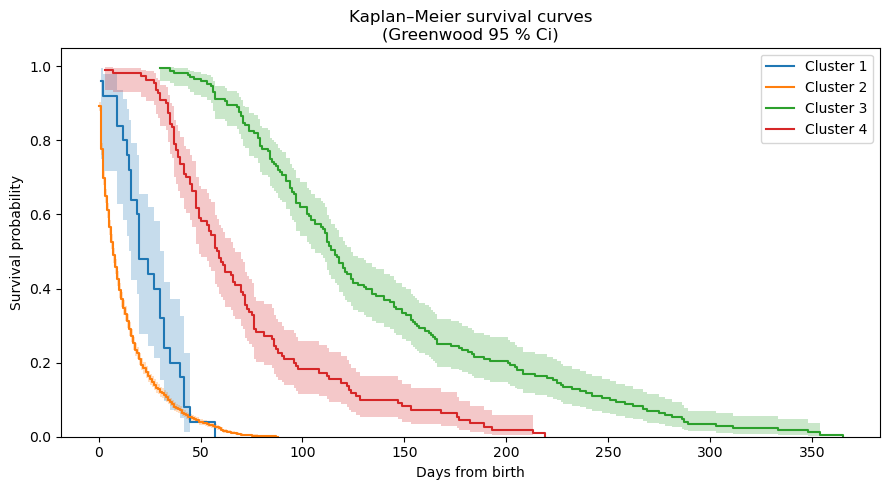

                count        mean  median        std
Cluster_Labels                                      
1                  25   24.360000    20.0  14.067930
2                2285   12.757549     7.0  15.186316
3                 171  137.461988   116.0  72.713722
4                 110   71.763636    58.5  44.859808


In [103]:
# 1) 두 날짜 모두 존재하는 행만 추출
mask   = df_ana['birthdt'].notna() & df_ana['death_dt'].notna()
df_sub = df_ana.loc[mask].copy()

df_sub['birthdt']  = pd.to_datetime(df_sub['birthdt'])
df_sub['death_dt'] = pd.to_datetime(df_sub['death_dt'])
df_sub['duration'] = (df_sub['death_dt'] - df_sub['birthdt']).dt.days
df_sub['event_observed'] = 1        # 두 날짜 모두 있으면 ‘사건(사망)=1’

# 2) Greenwood KM 함수
def km_greenwood(durations, events, alpha=0.05):
    tbl = (pd.DataFrame({'t': durations, 'e': events})
             .groupby('t')
             .agg(d=('e', 'sum'), n=('e', 'size'))
             .sort_index())
    tbl['n_at_risk'] = tbl['n'][::-1].cumsum()[::-1]

    S, var = [], []
    surv   = 1.0
    g_sum  = 0.0
    for _, r in tbl.iterrows():
        surv *= 1 - r.d / r.n_at_risk
        g_sum += r.d / (r.n_at_risk * (r.n_at_risk - r.d))
        S.append(surv)
        var.append(surv**2 * g_sum)

    t     = tbl.index.to_numpy()
    S     = np.array(S)
    se    = np.sqrt(var)
    z     = 1.96 if alpha == 0.05 else abs(np.quantile(np.random.normal(size=1_000_000), 1 - alpha/2))
    ll    = np.exp(-np.exp(np.log(-np.log(S)) + z * se / (S*np.log(S))))
    ul    = np.exp(-np.exp(np.log(-np.log(S)) - z * se / (S*np.log(S))))
    return t, S, ll, ul

# 3) 클러스터별 KM 곡선 + CI
plt.figure(figsize=(9, 5))
for c in sorted(df_sub['Cluster_Labels'].unique()):
    m = df_sub['Cluster_Labels'] == c
    t, S, lo, hi = km_greenwood(df_sub.loc[m, 'duration'].values,
                                df_sub.loc[m, 'event_observed'].values)
    plt.step(t, S, where='post', label=f'Cluster {c}')
    plt.fill_between(t, lo, hi, step='post', alpha=0.25)

plt.xlabel('Days from birth')
plt.ylabel('Survival probability')
plt.title('Kaplan–Meier survival curves\n(Greenwood 95 % Ci)')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# 4) Table
km_summary = (
    df_sub.groupby('Cluster_Labels')['duration']
          .agg(count='size',
               mean='mean',
               median='median',
               std='std')
          .sort_index()
)
print(km_summary)

In [ ]:
'''## P-PCA :::::::'''

In [10]:
# ipt_dir = f'{crt_path}/Results/M14_dM06/2_SurvOnly/1_ALL/C4'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/2_NEC only/C4'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/0531~/WholeExp/C43'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/C4_'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/1_Whole/2_NEC only/C4'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/0711/WholeExp/C4_'
ipt_dir = f'{crt_path}/Results/M15_dataset08/P1_1_Whole/#P1_NEC/P1_C4'

df_ana = pd.read_csv(os.path.join(ipt_dir, "df_scd_4clustered.csv"))
# df_ana = pd.read_csv(os.path.join(ipt_dir, "df_scd_clustered.csv"))
# df_ana = pd.read_csv(os.path.join(ipt_dir, "KNN_df_combined.csv"))
df_ana.set_index('idx_code', inplace=True)
# df_ana = df_ana.rename(columns={'Unnamed: 0': 'col_name'})
# 'death36' 컬럼 제외
if 'death36' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death36'])
if 'death_label' in df_ana.columns:
    df_ana = df_ana.drop(columns=['death_label'])
datetime_cols = [
    'ntetdt', 'ntetdty', 'date362', 'date36', 'menidt', 'pdaddth', 'pdaddt',
    'birthdt', 'admd', 'birtm', 'bird', 'efydt', 'death_dt', 'iperrdt'
]
df_ana = df_ana.drop(columns=[c for c in datetime_cols if c in df_ana.columns])

# Cluster Labels 분리
cluster_labels = df_ana['Cluster_Labels']
df_scd = df_ana.drop(columns=['Cluster_Labels'])    # , 'idx_code' --> Index

df_scd

,sex_sys_val,apgs1,apgs5,mage,gran,parn,bbph,bbphuk,bbbe,bbbeuk,...,bpia_3,oxyt28_1,oxyt28_3,oxyt28_2,oxyt28_4,arre28_0,arre28_6,arre28_7,seps_1,seps_2
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,-0.361034,-1.032974,-1.020264,-0.760507,-0.636012,0.862903,0.0,-0.064258,0.0,...,0,1,0,0,0,1,0,0,1,0
1,1,-0.361034,-1.032974,0.360486,-0.760507,-0.636012,0.179879,0.0,-0.064258,0.0,...,0,0,1,0,0,0,1,0,0,1
2,1,0.117458,-0.497525,-1.710639,-0.760507,-0.636012,1.545927,0.0,0.891358,0.0,...,0,1,0,0,0,1,0,0,1,0
3,1,0.595950,0.037925,-1.710639,-0.760507,-0.636012,2.228951,0.0,1.740794,0.0,...,0,1,0,0,0,1,0,0,0,1
4,1,-0.361034,-1.032974,0.590611,1.748735,0.768667,0.960478,0.0,0.307370,0.0,...,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,0.117458,0.573375,-2.401014,-0.760507,-0.636012,0.277454,0.0,-0.515521,0.0,...,0,1,0,0,0,1,0,0,0,1
20409,1,-0.361034,0.037925,1.050861,0.912321,0.768667,-0.112846,0.0,0.280825,0.0,...,0,0,1,0,0,0,1,0,0,1
20410,0,0.117458,0.037925,-0.790139,0.075907,-0.636012,0.472603,0.0,0.546274,0.0,...,0,0,0,1,0,1,0,0,1,0


✅ Cumulative variance ≥ 95% at 28 PCs


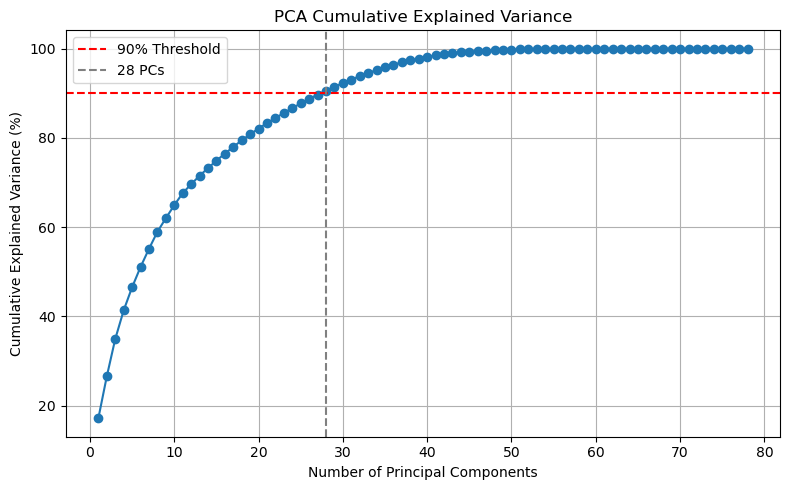

In [18]:
from sklearn.experimental import enable_iterative_imputer  # noqa: needed to enable IterativeImputer
from sklearn.impute import IterativeImputer

# 1. 데이터 준비
data = df_scd.values.astype(float)

# 2. 결측값 보간 using IterativeImputer
imputer = IterativeImputer(random_state=0, max_iter=30, tol=1e-3)
data_imputed = imputer.fit_transform(data)

# 3. PCA 수행
pca = PCA()
X_pca = pca.fit_transform(data_imputed)

explained_ratio = pca.explained_variance_ratio_
cumulative_explained = np.cumsum(explained_ratio)

# 4. 설명 가능한 분산이 90% 넘는 최소 PC 수 선택
n_components_90 = np.argmax(cumulative_explained >= 0.90) + 1
print(f"✅ Cumulative variance ≥ 95% at {n_components_90} PCs")

# 5. 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained) + 1), cumulative_explained * 100, marker='o')
plt.axhline(y=90, color='red', linestyle='--', label='90% Threshold')
plt.axvline(x=n_components_90, color='grey', linestyle='--', label=f'{n_components_90} PCs')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 6. 최종 데이터프레임 구성
columns = [f'PC{i+1}' for i in range(n_components_90)]
df_pca = pd.DataFrame(X_pca[:, :n_components_90], columns=columns, index=df_scd.index)
df_pca['Cluster_Labels'] = cluster_labels

In [65]:
data = df_scd.values.astype(float)
max_components = min(df_scd.shape[1], 30)  # 과도한 반복 방지

explained_variances = []
models = []

for n in range(1, max_components+1):
    model = PPCA()
    model.fit(data, d=n)  # <== 핵심 수정: n_components → d
    explained_variances.append(model.var_exp)
    models.append(model)

# 누적 설명 분산 계산
cum_var = np.cumsum(explained_variances)
cum_var_norm = cum_var / cum_var[-1]
n_components_90 = np.argmax(cum_var_norm >= 0.90) + 1

print(f"n of PC Axis of explainable thr-90% via PPCA: {n_components_90}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var_norm)+1), cum_var_norm * 100, marker='o')
plt.axhline(90, color='red', linestyle='--', label='90% Explained Variance')
plt.axvline(n_components_90, color='grey', linestyle='--', label=f'{n_components_90} PCs')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PPCA Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 최종 모델로 PC 축 추출
final_model = models[n_components_90 - 1]
X_ppca = final_model.transform()

columns = [f'PC{i+1}' for i in range(n_components_90)]
df_ppca = pd.DataFrame(X_ppca, columns=columns, index=df_scd.index)
df_ppca['Cluster_Labels'] = cluster_labels

LinAlgError: 0-dimensional array given. Array must be at least two-dimensional

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\ppca\_ppca.py:23: RuntimeWarning: invalid value encountered in divide
  return (X - self.means) / self.stds


   Principal Component  Explained Variance Ratio  \
0                  PC1                  0.098654   
1                  PC2                  0.172730   
2                  PC3                  0.217444   
3                  PC4                  0.250536   
4                  PC5                  0.281211   
..                 ...                       ...   
76                PC77                  0.999258   
77                PC78                  1.000025   
78                PC79                  1.000520   
79                PC80                  1.000710   
80                PC81                  1.000781   

    Cumulative Explained Variance  
0                        0.098654  
1                        0.271384  
2                        0.488828  
3                        0.739364  
4                        1.020575  
..                            ...  
76                      57.182582  
77                      58.182607  
78                      59.183127  
79             

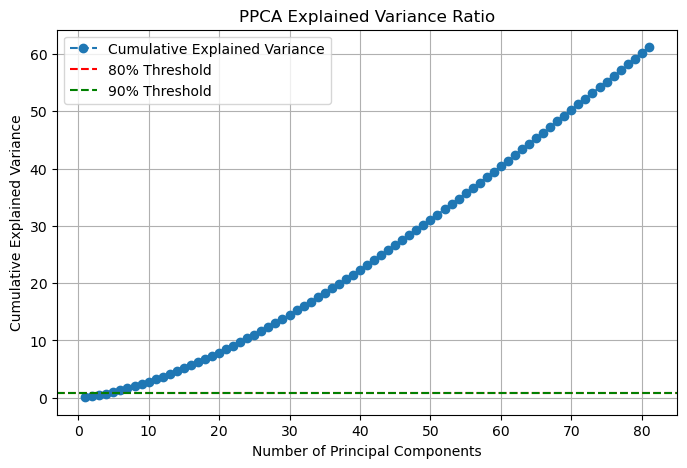

In [72]:
# # PCA 수행 (설명 가능한 분산 비율 계산)
ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=81)  # 주성분 개수를 3개로 설정 (원하는 수로 조정 가능)

# 변환된 데이터(PC Scores)
df_pca = pd.DataFrame(ppca_model.transform(), columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37', 'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46', 'PC47', 'PC48', 'PC49', 'PC50', 'PC51', 'PC52', 'PC53', 'PC54', 'PC55', 'PC56', 'PC57', 'PC58', 'PC59', 'PC60', 'PC61', 'PC62', 'PC63', 'PC64', 'PC65', 'PC66', 'PC67', 'PC68', 'PC69', 'PC70', 'PC71', 'PC72', 'PC73', 'PC74', 'PC75', 'PC76', 'PC77', 'PC78', 'PC79', 'PC80', 'PC81']
                      , index=df_ana.index)
df_pca['Cluster_Labels'] = cluster_labels

# ppca_model = PPCA()
# ppca_model.fit(df_ana.values, d=3)  # 주성분 개수를 3개로 설정 (원하는 수로 조정 가능)

# # 변환된 데이터(PC Scores)
# df_pca = pd.DataFrame(ppca_model.transform(), columns=['PC1', 'PC2', 'PC3'], index=df_ana.index)
# df_pca['Cluster_Labels'] = cluster_labels

# 설명된 분산비율 확인
explained_variance_ratio = ppca_model.var_exp
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 설명된 분산 출력
explained_variance_result = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Explained Variance": cumulative_explained_variance
})

print(explained_variance_result)

# 결과 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio)+1), cumulative_explained_variance, marker='o', linestyle='--', label='Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PPCA Explained Variance Ratio')
plt.axhline(y=0.8, color='r', linestyle='--', label="80% Threshold")
plt.axhline(y=0.9, color='g', linestyle='--', label="90% Threshold")
plt.legend()
plt.grid()
plt.show()

In [15]:
dim = 34

ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=dim)

components = [f'PC{i+1}' for i in range(dim)]
pca_loadings = pd.DataFrame(ppca_model.C,
                            index=df_scd.columns,
                            columns=components)

# 1) 각 PC에서 |loading| 기준으로 전체 feature를 정렬
ranked = {
    pc: pca_loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .index
    for pc in components
}

# 2) 집계용 딕셔너리 → 하나의 DataFrame
n_feat = len(df_scd.columns)
table = {'Sorted Index': range(1, n_feat + 1)}

for pc in components:
    feats = ranked[pc]
    loads = pca_loadings.loc[feats, pc].values
    table[f'{pc} : Feature name'] = feats
    table[f'{pc} : PC Loading']  = loads

combined_df = pd.DataFrame(table).set_index('Sorted Index')

mapping_path = f'{crt_path}/Results/M15_dataset08/1_Whole/1_ALL/C4'
mapping_df   = pd.read_excel(os.path.join(mapping_path, 'C4_sort(ana+desc)_EN.xlsx'))
mapping_dict = dict(zip(mapping_df['col_name'], mapping_df['Feature name']))

# 각 PC에 대해 'Feature_EN' 열 추가
for pc in components:
    src_col = f'{pc} : Feature name'
    en_col  = f'{pc} : Feature_EN'
    combined_df[en_col] = combined_df[src_col].map(mapping_dict).fillna('')

# 3) 각 PC 절대값 총합 행 추가
total_row = {col: '' for col in combined_df.columns}
for pc in components:
    total_row[f'{pc} : PC Loading'] = pca_loadings[pc].abs().sum()
combined_df.loc['PC Loading Summary'] = total_row

# 칼럼순서 변경
new_order = []
for pc in components:
    new_order += [
        f'{pc} : Feature name',
        f'{pc} : Feature_EN',
        f'{pc} : PC Loading'
    ]

combined_df = combined_df[new_order]

# 4) 결과 확인
combined_df

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22888\1645533288.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df[en_col] = combined_df[src_col].map(mapping_dict).fillna('')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22888\1645533288.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df[en_col] = combined_df[src_col].map(mapping_dict).fillna('')


,PC1 : Feature name,PC1 : Feature_EN,PC1 : PC Loading,PC2 : Feature name,PC2 : Feature_EN,PC2 : PC Loading,PC3 : Feature name,PC3 : Feature_EN,PC3 : PC Loading,PC4 : Feature name,...,PC31 : PC Loading,PC32 : Feature name,PC32 : Feature_EN,PC32 : PC Loading,PC33 : Feature name,PC33 : Feature_EN,PC33 : PC Loading,PC34 : Feature name,PC34 : Feature_EN,PC34 : PC Loading
Sorted Index,,,,,,,,,,,,,,,,,,,,,
1,oxyt28_1,Oxygen therapy at day 28 (Neg),0.244719,oxyt28_4,Oxygen therapy at day 28 (Unknown),-0.333341,prep_2,Conception method (IVF),-0.345061,htn_1,...,-0.658401,sex_sys_val,Sex (Male),-0.466508,amni_3,Amniotic-fluid volume (Polyhydramnios),0.565188,sex_sys_val,Sex (Male),-0.688153
2,eythtran_0,Red-blood-cell transfusion (Neg),0.239371,efyn,Enteral feeds ≥100 ml/kg/day before discharge,0.326858,prep_1,Conception method (Natural),0.345061,htn_2,...,-0.347992,htn_3,Maternal hypertension (Chronic),0.413964,htn_3,Maternal hypertension (Chronic),-0.286177,amni_4,Amniotic-fluid volume (Unknown),-0.276979
3,eythtran_1,Red-blood-cell transfusion (Pos),-0.239371,niarvrpd,Non-invasive-ventilation duration,0.276094,mulg_multiple,Singleton/multiple gestation information,-0.333642,prom_0,...,0.275147,amni_4,Amniotic-fluid volume (Unknown),0.229420,chor_Unknown,Histologic chorio-amnionitis (Unknown),-0.278844,oxyt28_2,Oxygen therapy at day 28 (FiO₂ < 30 %),-0.243937
4,sft_1,Surfactant administration (Pos),-0.227415,arre28_0,Ventilation at day 28 (Neg),-0.257764,mulg_singleton,Singleton/multiple gestation information,0.333642,prom_1,...,-0.208705,aoxyuppd,Supplemental oxygen/flow duration,0.225423,eythtran_1,Red-blood-cell transfusion (Pos),0.256793,apgs5,5-minute Apgar score,-0.239669
5,sft_0,Surfactant administration (Neg),0.227415,arre28_7,Non-invasive ventilation at day 28,0.231163,bpia_1,Birth place (In-hospital),-0.215892,mulg_singleton,...,-0.199870,oxyt28_2,Oxygen therapy at day 28 (FiO₂ < 30 %),0.225246,eythtran_0,Red-blood-cell transfusion (Neg),-0.256793,apgs1,1-minute Apgar score,-0.208566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,ster_1,Antenatal steroid use (Pos),-0.003630,mulg_singleton,Singleton/multiple gestation information,-0.008200,prom_0,Premature rupture of membranes (PROM) (Neg),0.005827,dm_1,...,0.002630,efyn,Enteral feeds ≥100 ml/kg/day before discharge,0.006622,delm_2,Mode of delivery (Caesarean section),0.000524,meni_1,Meningitis (Pos),0.002104
76,mage,Maternal age,0.002972,sex_sys_val,Sex (Male),-0.003589,pda_non-treatment,Patent ductus arteriosus (Untreated),-0.003627,dm_0,...,-0.002630,EFYN_day,Enteral feeds ≥100 ml/kg/day before discharge,0.005760,resu_0,Initial resuscitation required (Neg),0.000375,ibif_1,Congenital infection (Pos),0.001307
77,pda_unknown,Patent ductus arteriosus (Unknown),-0.002202,chor_1,Histologic chorio-amnionitis (Pos),0.002538,sex_sys_val,Sex (Male),-0.002676,PDA_TRD,...,0.001258,prom_Unknown,Premature rupture of membranes (PROM) (Unknown),-0.005164,prom_Unknown,Premature rupture of membranes (PROM) (Unknown),0.000312,ibif_0,Congenital infection (Neg),-0.001307


In [16]:
combined_df.to_csv(os.path.join(ipt_dir, "PC Loadings_PosNeg_34.csv")
                   , index=True, encoding='utf-8-sig'
                  )

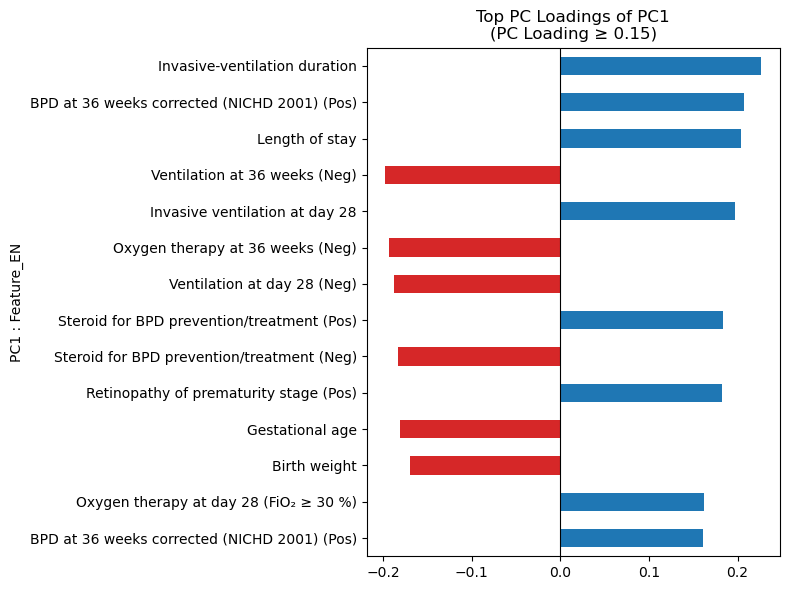

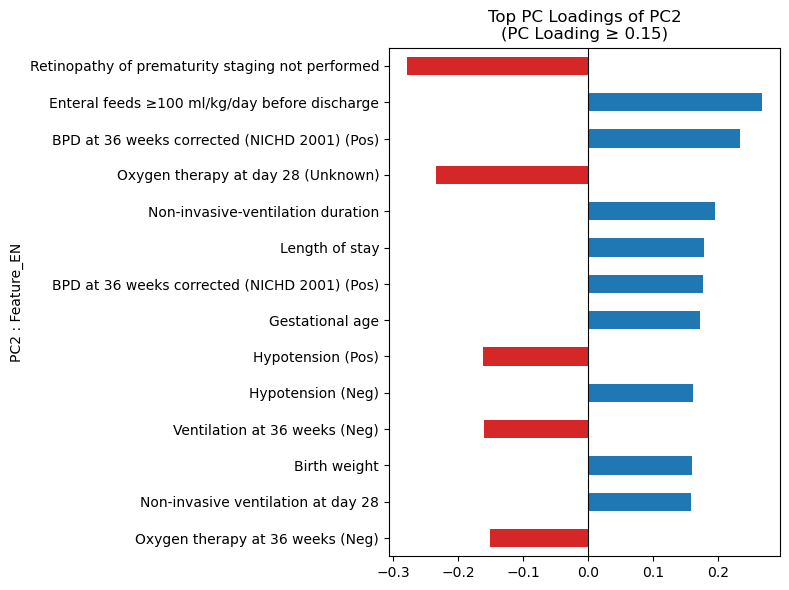

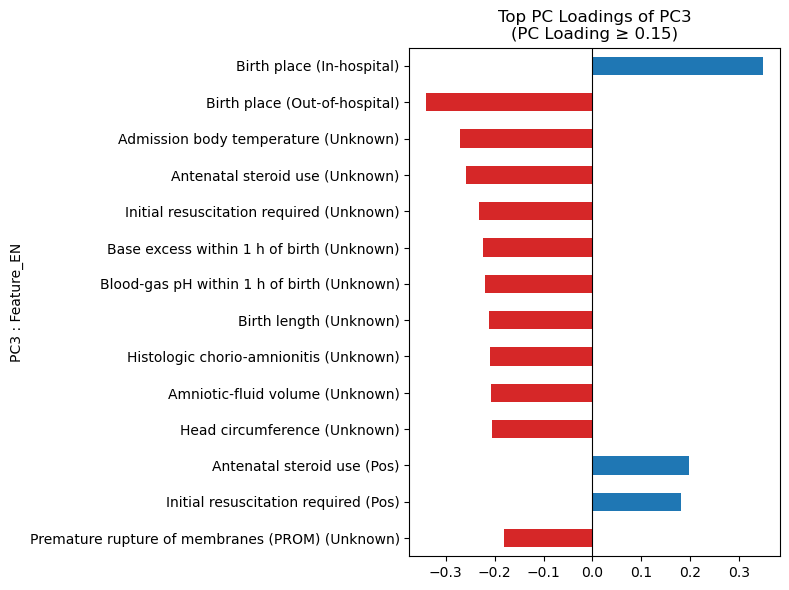

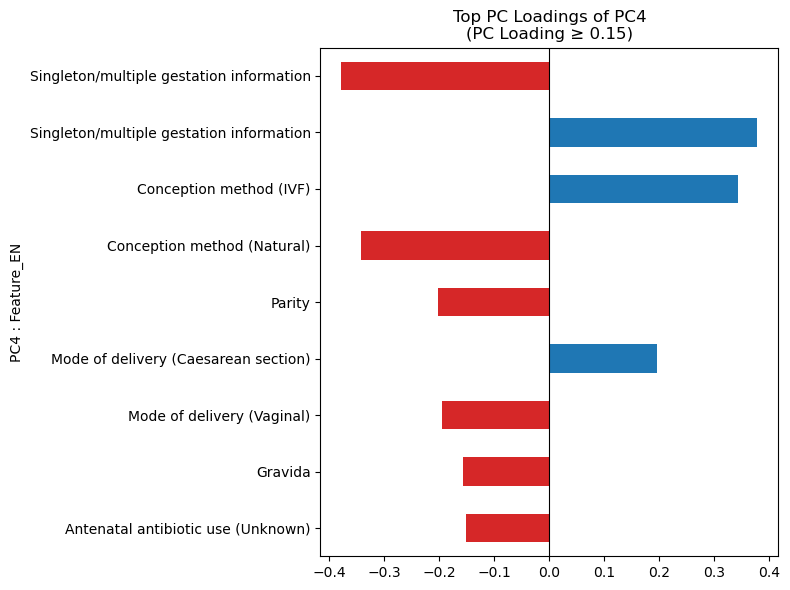

In [43]:
top_dfs = {}
for pc in components:
    feat_col = f'{pc} : Feature name'
    en_col   = f'{pc} : Feature_EN'
    load_col = f'{pc} : PC Loading'
    tmp = (combined_df
           .loc[combined_df.index != 'PC Loading Summary',
                [feat_col, en_col, load_col]]
           .dropna())
    series = pd.Series(tmp[load_col].values,
                       index=tmp[en_col],
                       name='loading')
    top_dfs[pc] = series.to_frame()

# 8) Bar-plot 함수 정의

def loading_barplots(loadings_dict: dict[str, pd.DataFrame],
                     threshold: float = 0.0,
                     top_n: int = 20,
                     figsize: tuple[int, int] = (10, 8),
                     left_margin: float = 0.3) -> None:
    """
    Draw one horizontal bar-plot per PC, with larger figure and right-shifted axes.
    * threshold   –  |loading| cut-off; variables below are dropped
    * top_n       –  max number of variables to plot per PC
    * figsize     –  figure size (width, height)
    * left_margin –  fraction of figure width to reserve as left padding
    """
    for pc, df in loadings_dict.items():
        vec = df['loading']
        vec = vec[vec.abs() >= threshold]
        if vec.empty:
            print(f'{pc}: no loadings ≥ {threshold}')
            continue

        vec = vec.head(top_n)[::-1]
        colours = ['tab:red' if x < 0 else 'tab:blue' for x in vec]

        # 새 Figure/Axes 생성
        fig, ax = plt.subplots(figsize=figsize)
        vec.plot(kind='barh', ax=ax, color=colours)
        ax.axvline(0, color='black', lw=0.8)

        # 좌측 여백 조정 (그래프를 오른쪽으로 이동)
        fig.subplots_adjust(left=left_margin, right=0.95)

        ax.set_title(f'Top PC Loadings of {pc}\n(PC Loading ≥ {threshold})')
        plt.tight_layout()
        plt.show()

# 9) 플롯 실행
loading_barplots(
    top_dfs,
    threshold=0.15,
    top_n=30,
    figsize=(8, 6),
    left_margin=0.35
)

In [44]:
# 1) 저장 경로 준비
os.makedirs(ipt_dir, exist_ok=True)
pdf_path = os.path.join(ipt_dir, 'PC_Loadings_4x1.pdf')

# 2) 파라미터
threshold = 0.15
top_n     = 30
n_rows    = 4
n_cols    = 1
figsize   = (8, 20)    # 너비 8인치, 높이 20인치

# 3) 4×1 그리드에 각 PC 플롯
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
axes = axes.flatten()

for ax, pc in zip(axes, components):
    vec = top_dfs[pc]['loading']
    vec = vec[vec.abs() >= threshold]
    if vec.empty:
        ax.text(0.5, 0.5, f'No loadings ≥ {threshold}',
                ha='center', va='center', fontsize=12)
        ax.axis('off')
        continue

    vec = vec.head(top_n)[::-1]
    colours = ['tab:red' if x < 0 else 'tab:blue' for x in vec]

    vec.plot(kind='barh', ax=ax, color=colours)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Top PC Loadings of {pc}\n(|loading| ≥ {threshold})')
    ax.set_xlabel('Loading')

# 4) 레이아웃 정리 및 PDF 저장
plt.tight_layout()
with PdfPages(pdf_path) as pdf:
    pdf.savefig(fig)
plt.close(fig)

print(f'Saved 4×1 PC loading plots to {pdf_path}')

Saved 4×1 PC loading plots to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/1_Whole/2_NEC only/C4\PC_Loadings_4x1.pdf


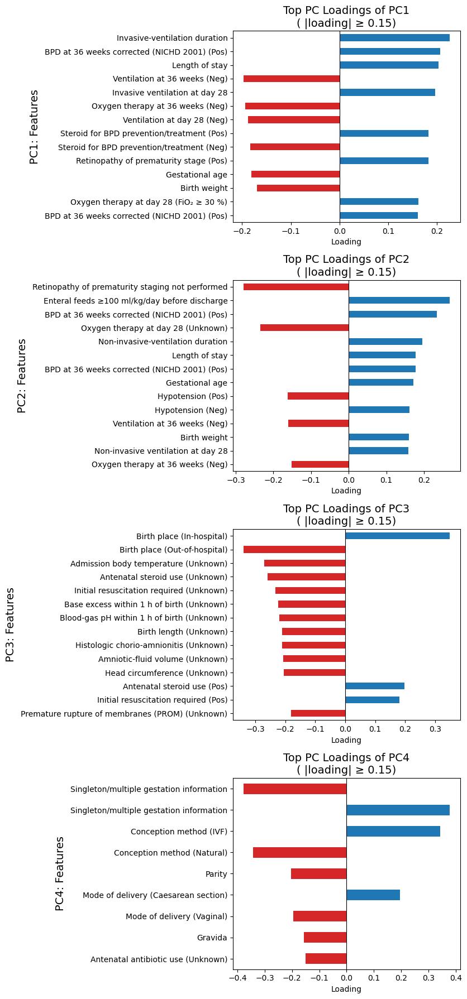

Saved 4×1 PC loading plots to C:\Dev_AIWM\jupyter\KNN\1212_M02\creatures/Results/M15_dataset08/1_Whole/2_NEC only/C4\PC_Loadings_4x1.pdf


In [59]:
# 1) 저장 경로 준비
os.makedirs(ipt_dir, exist_ok=True)
pdf_path = os.path.join(ipt_dir, 'PC_Loadings_4x1.pdf')

# 2) 파라미터
threshold = 0.15
top_n     = 30
n_rows    = 4
n_cols    = 1
figsize   = (5, 18)

# 3) Plotting in 4*1 Grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
axes = axes.flatten()

for ax, pc in zip(axes, components):
    vec = top_dfs[pc]['loading']
    vec = vec[vec.abs() >= threshold]
    if vec.empty:
        ax.text(0.5, 0.5, f'No loadings ≥ {threshold}',
                ha='center', va='center', fontsize=13)
        ax.axis('off')
        continue

    vec = vec.head(top_n)[::-1]
    colours = ['tab:red' if x < 0 else 'tab:blue' for x in vec]

    vec.plot(kind='barh', ax=ax, color=colours)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Top PC Loadings of {pc}\n( |loading| ≥ {threshold})', fontsize=14)
    ax.set_xlabel('Loading')

    ax.set_ylabel(f'{pc}: Features', fontsize=14, labelpad=6)

# Cleaning layouts
plt.tight_layout()
plt.subplots_adjust(left=0.15)

with PdfPages(pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight', pad_inches=0.2)

plt.show()
plt.close(fig)

print(f'Saved 4×1 PC loading plots to {pdf_path}')

In [8]:
dim = 4

ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=dim)

components = [f'PC{i+1}' for i in range(dim)]
pca_loadings = pd.DataFrame(ppca_model.C,
                            index=df_scd.columns,
                            columns=components)

# 1) 각 PC에서 |loading| 기준으로 전체 feature를 정렬
ranked = {
    pc: pca_loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .index
    for pc in components
}

# 2) 집계용 딕셔너리 → 하나의 DataFrame
n_feat = len(df_scd.columns)
table = {'Sorted Index': range(1, n_feat + 1)}

for pc in components:
    feats = ranked[pc]
    loads = pca_loadings.loc[feats, pc].values
    table[f'{pc} : Feature name'] = feats
    table[f'{pc} : PC Loading']  = loads

combined_df = pd.DataFrame(table).set_index('Sorted Index')

# 3) 각 PC 절대값 총합 행 추가
total_row = {col: '' for col in combined_df.columns}
for pc in components:
    total_row[f'{pc} : PC Loading'] = pca_loadings[pc].abs().sum()
combined_df.loc['PC Loading Summary'] = total_row

# 4) 결과 확인
combined_df

,PC1 : Feature name,PC1 : PC Loading,PC2 : Feature name,PC2 : PC Loading,PC3 : Feature name,PC3 : PC Loading,PC4 : Feature name,PC4 : PC Loading
Sorted Index,,,,,,,,
1,oxyt28_1,-0.244463,oxyt28_4,-0.323724,prep_2,0.356145,htn_1,-0.351411
2,eythtran_1,0.236775,efyn,0.317342,prep_1,-0.356145,htn_2,0.332405
3,eythtran_0,-0.236775,niarvrpd,0.284729,mulg_singleton,-0.347920,prom_0,0.327545
4,sft_1,0.226097,arre28_0,-0.266041,mulg_multiple,0.347920,prom_1,-0.310211
5,sft_0,-0.226097,arre28_7,0.243661,bpia_1,0.197708,chor_0,0.214978
...,...,...,...,...,...,...,...,...
75,pda_unknown,0.007023,sftun,-0.005870,pda_non-treatment,0.003688,ster_0,0.001727
76,mage,-0.003245,prom_1,-0.005370,prom_0,0.002551,iarvppd,0.001045
77,ster_1,0.002027,sex_sys_val,-0.001608,htn_3,-0.002447,seps_2,-0.000495


In [15]:
combined_df.to_csv(os.path.join(ipt_dir, "PC Loadings_PosNeg.csv")
                   , index=True, encoding='utf-8-sig'
                  )

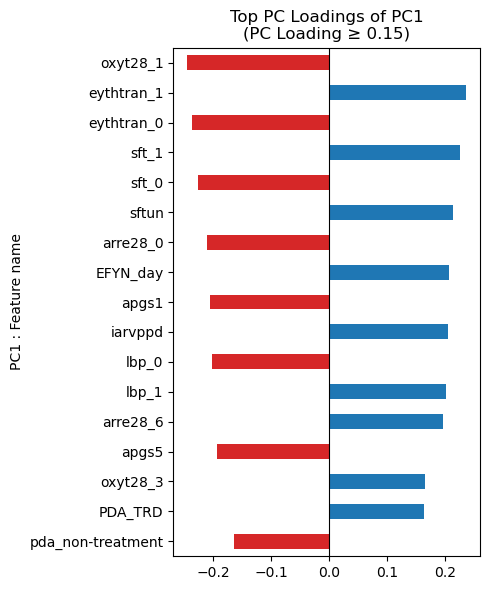

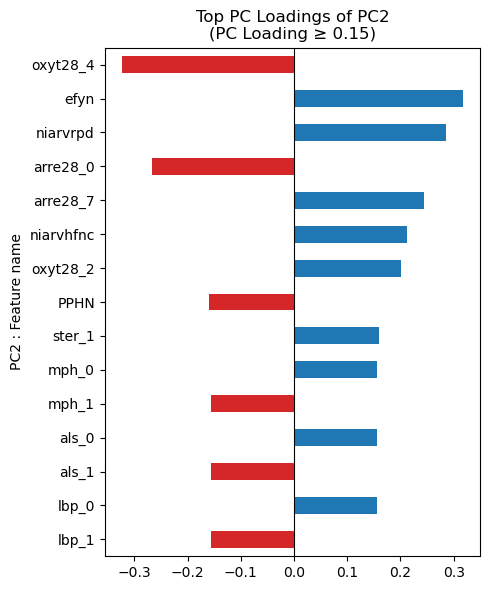

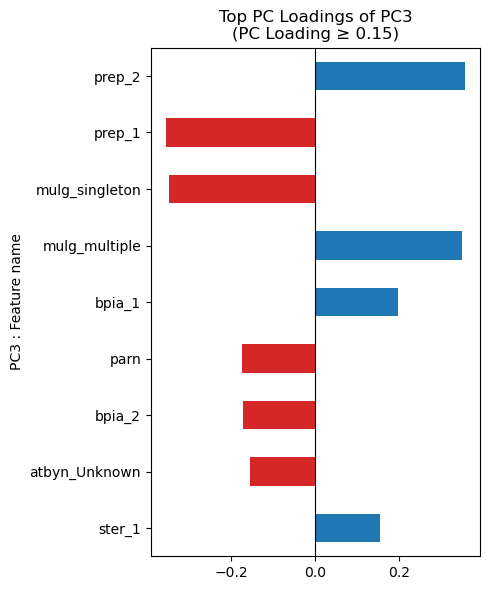

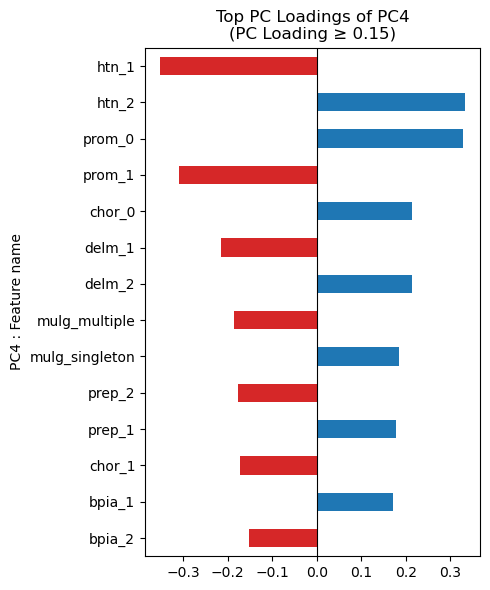

In [10]:
top_dfs = {}

for pc in components:                            # components = ['PC1', …]
    feat_col  = f'{pc} : Feature name'
    load_col  = f'{pc} : PC Loading'

    # ∑|loading| 행 제외, 결측 제외
    tmp = combined_df.loc[combined_df.index != 'PC Loading Summary'
                          , [feat_col, load_col]].dropna()

    # Series(index = feature, values = loading) → DataFrame(‘loading’ 컬럼)
    series = pd.Series(tmp[load_col].values,
                       index=tmp[feat_col],
                       name='loading')
    top_dfs[pc] = series.to_frame()

# 기존 함수 그대로 사용
def loading_barplots(loadings_dict: dict[str, pd.DataFrame],
                     threshold: float = 0.0,
                     top_n: int = 20,
                     figsize: tuple[int, int] = (5, 6)) -> None:
    """
    Draw one horizontal bar-plot per PC.
    * threshold  –  |loading| cut-off; variables below are dropped
    * top_n      –  max number of variables to plot per PC
    """
    for pc, df in loadings_dict.items():
        vec = df['loading']                       # Series with sign
        vec = vec[vec.abs() >= threshold]         # 절대값 기준 필터
        if vec.empty:
            print(f'{pc}: no loadings ≥ {threshold}')
            continue
        vec = vec.head(top_n)[::-1]               # 표시용 역순
        colours = ['tab:red' if x < 0 else 'tab:blue' for x in vec]

        plt.figure(figsize=figsize)
        vec.plot(kind='barh', color=colours)
        plt.axvline(0, color='black', lw=0.8)
        plt.title(f'Top PC Loadings of {pc}\n(PC Loading ≥ {threshold})')
        plt.tight_layout()
        plt.show()


loading_barplots(top_dfs, threshold=0.15, top_n=30)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24076\62098228.py:101: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


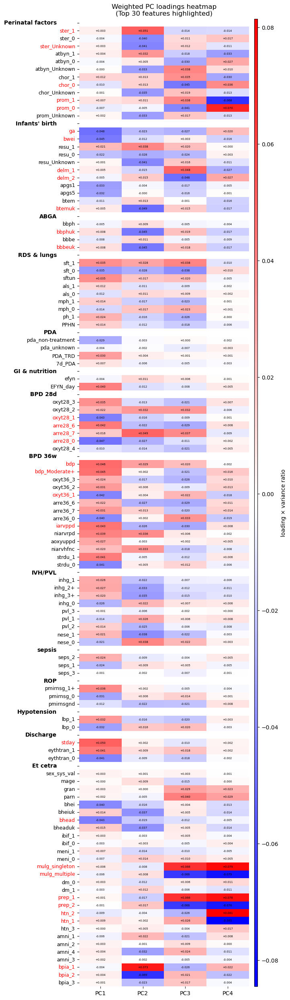

In [204]:
ipt1_dir = f'{crt_path}/Results/M13'    # 고정
df_dic = pd.read_excel(os.path.join(ipt1_dir, "list_4_sort(features).xlsx"))
df_dic = df_dic[['cat_name', 'col_name']]



# 1) eigenvalues & variance-ratio
eigenvalues = (pca_loadings ** 2).sum(axis=0)
var_ratio   = eigenvalues / eigenvalues.sum()

# 2) weighted loadings
weighted_loadings = pca_loadings.mul(var_ratio, axis=1)

# 3) df_dic 순서에 따라 feature 재배열 + 카테고리 구분용 빈줄
cat_name_positions, cat_labels = [], []
expanded_rows, previous_cat = [], None
for cat, col in zip(df_dic['cat_name'], df_dic['col_name']):
    if col not in weighted_loadings.index:
        continue                                    # PCA에 없는 변수는 건너뜀
    if cat != previous_cat:
        expanded_rows.append(('__blank__', [np.nan] * len(components)))
        cat_name_positions.append(len(expanded_rows) - 0.5)
        cat_labels.append(cat)
        previous_cat = cat
    expanded_rows.append((col, weighted_loadings.loc[col].values))

# DataFrame 구성
row_labels  = [r[0] for r in expanded_rows]
heat_values = np.vstack([r[1] for r in expanded_rows])
heat_df     = pd.DataFrame(heat_values, index=row_labels, columns=components)

# 4) Top-30 feature 파악 (blank 제외)
abs_weighted = weighted_loadings.abs().max(axis=1)
top30 = set(abs_weighted.nlargest(30).index)

# 5) heatmap + 숫자 + 카테고리 라벨
fig = plt.figure(figsize=(6, max(6, 0.25 * len(heat_df))))
gs  = fig.add_gridspec(1, 6, width_ratios=[1,1,1,1,0.08,0.08])

ax  = fig.add_subplot(gs[0, :4])

# ❶ '__blank__' 행만 선택한 마스크 생성
row_mask = (heat_df.index == '__blank__')               # (n_rows,)
mask = pd.DataFrame(
        np.tile(row_mask[:, None], (1, heat_df.shape[1])),     # (n_rows, n_cols)
        index=heat_df.index,
        columns=heat_df.columns,
        dtype=bool
)

sns.heatmap(
    heat_df,
    cmap='bwr',
    mask=mask,                   # ✅ 동일 shape
    annot=False,
    cbar=False,
    ax=ax,
    linewidths=0
)

# y-tick 레이블 (blank → 공백)
yticklabels = [' ' if lbl == '__blank__' else lbl for lbl in heat_df.index]
ax.set_yticks(np.arange(len(yticklabels)) + 0.5)
ax.set_yticklabels(yticklabels, fontsize=9)

# top-30 빨간색 처리
for label in ax.get_yticklabels():
    if label.get_text() in top30:
        label.set_color('red')

# 숫자 주석
for i in range(len(heat_df)):
    if heat_df.index[i] == '__blank__':
        continue
    for j in range(len(components)):
        val = heat_df.iat[i, j]
        ax.text(j + 0.5, i + 0.5, f'{val:+.3f}', ha='center', va='center',
                fontsize=5, color='black')

ax.set_xticklabels(components)
ax.set_title('Weighted PC loadings heatmap\n(Top 30 features highlighted)')


ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(cat_name_positions)
ax2.set_yticklabels(cat_labels, fontsize=10, fontweight='bold', va='center', ha='right')
ax2.tick_params(axis='y', length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_ylabel('')
ax2.yaxis.set_label_position("left")
ax2.yaxis.tick_left()
ax2.set_xlim(ax.get_xlim())
ax2.yaxis.set_tick_params(pad=40)

cax = fig.add_subplot(gs[0, 4])
cb  = fig.colorbar(ax.collections[0], cax=cax)
cb.set_label('loading × variance ratio', rotation=90)

plt.tight_layout()
fig.savefig(os.path.join(ipt_dir, "Weighted_PC_loadings_heatmap.pdf")
            , format='pdf', bbox_inches='tight'
           )

plt.show()


C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\ppca\_ppca.py:82: RuntimeWarning: divide by zero encountered in log
  det = np.log(np.linalg.det(Sx))


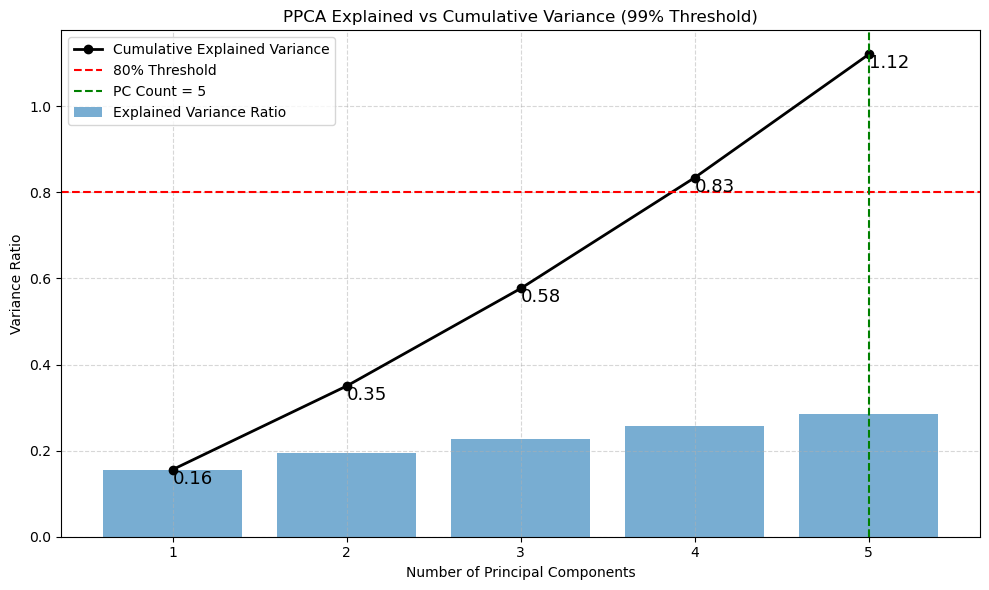

In [103]:
d_max = df_ana.shape[1]
ppca_model = PPCA()
ppca_model.fit(df_ana.values, d=d_max)

# 2) 분산 비율 및 누적 분산 계산
var_ratio = ppca_model.var_exp                  # 각 PC의 설명 분산 비율 (0~1)
cum_var   = np.cumsum(var_ratio)                # 누적 설명 분산

# 3) 99% 도달 지점 계산
n_pc99 = np.argmax(cum_var >= 0.99) + 1

# 4) 플롯용 슬라이스
pcs         = np.arange(1, n_pc99+1)
var_ratio_n = var_ratio[:n_pc99]
cum_var_n   = cum_var[:n_pc99]

# 5) 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# ─── 막대: 개별 설명 분산 비율
ax.bar(pcs, var_ratio_n, alpha=0.6, label='Explained Variance Ratio')

# ─── 선+포인트: 누적 설명 분산
ax.plot(pcs, cum_var_n, marker='o', color='black', linewidth=2,
        label='Cumulative Explained Variance')

# ─── 각 포인트 위에 누적 분산값 표시
for x, y in zip(pcs, cum_var_n):
    ax.text(x, y, f"{y:.2f}", ha='left', va='top', fontsize=13)

# ─── 기준선 표시
ax.axhline(0.8, color='red', linestyle='--', label='80% Threshold')
ax.axvline(n_pc99, color='green', linestyle='--', label=f'PC Count = {n_pc99}')

# ─── 레이블·타이틀
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Variance Ratio')
ax.set_title('PPCA Explained vs Cumulative Variance (99% Threshold)')
ax.set_xticks(pcs)
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

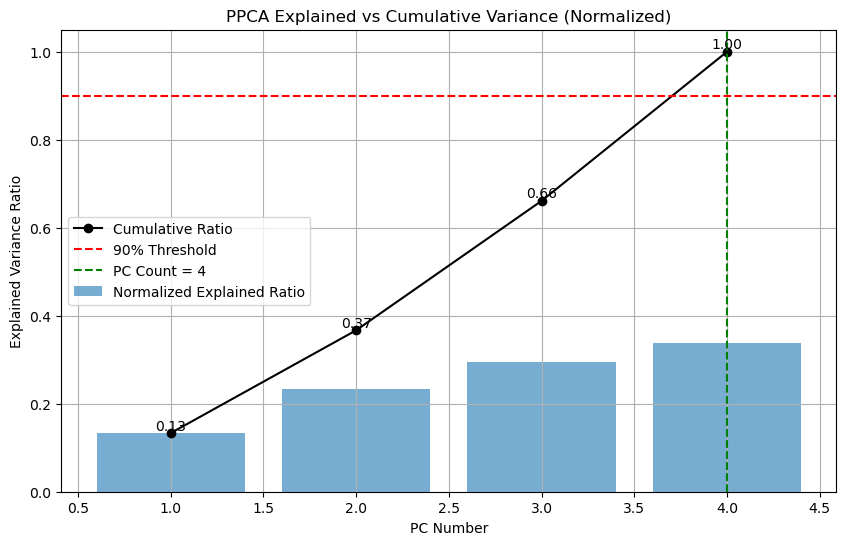

In [62]:
eigvals = ppca_model.var_exp                    # 실제 “분산량”이기 때문에 합이 1이 아닙니다
ratio  = eigvals / np.sum(eigvals)              # 이제 0~1 사이로 정규화

# 2) (선택) % 단위로 변환
ratio_pct = ratio * 100

# 3) 누적 분산도 재계산
cum_ratio = np.cumsum(ratio)

# 4) 99% Threshold 로 PC 개수 찾기
n_pc99 = np.argmax(cum_ratio >= 0.9) + 1

# 5) 시각화 (정규화된 ratio 사용)
pcs        = np.arange(1, n_pc99+1)
ratio_n    = ratio[:n_pc99]
cum_ratio_n= cum_ratio[:n_pc99]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(pcs, ratio_n, alpha=0.6, label='Normalized Explained Ratio')
ax.plot(pcs, cum_ratio_n, 'o-', color='black', label='Cumulative Ratio')
ax.axhline(0.90, color='red', linestyle='--', label='90% Threshold')
ax.axvline(n_pc99, color='green', linestyle='--', label=f'PC Count = {n_pc99}')
for x,y in zip(pcs, cum_ratio_n):
    ax.text(x, y, f"{y:.2f}", ha='center', va='bottom')
ax.set_xlabel('PC Number')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PPCA Explained vs Cumulative Variance (Normalized)')
ax.legend(); ax.grid(True)
plt.show()

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\ppca\_ppca.py:23: RuntimeWarning: invalid value encountered in divide
  return (X - self.means) / self.stds
C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\ppca\_ppca.py:82: RuntimeWarning: divide by zero encountered in log
  det = np.log(np.linalg.det(Sx))


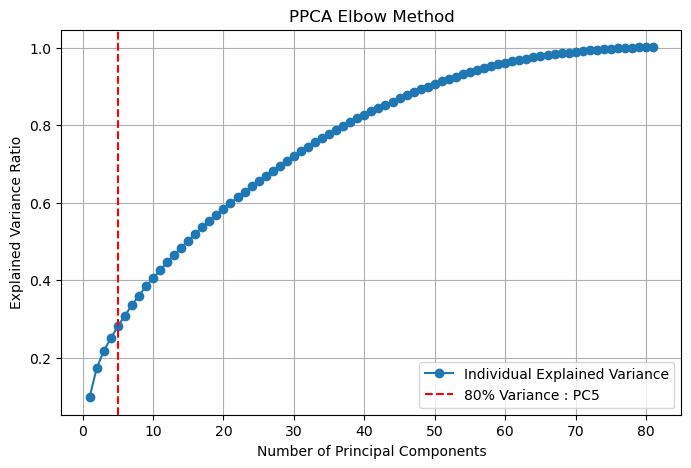

Optimal PCs for 80% cumulative variance: 5
Optimal PCs by mean-variance rule:       81


In [63]:
MAX_D = df_scd.shape[1]
ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=MAX_D)

#––– 01. 설명 가능한 분산 비율 & 누적 분산
explained_variance_ratio      = ppca_model.var_exp             # length = MAX_D
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 1) 누적 분산 80% 지점
optimal_pc_90 = np.argmax(cumulative_explained_variance >= 0.80) + 1

# 2) 평균 분산 비율 (평균 고유값 방식 대응)
mean_ratio    = 1.0 / len(explained_variance_ratio)
optimal_pc_mean = np.sum(explained_variance_ratio > mean_ratio)

# 시각화 (Elbow 스타일)
plt.figure(figsize=(8,5))
plt.plot(
    np.arange(1, len(explained_variance_ratio)+1),
    explained_variance_ratio,
    marker='o', linestyle='-',
    label='Individual Explained Variance'
)
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PPCA Elbow Method')
plt.axvline(x=optimal_pc_90, color='r', linestyle='--',
            label=f"80% Variance : PC{optimal_pc_90}")
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal PCs for 80% cumulative variance: {optimal_pc_90}")
print(f"Optimal PCs by mean-variance rule:       {optimal_pc_mean}")

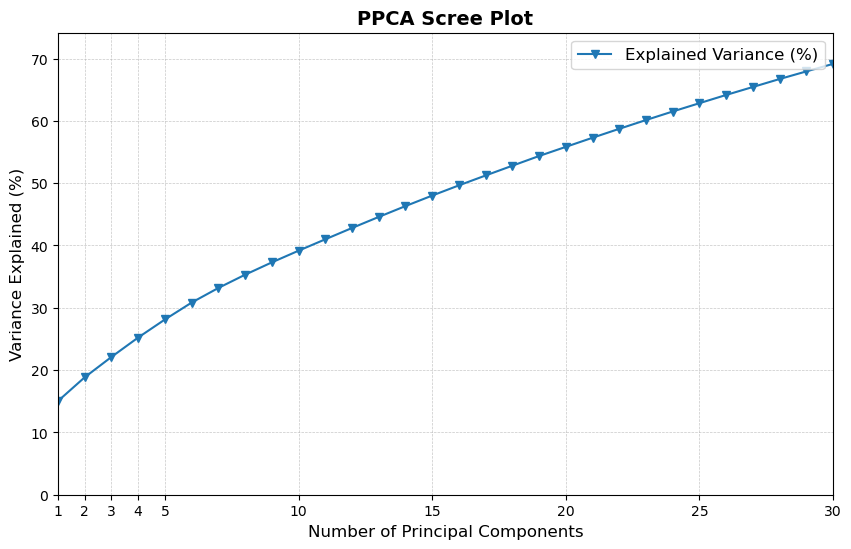

In [105]:
#––– 00. PPCA 학습 (30개 PC)
ppca30 = PPCA()
ppca30.fit(df_scd.values, d=30)

#––– 01. % 단위 분산 비율
explained_pct = ppca30.var_exp * 100   # 백분율 변환

#––– 02. Scree Plot
num_pcs = len(explained_pct)
x_vals  = np.arange(1, num_pcs+1)

plt.figure(figsize=(10,6))
plt.plot(
    x_vals, explained_pct,
    marker='v', linestyle='-', markersize=6,
    label='Explained Variance (%)'
)
plt.xlim(1, num_pcs)
plt.xticks([1,2,3,4,5,10,15,20,25,30])
plt.ylim(0, explained_pct.max()+5)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.title('PPCA Scree Plot', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(loc='upper right', fontsize=12)
plt.show()

1D  (PC1) variance: 0.1504
2D  (PC1+PC2)    : 0.3389
3D  (PC1+PC2+PC3): 0.5600
4D  (PC1+PC2+PC3+PC4): 0.8122
→ 4D plot 추천


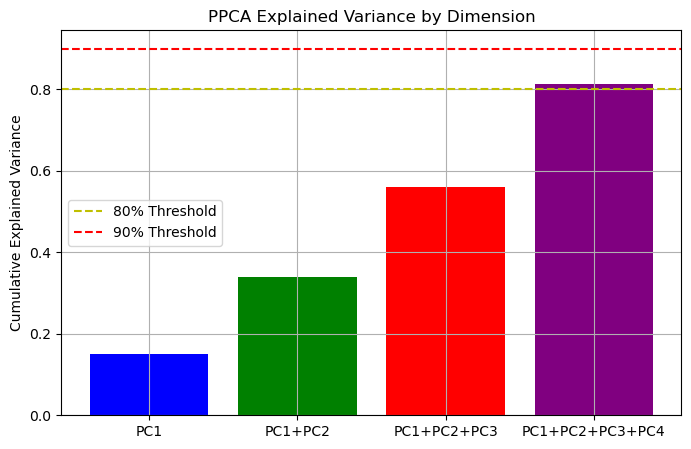

In [106]:
ppca4 = PPCA()
ppca4.fit(df_scd.values, d=4)

#––– 01. 분산 비율
evr = ppca4.var_exp            # [PC1, PC2, PC3]
evr_1 = evr[0]
evr_2 = evr[:2].sum()
evr_3 = evr[:3].sum()
evr_4 = evr[:4].sum()

print(f"1D  (PC1) variance: {evr_1:.4f}")
print(f"2D  (PC1+PC2)    : {evr_2:.4f}")
print(f"3D  (PC1+PC2+PC3): {evr_3:.4f}")
print(f"4D  (PC1+PC2+PC3+PC4): {evr_4:.4f}")

# 차원 추천
if evr_1 >= 0.80:
    print("→ 1D plot 추천")
elif evr_2 >= 0.80:
    print("→ 2D plot 추천")
elif evr_3 >= 0.80:
    print("→ 3D plot 추천")
elif evr_4 >= 0.80:
    print("→ 4D plot 추천")
else:
    print("→ 4D 이상 차원 고려")

# 시각화
plt.figure(figsize=(8,5))
plt.bar(['PC1','PC1+PC2','PC1+PC2+PC3', 'PC1+PC2+PC3+PC4'], [evr_1, evr_2, evr_3, evr_4],
        color=['blue','green','red', 'purple'])
plt.axhline(0.80, color='y', linestyle='--', label='80% Threshold')
plt.axhline(0.90, color='r', linestyle='--', label='90% Threshold')
plt.ylabel('Cumulative Explained Variance')
plt.title('PPCA Explained Variance by Dimension')
plt.legend()
plt.grid(True)
plt.show()

In [73]:
# 설명 가능한 분산 비율 확인
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 1. 누적 설명 분산 90% 기준으로 최적 PC 개수 찾기
optimal_pc_90 = np.argmax(cumulative_explained_variance >= 0.90) + 1

# 2. 엘보우 방법을 활용하여 최적의 PC 개수 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, marker='o', linestyle='-', label='Individual Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Elbow Method for PCA')
plt.axvline(x=optimal_pc_90, color='r', linestyle='--', label=f"Optimal PCs ({optimal_pc_90})")
plt.legend()
plt.grid()
plt.show()

# 3. 평균 고유값 기준으로 최적 PC 개수 찾기
mean_variance = np.mean(pca.explained_variance_)  # 평균 고유값
optimal_pc_mean = np.sum(pca.explained_variance_ > mean_variance)

# 최종 결과 출력
print(f"Optimal number of principal components for 90% variance: {optimal_pc_90}")
print(f"Optimal number of principal components (Mean Eigenvalue Method): {optimal_pc_mean}")

NameError: name 'pca' is not defined

In [61]:
pca = PCA(n_components=30)  # PC1 - PC30
pca_result = pca.fit_transform(df_scd)

# PCA 실행 후 얻어진 설명 가능한 분산 비율 (백분율 변환)
explained_variance_ratio = pca.explained_variance_ratio_ * 100  # %로 변환

# X축을 1~30까지 확장하기 위해 최대 30개의 PC 사용
num_pcs = min(30, len(explained_variance_ratio))
x_values = range(1, num_pcs + 1)
y_values = explained_variance_ratio[:num_pcs]

# Scree Plot 생성 (시각적 개선)
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values
         , marker='v', linestyle='-', color='b', markersize=6
         , label='Explained Variance (%)'
        )

# X축 범위 및 눈금 조정
plt.xlim(1, 30)
xticks_labels = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30]  # 원하는 눈금만 표기
plt.xticks(xticks_labels)  # X축 눈금 설정

# Y축 라벨 및 눈금 설정
plt.ylabel('Variance Explained (%)')  # 백분율로 변경
plt.yticks(np.arange(0, max(y_values) + 5, 1))  # Y축 눈금을 5% 간격으로 설정

# 제목 및 라벨 스타일 조정
plt.xlabel('Number of Principal Components', fontsize=12)
plt.title('Scree Plot for PCA', fontsize=14, fontweight='bold')

# 가독성을 위한 그리드 추가
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# 범례 스타일 조정
plt.legend(fontsize=12, loc='upper right')

# Show plot
plt.show()

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [62]:
# 설명 가능한 분산 비율 확인
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# 1D, 2D, 3D 설명 가능한 분산 비율 계산
evr_1D = explained_variance_ratio[0]  # PC1
evr_2D = explained_variance_ratio[:2].sum()  # PC1 + PC2
evr_3D = explained_variance_ratio[:3].sum()  # PC1 + PC2 + PC3

print(f"Explained Variance Ratio of PC1 (1D): {evr_1D:.4f}")
print(f"Explained Variance Ratio of PC1 + PC2 (2D): {evr_2D:.4f}")
print(f"Explained Variance Ratio of PC1 + PC2 + PC3 (3D): {evr_3D:.4f}")

# 적절한 차원 선택
if evr_1D >= 0.80:
    print("1D PCA Plot")
elif evr_2D >= 0.80:
    print("2D PCA Plot")
elif evr_3D >= 0.80:
    print("3D PCA Plot")
else:
    print("Over 3D+")

# 차원별 설명 가능한 분산 비율 시각화
plt.figure(figsize=(8, 5))
plt.bar(["PC1", "PC1+PC2", "PC1+PC2+PC3"], [evr_1D, evr_2D, evr_3D], color=['blue', 'green', 'red'])
plt.axhline(y=0.8, color='y', linestyle='--', label="80% Threshold")
plt.axhline(y=0.9, color='r', linestyle='--', label="90% Threshold")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Ratio for Different PCA Dimensions")
plt.legend()
plt.grid()
plt.show()

AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

In [13]:
# Apply PCA
# Feature 기여도 (Loading 확인)
pca_loadings = pd.DataFrame(ppca_model.C, index=df_scd.columns
                            , columns=['PC1', 'PC2', 'PC3', 'PC4']
                           )

# 기여도가 큰 상위 feature 선택
top_features_PC1 = pca_loadings['PC1'].abs().sort_values(ascending=False)
top_features_PC2 = pca_loadings['PC2'].abs().sort_values(ascending=False)
top_features_PC3 = pca_loadings['PC3'].abs().sort_values(ascending=False)
top_features_PC4 = pca_loadings['PC4'].abs().sort_values(ascending=False)

# 각 PC 설명 분산 출력
print(f"PC1 explains {explained_variance_ratio[0]*100:.2f}% of total variance")
print(f"PC2 explains {explained_variance_ratio[1]*100:.2f}% of total variance")
print(f"PC3 explains {explained_variance_ratio[2]*100:.2f}% of total variance")
print(f"PC4 explains {explained_variance_ratio[3]*100:.2f}% of total variance")

# 상위 features 출력
print("\nTop features contributing to PC1:")
print(top_features_PC1.head(30))

print("\nTop features contributing to PC2:")
print(top_features_PC2.head(30))

print("\nTop features contributing to PC3:")
print(top_features_PC3.head(30))

print("\nTop features contributing to PC4:")
print(top_features_PC4.head(30))

'''# 기여도가 큰 상위 feature 선택
top_features_PC1 = pca_loadings['PC1'].abs().sort_values(ascending=False)
top_features_PC2 = pca_loadings['PC2'].abs().sort_values(ascending=False)
top_features_PC3 = pca_loadings['PC3'].abs().sort_values(ascending=False)
# top_features_PC1 = pca_loadings['PC1'].abs().sort_values(ascending=False).head(30)    # Top 30 F
# top_features_PC2 = pca_loadings['PC2'].abs().sort_values(ascending=False).head(30)
# top_features_PC3 = pca_loadings['PC3'].abs().sort_values(ascending=False).head(30)

# 각 PC가 설명하는 총 분산 출력
print(f"PC1 explains {explained_variance_ratio[0]:.2f}% of total variance")
print(f"PC2 explains {explained_variance_ratio[1]:.2f}% of total variance")
print(f"PC3 explains {explained_variance_ratio[2]:.2f}% of total variance")
'''
# 기여도가 높은 feature 출력
top_features_PC1, top_features_PC2, top_features_PC3, top_features_PC4

PC1 explains 13.07% of total variance
PC2 explains 17.68% of total variance
PC3 explains 21.71% of total variance
PC4 explains 25.60% of total variance

Top features contributing to PC1:
ga                   0.246551
arre28_0             0.229783
bwei                 0.222374
bhead                0.219436
eythtran_0           0.210496
eythtran_1           0.210496
oxyt28_1             0.207900
bhei                 0.202143
iarvppd              0.195507
sft_1                0.191678
sft_0                0.191678
EFYN_day             0.191380
arre28_6             0.190546
niarvrpd             0.185128
sftun                0.183086
apgs1                0.172055
apgs5                0.165088
oxyt28_3             0.158005
lbp_0                0.157392
lbp_1                0.157392
PDA_TRD              0.155189
pda_non-treatment    0.148021
aoxyuppd             0.122000
resu_0               0.121691
seps_2               0.121404
seps_1               0.120884
oxyt28_2             0.117398
res

(ga               0.246551
 arre28_0         0.229783
 bwei             0.222374
 bhead            0.219436
 eythtran_0       0.210496
                    ...   
 bpia_3           0.004862
 atbyn_Unknown    0.002654
 chor_Unknown     0.001489
 htn_3            0.000985
 mage             0.000472
 Name: PC1, Length: 86, dtype: float64,
 bpia_1               0.358718
 bpia_2               0.336154
 btemuk               0.237578
 bbphuk               0.226342
 ster_1               0.226076
                        ...   
 pda_unknown          0.001955
 apgs1                0.001767
 htn_2                0.001637
 PDA_TRD              0.001469
 pda_non-treatment    0.001190
 Name: PC2, Length: 86, dtype: float64,
 mulg_multiple     0.415931
 mulg_singleton    0.415931
 prep_2            0.403147
 prep_1            0.403147
 htn_1             0.195831
                     ...   
 amni_1            0.004129
 arre28_0          0.003643
 oxyt28_1          0.003299
 pda_unknown       0.002839
 g

In [253]:
df_top_features = pd.DataFrame({
    "PC1_Top_Features": top_features_PC1.index,
    "PC Loading_PC1": top_features_PC1.values,
    "PC2_Top_Features": top_features_PC2.index,
    "PC Loading_PC2": top_features_PC2.values,
    "PC3_Top_Features": top_features_PC3.index,
    "PC Loading_PC3": top_features_PC3.values,
    "PC4_Top_Features": top_features_PC4.index,
    "PC Loading_PC4": top_features_PC4.values
})

df_top_features.to_excel(os.path.join(ipt_dir, "PC-Loadings.xlsx"), encoding='utf-8-sig')

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


In [11]:
# ipt_dir = f'{crt_path}/Results/M06_Modified-dth/4C'
# ipt_dir = f'{crt_path}/Results/M06_Modified-dth/3C_Opt-Silhouette'
# ipt_dir = f'{crt_path}/Results/M15_dataset08/2_SurvOnly/2_NEC only/C4'
df_fn = pd.read_excel(os.path.join(ipt_dir, "C4_ana+description.xlsx"))


# # 'col_name'과 '항목명'을 매핑하기 위한 Dictionary 생성 --> Description, Column
# feature_name_map = {col: {'Description': df_fn['col_name']
#                           , 'Column': df_fn['항목명']
#                          }
#                    }

# # top_features_PC1, PC2, PC3 feature 이름 변경적용
# def format_features(df, pc_name):
#     formatted_df = pd.DataFrame({
#         'Description': df.index.map(lambda x: feature_name_map[x]['Description'] if x in feature_name_map else x),
#         'Column': df.index,
#         'PC Score': df.values
#     })
#     return formatted_df

# top_features_PC1M = format_features(top_features_PC1, 'PC1')
# top_features_PC2M = format_features(top_features_PC2, 'PC2')
# top_features_PC3M = format_features(top_features_PC3, 'PC3')

# # 결과 확인
# top_features_PC1M, top_features_PC2M, top_features_PC3M


# 'col_name'과 '항목명'을 매핑하기 위한 Dictionary 생성 --> 항목명(기존이름)
feature_name_map = {col: f"{desc}({col})" for col, desc in zip(df_fn['col_name'], df_fn['항목명'])}

# top_features_PC1, PC2, PC3 feature 이름 변경적용
top_features_PC1M = top_features_PC1
top_features_PC2M = top_features_PC2
top_features_PC3M = top_features_PC3
top_features_PC4M = top_features_PC4

top_features_PC1M.rename(index=feature_name_map, inplace=True)
top_features_PC2M.rename(index=feature_name_map, inplace=True)
top_features_PC3M.rename(index=feature_name_map, inplace=True)
top_features_PC4M.rename(index=feature_name_map, inplace=True)

# 결과 확인
top_features_PC1M, top_features_PC2M, top_features_PC3M, top_features_PC4M

(재태일수 (Genital Age)(ga)                   0.246551
 생후 28일 시점 인공호흡기 (Neg)(arre28_0)          0.229783
 출생 체중(bwei)                              0.222374
 출생 두위(bhead)                             0.219436
 적혈구 수혈 여부_없음(eythtran_0)                 0.210496
                                            ...   
 출생 장소(Birth place) (병원 이외 장소)(bpia_3)    0.004862
 산전 항생제 사용 여부 (Unknown)(atbyn_Unknown)    0.002654
 조직학적 융모양막염 (Unknown)(chor_Unknown)       0.001489
 고혈압(HTN) (Chronic)(htn_3)                0.000985
 산모 나이(Maternal age)(mage)                0.000472
 Name: PC1, Length: 86, dtype: float64,
 출생 장소(Birth place) (원내)(bpia_1)    0.358718
 출생 장소(Birth place) (원외)(bpia_2)    0.336154
 첫 입원 시 체온 모름(btemuk)               0.237578
 출생 1시간 이내 혈액 가스 pH 모름(bbphuk)      0.226342
 산전스테로이드 유무 (Pos)(ster_1)           0.226076
                                      ...   
 PDA - Unknown(pda_unknown)         0.001955
 1분 아프가 점수(apgs1)                   0.001767
 고혈압(HTN) (PIH)(htn_2)              0.0

In [12]:
df_top_features = pd.DataFrame({
    "PC1_Top_Features": top_features_PC1M.index,
    "PC Loading_PC1": top_features_PC1M.values,
    "PC2_Top_Features": top_features_PC2M.index,
    "PC Loading_PC2": top_features_PC2M.values,
    "PC3_Top_Features": top_features_PC3M.index,
    "PC Loading_PC3": top_features_PC3M.values,
    "PC4_Top_Features": top_features_PC4M.index,
    "PC Loading_PC4": top_features_PC4M.values
})

df_top_features.to_excel(os.path.join(ipt_dir, "PC-Loadings.xlsx"), encoding='utf-8-sig')

C:\Users\AIWM_W01\.conda\envs\Dev_AIWM\lib\site-packages\pandas\util\_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)


In [25]:
n_top = 30

# 각 PC별로 상위 n_top개의 feature & loading 값만 슬라이스
tf1 = top_features_PC1.head(n_top)
tf2 = top_features_PC2.head(n_top)
tf3 = top_features_PC3.head(n_top)
tf4 = top_features_PC4.head(n_top)

# Fixing the title issue in the Feature Importance plots
fig, axes = plt.subplots(4, 1, figsize=(12, 20))

# PC1 Feature Importance
sns.barplot(x=tf1.values, y=tf1.index,
            ax=axes[0],
            palette="Blues_r")
axes[0].set_title(f"Important features in PC1 (Top {n_top} Loadings)")
axes[0].set_xlabel("Absolute PC Loading")
axes[0].set_ylabel("Feature")

# PC2 Feature Importance
sns.barplot(x=tf2.values, y=tf2.index,
            ax=axes[1],
            palette="Reds_r")
axes[1].set_title(f"Important features in PC2 (Top {n_top} Loadings)")
axes[1].set_xlabel("Absolute PC Loading")
axes[1].set_ylabel("Feature")

# PC3 Feature Importance
sns.barplot(x=tf3.values, y=tf3.index,
            ax=axes[2],
            palette="Greens_r")
axes[2].set_title(f"Important features in PC3 (Top {n_top} Loadings)")
axes[2].set_xlabel("Absolute PC Loading")
axes[2].set_ylabel("Feature")

# PC4 Feature Importance
sns.barplot(x=tf4.values, y=tf4.index,
            ax=axes[3],
            palette="Purples_r")
axes[3].set_title(f"Important features in PC4 (Top {n_top} Loadings)")
axes[3].set_xlabel("Absolute PC Loading")
axes[3].set_ylabel("Feature")

plt.tight_layout()
plt.show()


'''# Fixing the title issue in the Feature Importance plots
fig, axes = plt.subplots(4, 1, figsize=(12, 20))

# PC1 Feature Importance
sns.barplot(x=top_features_PC1.values, y=top_features_PC1.index
            , ax=axes[0]
            , palette="Blues_r"
           )
axes[0].set_title("Important features in PC1 (PC Loadings)")
axes[0].set_xlabel("PC Loadings")
axes[0].set_ylabel("Feature")

# PC2 Feature Importance
sns.barplot(x=top_features_PC2.values, y=top_features_PC2.index
            , ax=axes[1]
            , palette="Reds_r"
           )
axes[1].set_title("Important features in PC2 (PC Loadings)")
axes[1].set_xlabel("PC Loadings")
axes[1].set_ylabel("Feature")

# PC3 Feature Importance
sns.barplot(x=top_features_PC3.values, y=top_features_PC3.index
            , ax=axes[2]
            , palette="Greens_r"
           )
axes[2].set_title("Important features in PC3 (PC Loadings)")
axes[2].set_xlabel("PC Loadings")
axes[2].set_ylabel("Feature")

# PC3 Feature Importance
sns.barplot(x=top_features_PC4.values, y=top_features_PC4.index
            , ax=axes[3]
            , palette="Greens_r"
           )
axes[3].set_title("Important features in PC4 (Top 30 PC Loadings)")
axes[3].set_xlabel("PC Loadings")
axes[3].set_ylabel("Feature")


plt.tight_layout()
plt.show()'''

NameError: name 'top_features_PC1' is not defined

In [27]:
# PCA (2D)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scd)

# PCA 결과를 DataFrame으로 변환
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca['Cluster_Labels'] = cluster_labels.values


# 클러스터별 색상 정의/적용
cluster_palette = {1: "blue"
                   , 2: "green"
                   , 3: "orange"
                   , 4: "red"
#                    , 5: "purple"
#                    , 6: "grey"
                  }
colors = df_pca["Cluster_Labels"].map(cluster_palette)

# PC1/PC2 (2D Scatter plot)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"],
                hue=df_pca["Cluster_Labels"],
                palette=cluster_palette,
                alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA by clusters")

# 범례 수정: Cluster {label} 형태로 설정
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [f"Cluster {lbl}" for lbl in labels]
plt.legend(handles=handles, labels=new_labels, title="Cluster Labels")

plt.grid(True)
plt.show()

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

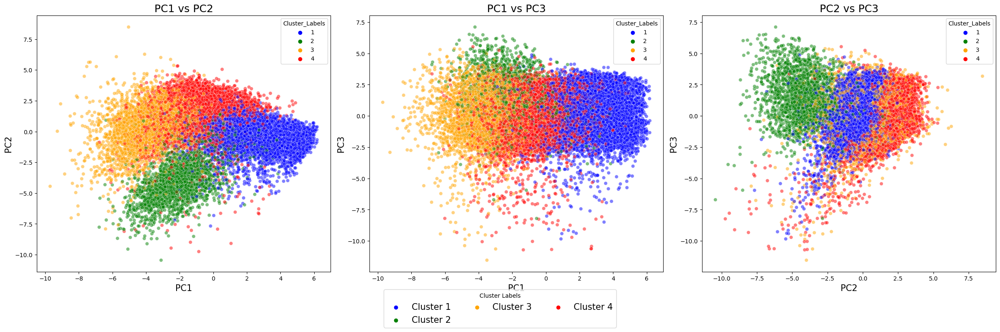

In [70]:
ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=3)
pca_result = ppca_model.transform()

# PCA 결과를 DataFrame으로 변환
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'], index=df_scd.index)
df_pca['Cluster_Labels'] = cluster_labels.values

cluster_palette = {1: "blue"
                   , 2: "green"
                   , 3: "orange"
                   , 4: "red"
#                    , 5: "purple"
#                    , 6: "grey"
                  }


fontsize = 15
titlesize = 18

# 2D PCA Scatter Plot 생성
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# PC1 - PC2
sns.scatterplot(x="PC1", y="PC2", hue="Cluster_Labels",
                palette=cluster_palette, alpha=0.5, ax=axes[0], data=df_pca)
axes[0].set_xlabel("PC1", fontsize=fontsize)
axes[0].set_ylabel("PC2", fontsize=fontsize)
axes[0].set_title("PC1 vs PC2", fontsize=titlesize)

# PC1 - PC3
sns.scatterplot(x="PC1", y="PC3", hue="Cluster_Labels",
                palette=cluster_palette, alpha=0.5, ax=axes[1], data=df_pca)
axes[1].set_xlabel("PC1", fontsize=fontsize)
axes[1].set_ylabel("PC3", fontsize=fontsize)
axes[1].set_title("PC1 vs PC3", fontsize=titlesize)

# PC2 - PC3
sns.scatterplot(x="PC2", y="PC3", hue="Cluster_Labels",
                palette=cluster_palette, alpha=0.5, ax=axes[2], data=df_pca)
axes[2].set_xlabel("PC2", fontsize=fontsize)
axes[2].set_ylabel("PC3", fontsize=fontsize)
axes[2].set_title("PC2 vs PC3", fontsize=titlesize)

# 범례 수정: "Cluster {label}" 형태
handles, labels = axes[0].get_legend_handles_labels()
new_labels = [f"Cluster {lbl}" for lbl in labels]
fig.legend(handles=handles, labels=new_labels, title="Cluster Labels", loc='lower center', ncol=3, fontsize=fontsize)


# 6) 레이아웃 조정 및 출력
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

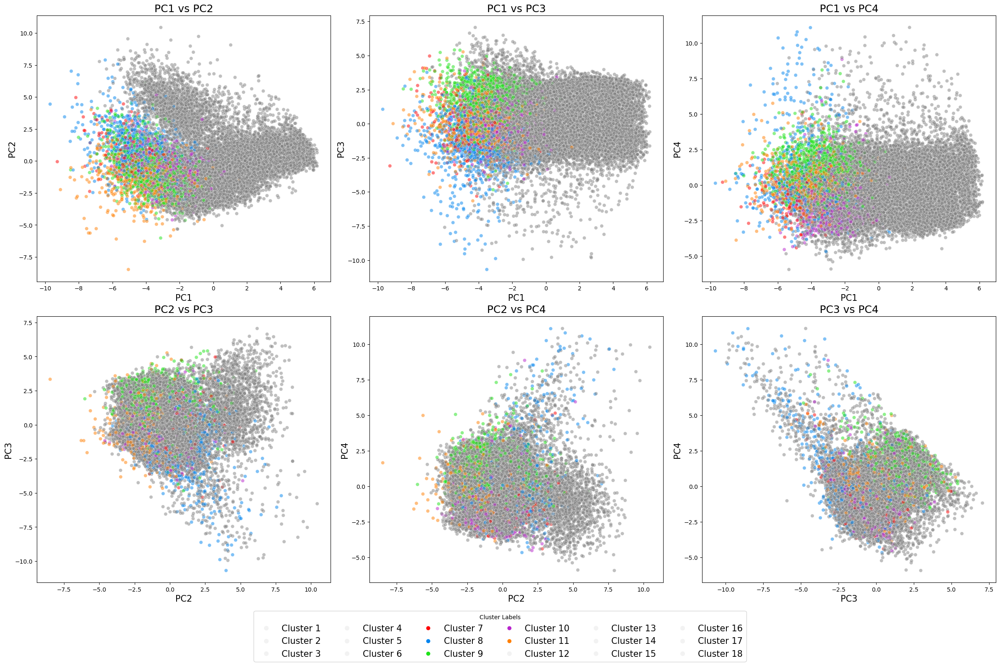

In [67]:
## 6 Subplots, 18-Clusters
import colorsys
pdf_path = os.path.join(ipt_dir, 'PCA_scatter_grid.pdf')

ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=4)
pca_result = ppca_model.transform()

# 2) PCA 결과 DataFrame 생성
df_pca = pd.DataFrame(
    data=pca_result,
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=df_scd.index
)
df_pca['Cluster_Labels'] = cluster_labels.values

# 3) 클러스터 색상 팔레트
cluster_palette = {
     1: "grey",  2: "grey",  3: "grey",  4: "grey",
     5: "grey",  6: "grey",  7: "blue",  8: "green",
     9: "orange",10: "red", 11: "purple",12: "grey",
    13: "grey", 14: "grey", 15: "grey", 16: "grey",
    17: "grey", 18: "grey"
}
for k in highlight:
    # 현재 hex/RGB → RGB(0–1) 튜플로 변환
    rgb = mpl.colors.to_rgb(cluster_palette[k])
    # alpha=0.9 로 설정 (값이 클수록 덜 투명)
    cluster_palette[k] = (*rgb, 0.9)

highlight = [7, 8, 9, 10, 11]
cluster_palette = {i: "grey" for i in range(1,19)}
# 2) Set1에서 선명한 새 색 뽑기
base_colors = sns.color_palette("Set1", n_colors=len(highlight)).as_hex()
for k, c in zip(highlight, base_colors):
    cluster_palette[k] = c

# 3) 채도 조정 함수
def bump_saturation(hex_color: str, factor: float = 1.5) -> str:
    # hex → RGB(0–1)
    rgb = mpl.colors.to_rgb(hex_color)
    # RGB → HLS
    h, l, s = colorsys.rgb_to_hls(*rgb)
    # 채도 증강, 최대 1.0으로 클램프
    s = min(1.0, s * factor)
    # HLS → RGB → hex
    rgb2 = colorsys.hls_to_rgb(h, l, s)
    return mpl.colors.to_hex(rgb2)

# 4) 강조 색상만 채도 올리기
for k in highlight:
    cluster_palette[k] = bump_saturation(cluster_palette[k], factor=2)

grey_keys = [k for k, v in cluster_palette.items() if v == "grey"]
transparent_grey = (*mpl.colors.to_rgb("grey"), 0.1)
for k in grey_keys:
    cluster_palette[k] = transparent_grey

    
    

fontsize  = 15
titlesize = 18

# 4) 2×3 그리드 생성
with PdfPages(pdf_path) as pdf:
    # 2×3 그리드 생성
    fig, axes = plt.subplots(2, 3, figsize=(24, 16), squeeze=False)
    combinations = [
        ('PC1', 'PC2'), ('PC1', 'PC3'), ('PC1', 'PC4'),
        ('PC2', 'PC3'), ('PC2', 'PC4'), ('PC3', 'PC4')
    ]

    # 5) 각 서브플롯에 scatter 그리기 (축별 범례 모두 제거)
    for ax, (x_comp, y_comp) in zip(axes.flat, combinations):
        sns.scatterplot(
            x=x_comp, y=y_comp,
            hue="Cluster_Labels",
            palette=cluster_palette,
            alpha=0.5,
            legend=False,
            ax=ax,
            data=df_pca
        )
        ax.set_title(f"{x_comp} vs {y_comp}", fontsize=titlesize)
        ax.set_xlabel(x_comp, fontsize=fontsize)
        ax.set_ylabel(y_comp, fontsize=fontsize)

    # 6) 전체 범례용 핸들·레이블 생성
    unique_clusters = sorted(df_pca['Cluster_Labels'].unique())
    legend_handles = [
        Line2D([0], [0],
               marker='o',
               color='w',
               markerfacecolor=cluster_palette[c],
               markersize=8)
        for c in unique_clusters
    ]
    legend_labels = [f"Cluster {c}" for c in unique_clusters]

    # 7) Figure-level 범례 추가 (플롯 아래 중앙)
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        title="Cluster Labels",
        loc='lower center',
        ncol=6,
        fontsize=fontsize
    )

    # 8) 레이아웃 조정 및 출력
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.125)
    pdf.savefig(fig)
    plt.show()

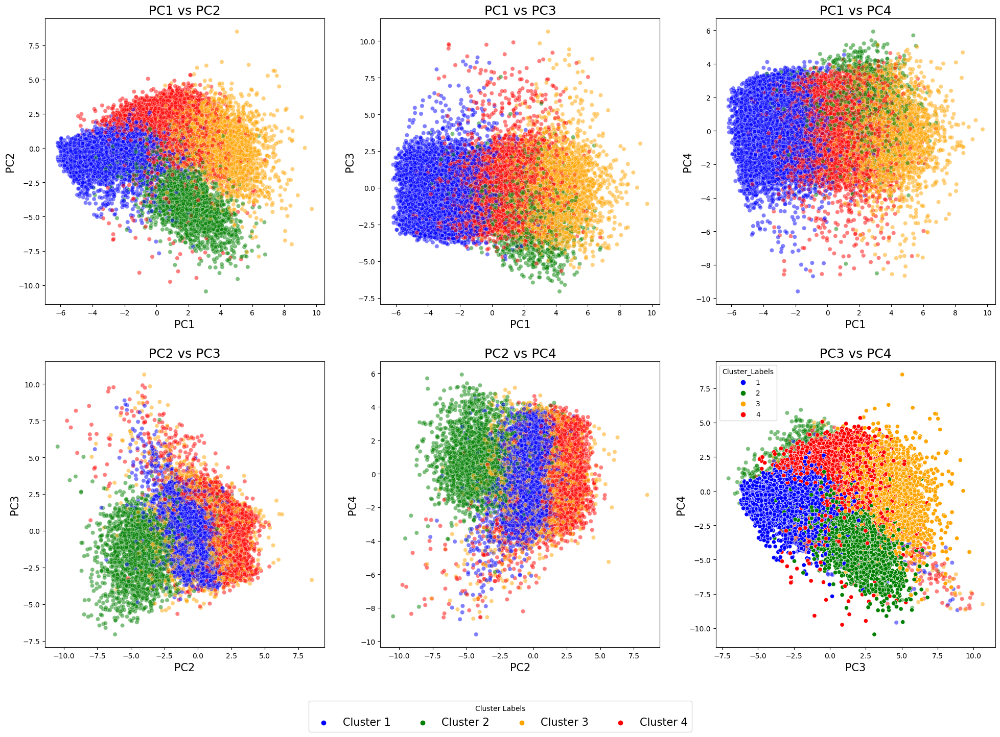

In [71]:
ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=4)
pca_result = ppca_model.transform()

df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3', 'PC4'], index=df_scd.index)
df_pca['Cluster_Labels'] = cluster_labels.values

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

combinations = [
    ('PC1', 'PC2'), ('PC1', 'PC3'), ('PC1', 'PC4'),
    ('PC2', 'PC3'), ('PC2', 'PC4'), ('PC3', 'PC4')
]

for ax, (x_comp, y_comp) in zip(axes.flat, combinations):
    sns.scatterplot(x=x_comp, y=y_comp, hue="Cluster_Labels",
                    legend=False,
                    palette=cluster_palette, alpha=0.5, ax=ax, data=df_pca)
    ax.set_title(f"{x_comp} vs {y_comp}", fontsize=titlesize)
    ax.set_xlabel(x_comp, fontsize=fontsize)
    ax.set_ylabel(y_comp, fontsize=fontsize)

    leg = ax.get_legend()
    if leg:
        leg.remove()
    ax.legend([], [], frameon=False)

# 범례 설정
handles, labels = sns.scatterplot(x='PC1', y='PC2', hue='Cluster_Labels'
                                  , palette=cluster_palette, data=df_pca, legend='brief'
                                 ).get_legend_handles_labels()
fig.legend(handles=handles, labels=[f"Cluster {lbl}" for lbl in labels]
           , title="Cluster Labels", loc='lower center', ncol=4, fontsize=fontsize)

# plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()



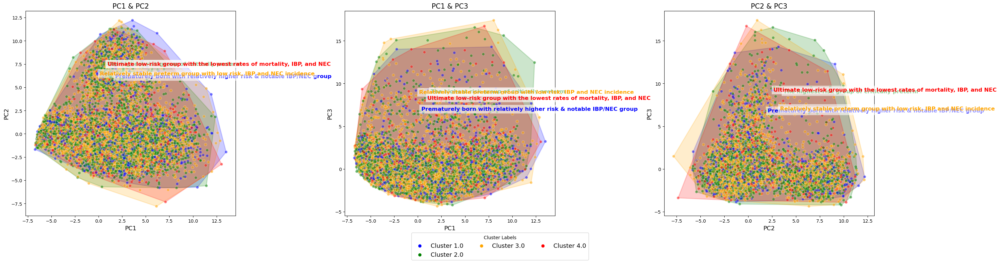

In [98]:
cluster_palette = {1: "blue"
                   , 2: "green"
                   , 3: "orange"
                   , 4: "red"
#                    , 5: "purple"
#                    , 6: "grey"
                  }
colors = df_pca["Cluster_Labels"].map(cluster_palette)

# 클러스터별 라벨 (각 클러스터의 주제)
cluster_labels_text = {
    1: "Prematurely born with relatively higher risk & notable IBP/NEC group"
    , 2: "The highest‐risk group of critically preterm"
    , 3: "Relatively stable preterm group with low risk, IBP and NEC incidence"
    , 4: "Ultimate low‐risk group with the lowest rates of mortality, IBP, and NEC"
#     , 5: "Group with moderate risk but comparatively higher IBP/NEC occurrences"
#     , 5: "Large representative cohort of moderately preterm with overall low risk"
}

fontsize = 13
titlesize = 15

# 3개의 2D PCA Scatter Plot 생성 (PC1-PC2, PC1-PC3, PC2-PC3)
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

# PCA 조합 정의
pca_combinations = [
    ("PC1", "PC2", "PC1 & PC2"),
    ("PC1", "PC3", "PC1 & PC3"),
    ("PC2", "PC3", "PC2 & PC3")
]

# 각 서브플롯에 대해 Convex Hull과 산점도를 그림
for i, (pc_x, pc_y, title) in enumerate(pca_combinations):
    ax = axes[i]

    # 클러스터별 Convex Hull을 생성하여 경계를 그림
    for cluster, color in cluster_palette.items():
        cluster_points = df_pca[df_pca["Cluster_Labels"] == cluster][[pc_x, pc_y]].values

        if len(cluster_points) >= 3:  # Convex Hull은 최소 3개의 점이 필요
            hull = ConvexHull(cluster_points)
            hull_points = cluster_points[hull.vertices]

            # 클러스터 영역을 반투명한 색으로 채우기
            ax.fill(hull_points[:, 0], hull_points[:, 1]
                    , color=color, alpha=0.2, edgecolor=color
                    , linewidth=2
                   )

            # 클러스터 중심 좌표 계산
            cluster_center = np.mean(hull_points, axis=0)

            # 클러스터 라벨을 바깥쪽에 배치
            label_offset = 5  # 바깥쪽으로 밀기 위한 오프셋 값
            ax.text(cluster_center[0], cluster_center[1] + label_offset
                    , cluster_labels_text[cluster]
                    , fontsize=12, fontweight='bold', ha='left', color=color
                    , bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
                   )

    # 클러스터 산점도 그리기
    sns.scatterplot(x=df_pca[pc_x], y=df_pca[pc_y],
                    hue=df_pca["Cluster_Labels"],
                    palette=cluster_palette,
                    alpha=0.5, ax=ax)

    # 축 설정
    ax.set_xlabel(pc_x, fontsize=fontsize)
    ax.set_ylabel(pc_y, fontsize=fontsize)
    ax.set_title(title, fontsize=titlesize)
    
    # 개별 범례 제거 (공통 범례 사용)
    ax.legend_.remove()

# 범례를 가장 아래쪽에 배치
handles, labels = axes[0].get_legend_handles_labels()
new_labels = [f"Cluster {lbl}" for lbl in labels]
fig.legend(handles=handles, labels=new_labels
           , title="Cluster Labels", loc='lower center', ncol=3, fontsize=fontsize)

# 레이아웃 조정
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

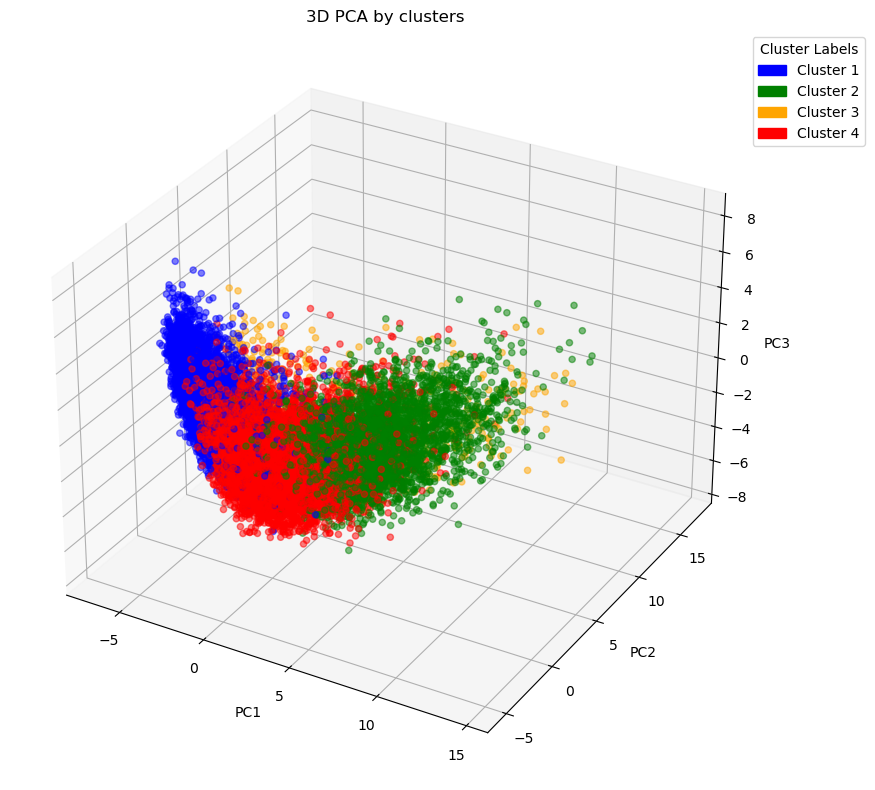

In [75]:
# 3D Scatter Plot (PC1 vs PC2 vs PC3)
pca = PCA(n_components=3)
pca_result = pca.fit_transform(df_scd)

# PCA 결과를 DataFrame으로 변환
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster_Labels'] = cluster_labels.values

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 각 클러스터별로 색상 적용
ax.scatter(df_pca["PC1"], df_pca["PC2"], df_pca["PC3"],
           c=colors,
           alpha=0.5)
# Label 잘림 방지 -> 'labelpad'
ax.set_xlabel("PC1", labelpad=5)
ax.set_ylabel("PC2", labelpad=5)
ax.set_zlabel("PC3", labelpad=5)
ax.set_title("3D PCA by clusters")

# 범례 추가
legend_patches = [mpatches.Patch(color=color, label=f"Cluster {label}"
                                ) for label, color in cluster_palette.items()
                 ]
plt.legend(handles=legend_patches
           , title="Cluster Labels", loc='upper right'
           , bbox_to_anchor=(1.15, 1)
          )

# 레이아웃 조정 (z축 라벨이 잘리지 않도록)
plt.tight_layout()

plt.show()

ValueError: 'c' argument has 20352 elements, which is inconsistent with 'x' and 'y' with size 17761.

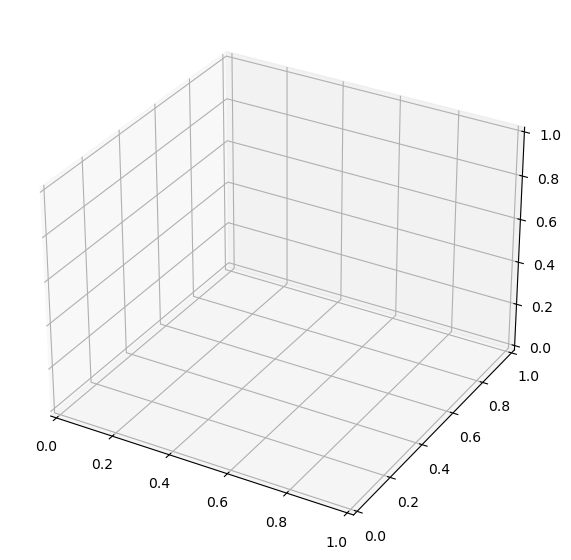

In [141]:
# 3D PCA Scatter Plot을 다양한 시점에서 시각화
fig = plt.figure(figsize=(32, 8))

# 시점 리스트 (각도 설정: (elevation, azimuth))
view_angles = [(20, 30), (20, 120), (20, 210), (20, 300)]

for i, (elev, azim) in enumerate(view_angles, 1):
    ax = fig.add_subplot(1, 4, i, projection='3d')
    
    # 각 클러스터별로 색상 적용
    ax.scatter(df_pca["PC1"], df_pca["PC2"], df_pca["PC3"],
               c=colors, alpha=0.5)
    
    # Label 잘림 방지 -> 'labelpad'
    ax.set_xlabel("PC1", labelpad=3)
    ax.set_ylabel("PC2", labelpad=3)
    ax.set_zlabel("PC3", labelpad=3)
    ax.set_title(f"3D PCA - View {i}", fontsize= 20)

    # 시점 변경
    ax.view_init(elev=elev, azim=azim)

handles, labels = axes[0].get_legend_handles_labels()
new_labels = [f"Cluster {lbl}" for lbl in labels]
fig.legend(handles=handles, labels=new_labels
           , title="Cluster Labels", loc='lower center'
#            , bbox_to_anchor=(0.5, 0)
           , ncol=3, fontsize=fontsize
          )

# 레이아웃 조정
# plt.subplots_adjust(left=0.06
#                     , right=0.94
#                     , bottom=0.15
#                     , top=0.9
#                     , wspace=0.5
#                    )
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

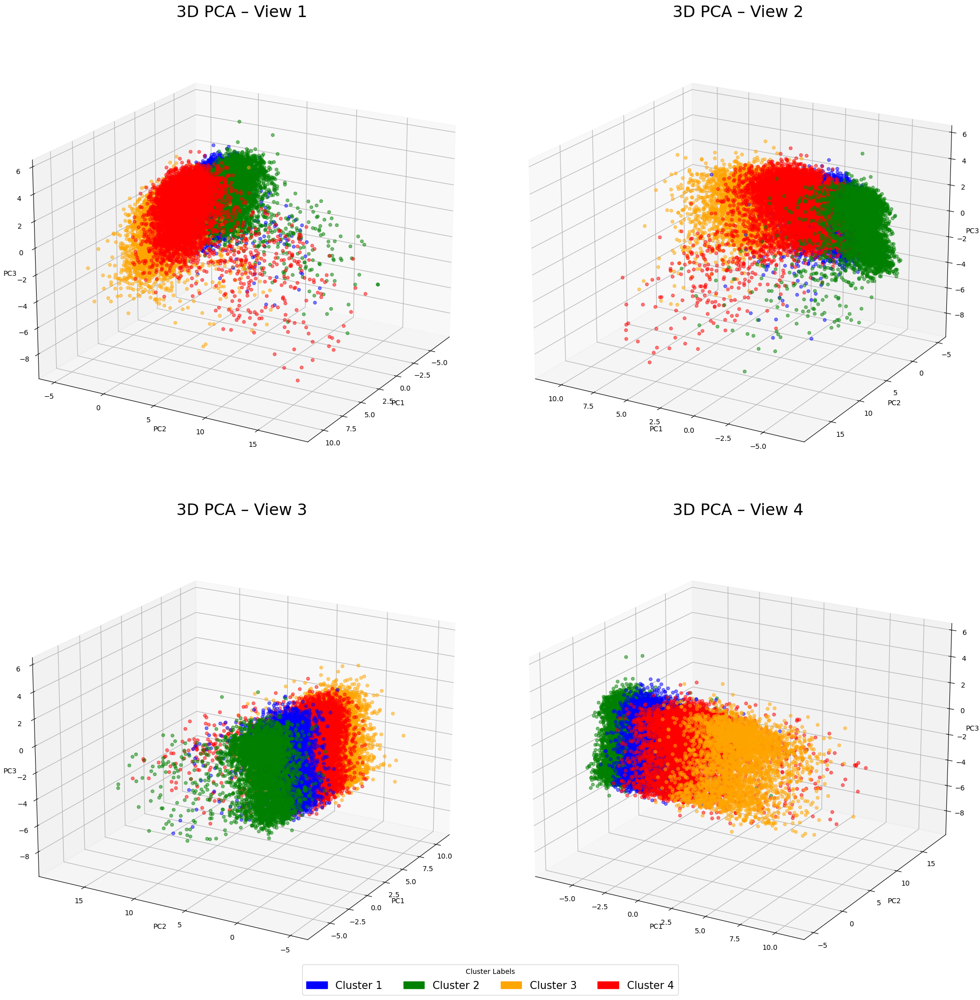

In [18]:
ppca_model = PPCA()
ppca_model.fit(df_scd.values, d=4)
pca_result = ppca_model.transform()  # shape = (n_samples, 4)

# 2) DataFrame에 담기
df_pca = pd.DataFrame(
    data=pca_result,
    columns=['PC1','PC2','PC3','PC4'],
    index=df_scd.index
)
df_pca['Cluster_Labels'] = cluster_labels.values

# 3) 3D scatter 설정
cluster_palette = {1:'blue', 2:'green', 3:'orange', 4:'red'}
view_angles     = [(20,30), (20,120), (20,210), (20,300)]
fontsize, titlesize = 15, 23

fig = plt.figure(figsize=(20, 20))

for i, (elev, azim) in enumerate(view_angles, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    
    # 클러스터별로 나눠서 그리기 (axes legend 생성은 억제)
    for cl, col in cluster_palette.items():
        sel = df_pca['Cluster_Labels'] == cl
        ax.scatter(
            df_pca.loc[sel, 'PC1'],
            df_pca.loc[sel, 'PC2'],
            df_pca.loc[sel, 'PC3'],
            c=col,
            alpha=0.5,
            s=20,
            # label은 넣지만, 아래에서 바로 제거할 예정
            label=f'Cluster {cl}'
        )
    # 내부 legend 제거
    ax.legend_.remove() if ax.legend_ else None

    ax.set_title(f'3D PCA – View {i}', fontsize=titlesize)
    ax.set_xlabel('PC1', labelpad=0)
    ax.set_ylabel('PC2', labelpad=0)
    ax.set_zlabel('PC3', labelpad=0)
    ax.view_init(elev=elev, azim=azim)

# 4) 통합 범례용 핸들 직접 생성
handles = [
    mpatches.Patch(color=col, label=f'Cluster {cl}')
    for cl, col in cluster_palette.items()
]

fig.legend(
    handles=handles,
    title='Cluster Labels',
    loc='lower center',
    ncol=4,
    fontsize=fontsize
)

# plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.tight_layout()
plt.show()

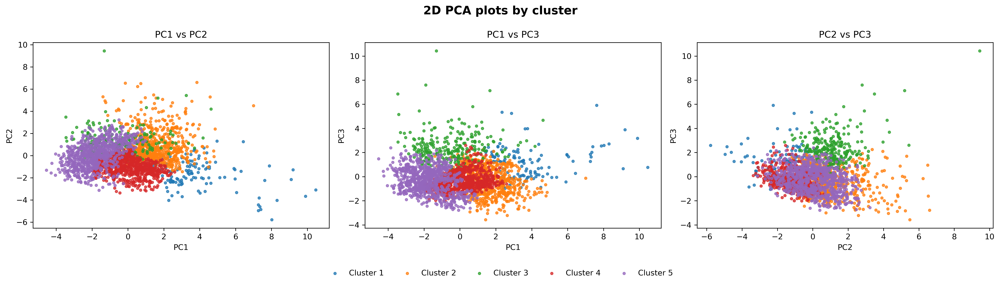

Saved: C:\Dev_AIWM\jupyter\KNN\ROP\Results\M03\PCA\~GA28\PCA30\C5\PCA_2D_clusters_subplots_1x3_300dpi.tiff


In [24]:
PATH = r"C:\Dev_AIWM\jupyter\KNN\ROP\Results\M03\PCA\~GA28\PCA30\C5\df_scd_5clustered.csv"
OUT_DIR = os.path.dirname(PATH)
OUT_TIFF = os.path.join(OUT_DIR, "PCA_2D_clusters_subplots_1x3_300dpi.tiff")

df = pd.read_csv(PATH)

need = {"PC1", "PC2", "PC3", "Cluster_Labels"}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}. Found: {list(df.columns)}")

df["Cluster_Labels"] = pd.to_numeric(df["Cluster_Labels"], errors="coerce")
df = df.dropna(subset=["Cluster_Labels"]).copy()
df["Cluster_Labels"] = df["Cluster_Labels"].astype(int)

clusters = sorted(df["Cluster_Labels"].unique())

def scatter_by_cluster(ax, x, y, title):
    for lab in clusters:
        sub = df[df["Cluster_Labels"] == lab]
        ax.scatter(sub[x], sub[y], s=10, alpha=0.75, label=f"Cluster {lab}")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)
    ax.grid(False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)
fig.suptitle("2D PCA plots by cluster", y=0.99, weight='bold', fontsize=15)

scatter_by_cluster(axes[0], "PC1", "PC2", "PC1 vs PC2")
scatter_by_cluster(axes[1], "PC1", "PC3", "PC1 vs PC3")
scatter_by_cluster(axes[2], "PC2", "PC3", "PC2 vs PC3")

# 하나의 legend를 그림 아래에 공통으로 배치
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6), frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # 아래 legend 공간 확보
fig.savefig(OUT_TIFF, format="tiff", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", OUT_TIFF)

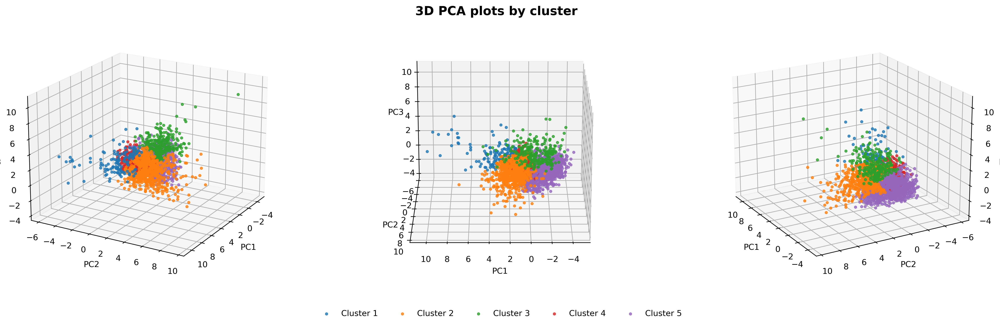

Saved: C:\Dev_AIWM\jupyter\KNN\ROP\Results\M03\PCA\~GA28\PCA30\C5\PCA_3D_clusters_subplots_1x3_300dpi.tiff


In [20]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

PATH = r"C:\Dev_AIWM\jupyter\KNN\ROP\Results\M03\PCA\~GA28\PCA30\C5\df_scd_5clustered.csv"
OUT_DIR = os.path.dirname(PATH)
OUT_TIFF = os.path.join(OUT_DIR, "PCA_3D_clusters_subplots_1x3_300dpi.tiff")

df = pd.read_csv(PATH)

need = {"PC1", "PC2", "PC3", "Cluster_Labels"}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}. Found: {list(df.columns)}")

df["Cluster_Labels"] = pd.to_numeric(df["Cluster_Labels"], errors="coerce")
df = df.dropna(subset=["Cluster_Labels"]).copy()
df["Cluster_Labels"] = df["Cluster_Labels"].astype(int)

clusters = sorted(df["Cluster_Labels"].unique())
views = [(20, 30), (20, 90), (20, 150)]  # (elev, azim)

fig = plt.figure(figsize=(18, 6), dpi=300)
fig.suptitle("3D PCA plots by cluster", y=0.90, weight='bold', fontsize=15)

axes = []
for i, (elev, azim) in enumerate(views, start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    axes.append(ax)

    for lab in clusters:
        sub = df[df["Cluster_Labels"] == lab]
        ax.scatter(sub["PC1"], sub["PC2"], sub["PC3"], s=8, alpha=0.75, label=f"Cluster {lab}")

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.view_init(elev=elev, azim=azim)

# 공통 legend (윤곽선 제거)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6),
           frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.savefig(OUT_TIFF, format="tiff", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", OUT_TIFF)

Missing features (not in df): []


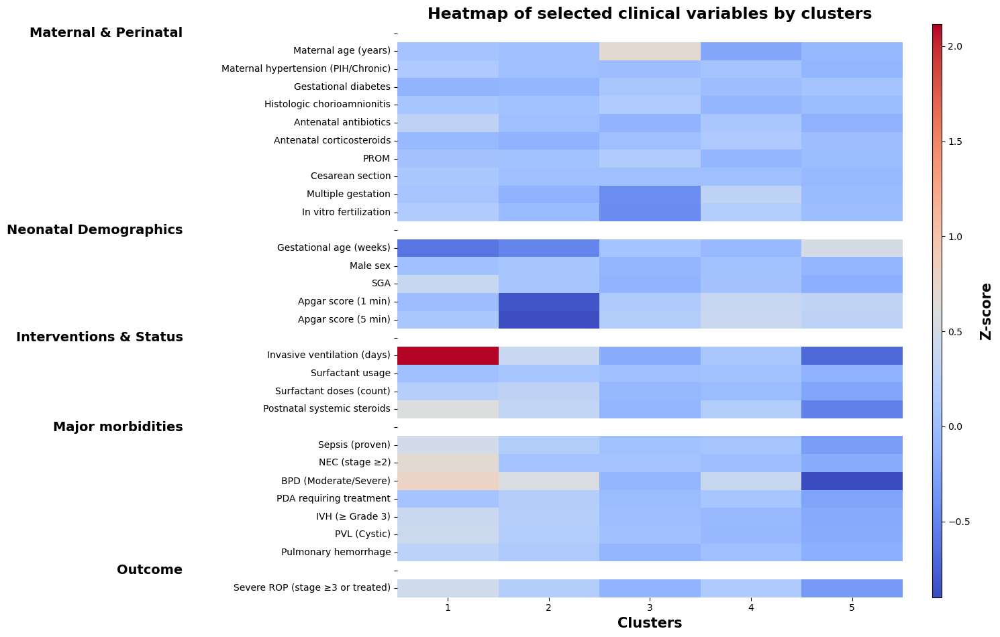

Saved: C:\Dev_AIWM\jupyter\KNN\ROP\Results\M03\PCA\~GA28\PCA30\C5\C5_SelectedVars_Heatmap_300dpi.tiff


In [27]:

ipt_path = r"C:\Dev_AIWM\jupyter\KNN\ROP\Results\M03\PCA\~GA28\PCA30\C5"
data_path = os.path.join(ipt_path, "KNN-ROP_df_combined_M01.csv")

df_ana = pd.read_csv(data_path).copy()

# FEATURE DICTIONARY (cat_name, col_name, feature_name)
rows = [
    # Maternal & Perinatal
    ("Maternal & Perinatal", "mage", "Maternal age (years)"),
    ("Maternal & Perinatal", "htn_maternal", "Maternal hypertension (PIH/Chronic)"),
    ("Maternal & Perinatal", "dm_1", "Gestational diabetes"),
    ("Maternal & Perinatal", "chor_1", "Histologic chorioamnionitis"),
    ("Maternal & Perinatal", "atbyn_1", "Antenatal antibiotics"),
    ("Maternal & Perinatal", "ster_1", "Antenatal corticosteroids"),
    ("Maternal & Perinatal", "prom_1", "PROM"),
    ("Maternal & Perinatal", "delm_2", "Cesarean section"),
    ("Maternal & Perinatal", "mulg_multiple", "Multiple gestation"),
    ("Maternal & Perinatal", "prep_2", "In vitro fertilization"),

    # Neonatal Demographics
    ("Neonatal Demographics", "ga", "Gestational age (weeks)"),
    ("Neonatal Demographics", "sex_sys_val", "Male sex"),
    ("Neonatal Demographics", "sga", "SGA"),
    ("Neonatal Demographics", "apgs1", "Apgar score (1 min)"),
    ("Neonatal Demographics", "apgs5", "Apgar score (5 min)"),

    # Interventions & Status
    ("Interventions & Status", "iarvppd", "Invasive ventilation (days)"),
    ("Interventions & Status", "sft_1", "Surfactant usage"),
    ("Interventions & Status", "sftun", "Surfactant doses (count)"),
    ("Interventions & Status", "strdu_1", "Postnatal systemic steroids"),

    # Major morbidities
    ("Major morbidities", "seps_2", "Sepsis (proven)"),
    ("Major morbidities", "ntet_1", "NEC (stage ≥2)"),
    ("Major morbidities", "bdp_Moderate+", "BPD (Moderate/Severe)"),
    ("Major morbidities", "PDA_TRD", "PDA requiring treatment"),
    ("Major morbidities", "inhg_3+", "IVH (≥ Grade 3)"),
    ("Major morbidities", "pvl_2", "PVL (Cystic)"),
    ("Major morbidities", "mph_1", "Pulmonary hemorrhage"),

    # Outcome
    ("Outcome", "rop_severe", "Severe ROP (stage ≥3 or treated)"),
]

df_dic = pd.DataFrame(rows, columns=["cat_name", "col_name", "feature_name"])



# Check required columns
if "Cluster_Labels" not in df_ana.columns:
    raise ValueError("Column 'Cluster_Labels' not found in the input CSV.")

selected_cols = df_dic["col_name"].tolist()
selected_cols_present = [c for c in selected_cols if c in df_ana.columns]
missing_features = [c for c in selected_cols if c not in df_ana.columns]
print("Missing features (not in df):", missing_features)


# Scaling: numeric columns among selected (exclude Cluster_Labels)
df_selected = df_ana[selected_cols_present + ["Cluster_Labels"]].copy()

# numeric coercion for selected features (keep NaN as NaN)
for c in selected_cols_present:
    df_selected[c] = pd.to_numeric(df_selected[c], errors="coerce")

scaler = StandardScaler()
columns_to_scale = [c for c in selected_cols_present]  # scale only selected features
df_selected[columns_to_scale] = scaler.fit_transform(df_selected[columns_to_scale])


# Cluster mean heatmap table: (features x clusters)
df_heatmap = df_selected.groupby("Cluster_Labels").mean(numeric_only=True).T
df_heatmap = df_heatmap.reindex(selected_cols_present)


# Expand with category separators + English labels
expanded_idx, expanded_data = [], []
previous_cat = None
cat_name_positions, cat_labels = [], []
current_pos = 0

for cat, col, fname in zip(df_dic["cat_name"], df_dic["col_name"], df_dic["feature_name"]):
    if col not in df_heatmap.index:
        continue

    if cat != previous_cat:
        expanded_idx.append("")
        expanded_data.append([np.nan] * df_heatmap.shape[1])
        cat_name_positions.append(current_pos + 0.5)
        cat_labels.append(cat)
        current_pos += 1
        previous_cat = cat

    label = fname if (pd.notna(fname) and str(fname).strip() != "") else col
    expanded_idx.append(label)
    expanded_data.append(df_heatmap.loc[col].values)
    current_pos += 1

df_heatmap_expanded = pd.DataFrame(expanded_data, index=expanded_idx, columns=df_heatmap.columns)


# Plot
mask = df_heatmap_expanded.isna().copy()
mask[df_heatmap_expanded.index == ""] = True

fig = plt.figure(figsize=(15, max(6, len(df_heatmap_expanded) * 0.30)))
gs = GridSpec(1, 7, width_ratios=[1, 1, 1, 1, 1, 0.1, 0.1], figure=fig)

ax = fig.add_subplot(gs[0, :5])

sns.heatmap(
    df_heatmap_expanded,
    cmap="coolwarm",
    annot=False,
    cbar=False,
    linewidths=0,
    mask=mask,
    ax=ax
)

yticks_labels = [" " if idx == "" else idx for idx in df_heatmap_expanded.index.tolist()]
ax.set_yticks(np.arange(len(yticks_labels)) + 0.5)
ax.set_yticklabels(yticks_labels, fontsize=10, fontweight="normal")

ax.set_xlabel("Clusters", fontsize=15, fontweight="bold")
ax.set_title("Heatmap of selected clinical variables by clusters", fontsize=17, fontweight="bold")

# category labels axis (left)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(cat_name_positions)
ax2.spines["left"].set_position(("outward", 180))
ax2.tick_params(axis="y", pad=6)
plt.subplots_adjust(left=0.22)
ax2.set_yticklabels(cat_labels, fontsize=14, fontweight="bold", va="center", ha="right")

ax2.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom", "left"]:
    ax2.spines[side].set_visible(False)
ax2.set_xlim(ax.get_xlim())
ax2.set_ylabel("")
ax2.yaxis.set_label_position("left")
ax2.yaxis.tick_left()
ax2.yaxis.set_tick_params(pad=50)

# colorbar
cbar_ax = fig.add_subplot(gs[0, 6])
hm = ax.collections[0]
cb = fig.colorbar(hm, cax=cbar_ax)
cb.set_label("Z-score", rotation=90, fontsize=15, labelpad=10, fontweight="bold")

plt.tight_layout()

# save
# out_pdf = os.path.join(ipt_path, "C5_SelectedVars_Heatmap.pdf")
out_tiff = os.path.join(ipt_path, "C5_SelectedVars_Heatmap_300dpi.tiff")
# plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.savefig(out_tiff, format="tiff", dpi=300, bbox_inches="tight")
plt.show()

# print("Saved:", out_pdf)
print("Saved:", out_tiff)

Missing features (not in df): []


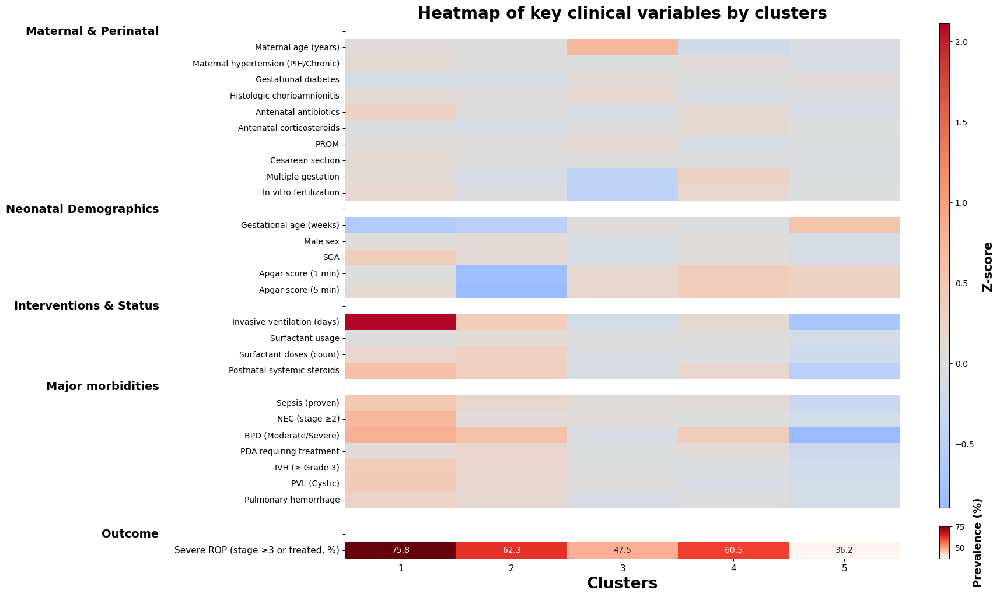

Saved: C:\Dev_AIWM\jupyter\KNN\ROP\Results\M03\PCA\~GA28\PCA30\C5\C5_SelectedVars_Heatmap_ROPprev.tiff


In [36]:
# Mod 2 - Outcome title on upper line + reduce gap between maps

ipt_path = r"C:\Dev_AIWM\jupyter\KNN\ROP\Results\M03\PCA\~GA28\PCA30\C5"
data_path = os.path.join(ipt_path, "KNN-ROP_df_combined_M01.csv")

df_ana = pd.read_csv(data_path).copy()

# FEATURE DICTIONARY
rows = [
    ("Maternal & Perinatal", "mage", "Maternal age (years)"),
    ("Maternal & Perinatal", "htn_maternal", "Maternal hypertension (PIH/Chronic)"),
    ("Maternal & Perinatal", "dm_1", "Gestational diabetes"),
    ("Maternal & Perinatal", "chor_1", "Histologic chorioamnionitis"),
    ("Maternal & Perinatal", "atbyn_1", "Antenatal antibiotics"),
    ("Maternal & Perinatal", "ster_1", "Antenatal corticosteroids"),
    ("Maternal & Perinatal", "prom_1", "PROM"),
    ("Maternal & Perinatal", "delm_2", "Cesarean section"),
    ("Maternal & Perinatal", "mulg_multiple", "Multiple gestation"),
    ("Maternal & Perinatal", "prep_2", "In vitro fertilization"),

    ("Neonatal Demographics", "ga", "Gestational age (weeks)"),
    ("Neonatal Demographics", "sex_sys_val", "Male sex"),
    ("Neonatal Demographics", "sga", "SGA"),
    ("Neonatal Demographics", "apgs1", "Apgar score (1 min)"),
    ("Neonatal Demographics", "apgs5", "Apgar score (5 min)"),

    ("Interventions & Status", "iarvppd", "Invasive ventilation (days)"),
    ("Interventions & Status", "sft_1", "Surfactant usage"),
    ("Interventions & Status", "sftun", "Surfactant doses (count)"),
    ("Interventions & Status", "strdu_1", "Postnatal systemic steroids"),

    ("Major morbidities", "seps_2", "Sepsis (proven)"),
    ("Major morbidities", "ntet_1", "NEC (stage ≥2)"),
    ("Major morbidities", "bdp_Moderate+", "BPD (Moderate/Severe)"),
    ("Major morbidities", "PDA_TRD", "PDA requiring treatment"),
    ("Major morbidities", "inhg_3+", "IVH (≥ Grade 3)"),
    ("Major morbidities", "pvl_2", "PVL (Cystic)"),
    ("Major morbidities", "mph_1", "Pulmonary hemorrhage"),

    ("Outcome", "rop_severe", "Severe ROP (stage ≥3 or treated, %)"),
]

df_dic = pd.DataFrame(rows, columns=["cat_name", "col_name", "feature_name"])

if "Cluster_Labels" not in df_ana.columns:
    raise ValueError("Column 'Cluster_Labels' not found in the input CSV.")

selected_cols = df_dic["col_name"].tolist()
selected_cols_present = [c for c in selected_cols if c in df_ana.columns]
missing_features = [c for c in selected_cols if c not in df_ana.columns]
print("Missing features (not in df):", missing_features)

outcome_col = "rop_severe"
feature_cols = [c for c in selected_cols_present if c != outcome_col]

# raw selected
df_selected = df_ana[selected_cols_present + ["Cluster_Labels"]].copy()
for c in selected_cols_present:
    df_selected[c] = pd.to_numeric(df_selected[c], errors="coerce")

# =========================
# 1) Z-score heatmap data
# =========================
df_scaled = df_selected[feature_cols + ["Cluster_Labels"]].copy()

scaler = StandardScaler()
df_scaled[feature_cols] = scaler.fit_transform(df_scaled[feature_cols])

df_heatmap = df_scaled.groupby("Cluster_Labels").mean(numeric_only=True).T
df_heatmap = df_heatmap.reindex(feature_cols)

expanded_idx, expanded_data = [], []
previous_cat = None
cat_name_positions, cat_labels = [], []
current_pos = 0

for cat, col, fname in zip(df_dic["cat_name"], df_dic["col_name"], df_dic["feature_name"]):
    if col == outcome_col or col not in df_heatmap.index:
        continue

    if cat != previous_cat:
        expanded_idx.append("")
        expanded_data.append([np.nan] * df_heatmap.shape[1])
        cat_name_positions.append(current_pos + 0.5)
        cat_labels.append(cat)
        current_pos += 1
        previous_cat = cat

    expanded_idx.append(fname if str(fname).strip() else col)
    expanded_data.append(df_heatmap.loc[col].values)
    current_pos += 1

df_heatmap_expanded = pd.DataFrame(
    expanded_data,
    index=expanded_idx,
    columns=df_heatmap.columns
)

# =========================
# 2) Outcome prevalence data
#    add blank separator row above to place category label like others
# =========================
if outcome_col in selected_cols_present:
    outcome_vals = (df_selected.groupby("Cluster_Labels")[outcome_col].mean() * 100).values
    df_outcome = pd.DataFrame(
        [np.full(len(df_heatmap.columns), np.nan), outcome_vals],
        index=["", "Severe ROP (stage ≥3 or treated, %)"],
        columns=df_heatmap.columns
    )
    outcome_cat_pos = [0.5]   # blank row centre
    outcome_cat_labels = ["Outcome"]
else:
    df_outcome = pd.DataFrame()
    outcome_cat_pos, outcome_cat_labels = [], []

# =========================
# 3) Plot
# =========================
fig = plt.figure(figsize=(15, max(7, len(df_heatmap_expanded) * 0.32 + 1.2)))
gs = GridSpec(
    2, 7,
    height_ratios=[len(df_heatmap_expanded), 2.0],
    width_ratios=[1, 1, 1, 1, 1, 0.10, 0.10],
    hspace=0.07,   # reduced from previous setting
    figure=fig
)

# main heatmap
ax = fig.add_subplot(gs[0, :5])
mask_main = df_heatmap_expanded.isna().copy()
mask_main[df_heatmap_expanded.index == ""] = True

sns.heatmap(
    df_heatmap_expanded,
    cmap="coolwarm",
    annot=False,
    cbar=False,
    linewidths=0,
    mask=mask_main,
    ax=ax,
    center=0
)

yticks_labels = [" " if idx == "" else idx for idx in df_heatmap_expanded.index.tolist()]
ax.set_yticks(np.arange(len(yticks_labels)) + 0.5)
ax.set_yticklabels(yticks_labels, fontsize=10, fontweight="normal")

# hide x tick labels on the top heatmap
ax.set_xlabel("")
ax.set_xticklabels([])
ax.tick_params(axis="x", bottom=False, labelbottom=False)

ax.set_title("Heatmap of key clinical variables by clusters", fontsize=20, fontweight="bold")

# left category labels for main heatmap
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(cat_name_positions)
ax2.spines["left"].set_position(("outward", 180))
ax2.set_yticklabels(cat_labels, fontsize=14, fontweight="bold", va="center", ha="right")
ax2.tick_params(axis="y", length=0, pad=50)
for side in ["top", "right", "bottom", "left"]:
    ax2.spines[side].set_visible(False)
ax2.set_ylabel("")
ax2.yaxis.set_label_position("left")
ax2.yaxis.tick_left()

# z-score colorbar
cax1 = fig.add_subplot(gs[0, 6])
cb1 = fig.colorbar(ax.collections[0], cax=cax1)
cb1.set_label("Z-score", rotation=90, fontsize=15, labelpad=10, fontweight="bold")

# outcome heatmap
ax_out = fig.add_subplot(gs[1, :5])

if not df_outcome.empty:
    mask_out = df_outcome.isna().copy()
    mask_out[df_outcome.index == ""] = True

    sns.heatmap(
        df_outcome,
        cmap="Reds",
        annot=np.array([[""] * df_outcome.shape[1], [f"{v:.1f}" for v in df_outcome.iloc[1].values]], dtype=object),
        fmt="",
        cbar=False,
        linewidths=0,
        mask=mask_out,
        ax=ax_out
    )

    out_labels = [" " if idx == "" else idx for idx in df_outcome.index.tolist()]
    ax_out.set_yticks(np.arange(len(out_labels)) + 0.5)
    ax_out.set_yticklabels(out_labels, fontsize=11, fontweight="normal", rotation=0)
    ax_out.set_xlabel("Clusters", fontsize=19, fontweight="bold")
    ax_out.set_ylabel("")
    ax_out.tick_params(axis="x", labelsize=11)
else:
    ax_out.axis("off")

# left category label for outcome panel - on upper blank row
ax_out2 = ax_out.twinx()
ax_out2.set_ylim(ax_out.get_ylim())
ax_out2.set_yticks(outcome_cat_pos)
ax_out2.spines["left"].set_position(("outward", 180))
ax_out2.set_yticklabels(outcome_cat_labels, fontsize=14, fontweight="bold", va="center", ha="right")
ax_out2.tick_params(axis="y", length=0, pad=50)
for side in ["top", "right", "bottom", "left"]:
    ax_out2.spines[side].set_visible(False)
ax_out2.set_ylabel("")
ax_out2.yaxis.set_label_position("left")
ax_out2.yaxis.tick_left()

# outcome colorbar
cax2 = fig.add_subplot(gs[1, 6])
if not df_outcome.empty:
    cb2 = fig.colorbar(ax_out.collections[0], cax=cax2)
    cb2.set_label("Prevalence (%)", rotation=90, fontsize=13, labelpad=10, fontweight="bold")
else:
    cax2.axis("off")

plt.subplots_adjust(left=0.26, right=0.95, top=0.93, bottom=0.08)

out_tiff = os.path.join(ipt_path, "C5_SelectedVars_Heatmap_ROPprev.tiff")
plt.savefig(out_tiff, format="tiff", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_tiff)

In [599]:
# P-value 리스트의 길이를 Feature 리스트와 정확히 맞춤

feature_pvalues = {
    "Feature": [
        "ga", "arre28_0", "bdp", "bwei", "bdp_Moderate+", "oxyt28_1", "iarvppd", "bhead", 
        "arre28_6", "oxyt36_1", "strdu_1", "bhei", "arre36_0", "pdatr_15", "resui_1", "sft_1", 
        "niarvrpd", "sftun", "pda_non-treatment", "rds_1", "oxyt28_3", "apgs1", "pdad_2", "lbp_1",
        "apgs5", "pdadty_2", "pdatr_13", "sftup_1", "strdut1", "oxyt36_2", "arre36_7", "resup_1",
        "paddr1", "acl_2", "seps_2", "strdud1", "seps_1", "bsf1", "inhg_2+"
    ],
    "P-value": [
        3.6664e-275, 0.0000e+00, 9.2028e-127, 0.0000e+00, 7.6381e-16, 2.1682e-129, 
        2.5945e-102, 0.0000e+00, 0.0099, 0.0000e+00, 3.5910e-27, 0.0000e+00, 5.5793e-06, 
        0.0000e+00, 7.1781e-81, 0.0000e+00, 5.5953e-118, 0.0000e+00, np.nan, 
        5.1738e-125, 0.0006, 1.9213e-28, 0.0000e+00, np.nan, 3.0405e-27, 0.0000e+00, 
        np.nan, np.nan, np.nan, 7.9070e-304, 0.0000e+00, 3.2999e-46, 8.5473e-136, 
        0.0000e+00, np.nan, 4.2803e-239, 9.7494e-251
    ]
}

# 데이터프레임 생성
df_feature_pvalues = pd.DataFrame(feature_pvalues)

# P-value를 기준으로 정렬 (낮을수록 중요)
df_feature_pvalues_sorted = df_feature_pvalues.sort_values(by="P-value")


ValueError: All arrays must be of the same length

In [8]:
data = {
    "Model": ["Hierarchical", "Hierarchical", "Hierarchical", "K-Means", "K-Means", "K-Means", 
              "GM", "GM", "GM", "HDBSCAN", "HDBSCAN", "HDBSCAN"],
    "Cluster": ["Cluster 1", "Cluster 2", "Cluster 3"] * 4,
    "Total": [11333, 3621, 2875, 5936, 11450, 443, 15884, 1925, 20, 234, 5439, 12156],
    "Positive Rate (iperr_Pos)": [1.66, 1.88, 5.88, 5.80, 0.71, 0.00, 1.79, 7.27, 0.00, 2.99, 3.57, 1.84],
    "Positive Rate (ntet_Pos)": [4.89, 5.80, 14.30, 14.08, 2.93, 0.68, 5.25, 17.45, 25.00, 8.12, 9.08, 5.45],
    "Positive Rate (death36_Pos)": [1.91, 1.33, 2.64, 4.33, 0.72, 0.23, 1.57, 4.73, 0.00, 8.12, 2.41, 1.56]
}

df = pd.DataFrame(data)
df

,Model,Cluster,Total,Positive Rate (iperr_Pos),Positive Rate (ntet_Pos),Positive Rate (death36_Pos)
0,Hierarchical,Cluster 1,11333,1.66,4.89,1.91
1,Hierarchical,Cluster 2,3621,1.88,5.80,1.33
2,Hierarchical,Cluster 3,2875,5.88,14.30,2.64
3,K-Means,Cluster 1,5936,5.80,14.08,4.33
4,K-Means,Cluster 2,11450,0.71,2.93,0.72
5,K-Means,Cluster 3,443,0.00,0.68,0.23
6,GM,Cluster 1,15884,1.79,5.25,1.57
7,GM,Cluster 2,1925,7.27,17.45,4.73
8,GM,Cluster 3,20,0.00,25.00,0.00
9,HDBSCAN,Cluster 1,234,2.99,8.12,8.12


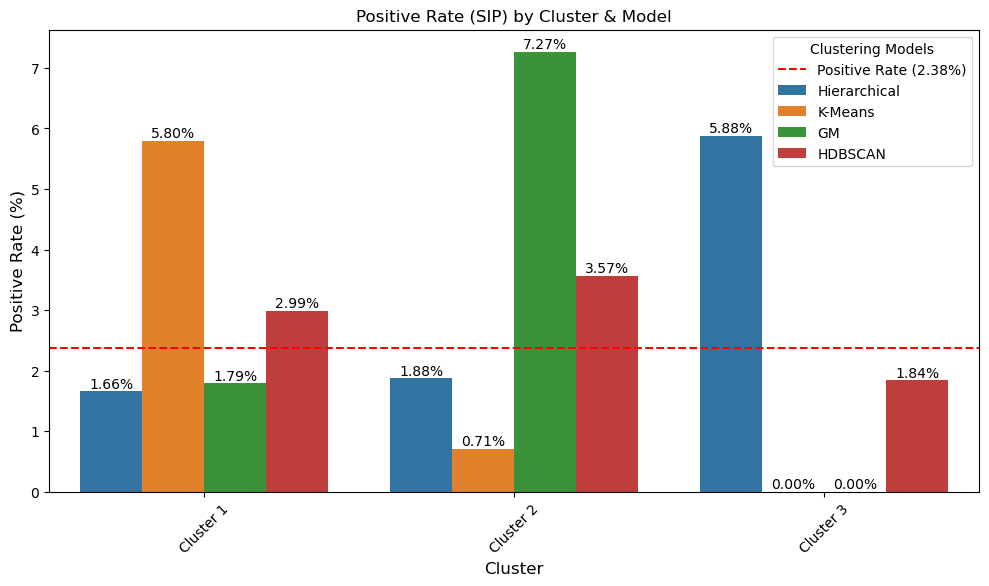

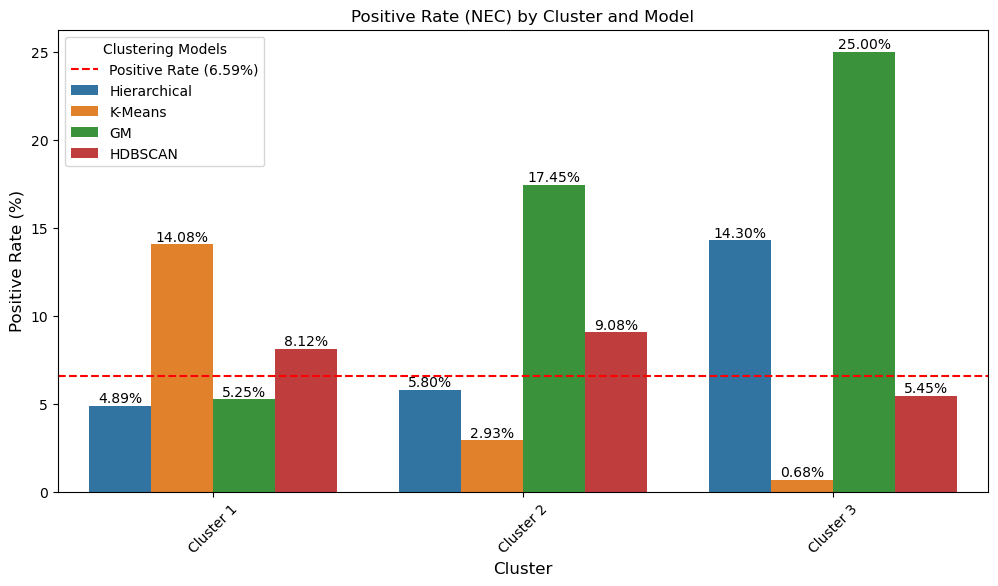

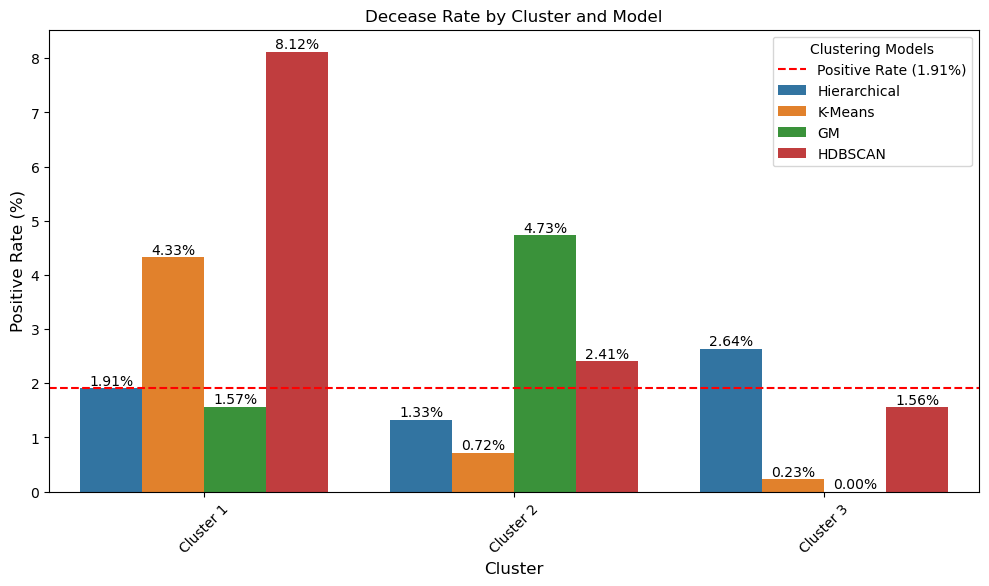

In [21]:
# Threshold 값 설정
thresholds = {
    "Positive Rate (iperr_Pos)": 2.38,
    "Positive Rate (ntet_Pos)": 6.59,
    "Positive Rate (death36_Pos)": 1.91
}

# 시각화 함수 정의
def plot_bar_with_threshold(y_col, title, threshold):
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x="Cluster", y=y_col, hue="Model", data=df)

    # Bar 위에 값(%) 표기
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%",  # 값 표기
                    (p.get_x() + p.get_width() / 2., p.get_height()),  # 위치 조정
                    ha="center", va="bottom", fontsize=10, color="black")

    # Threshold 점선 추가
    plt.axhline(threshold, color="red", linestyle="dashed", linewidth=1.5, label=f"Positive Rate ({threshold}%)")

    plt.title(title)
    plt.ylabel("Positive Rate (%)", fontsize=12)
    plt.xlabel("Cluster", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="Clustering Models")
    plt.show()


plot_bar_with_threshold("Positive Rate (iperr_Pos)"
                        , "Positive Rate (SIP) by Cluster & Model"
                        , thresholds["Positive Rate (iperr_Pos)"]
                       )
plot_bar_with_threshold("Positive Rate (ntet_Pos)"
                        , "Positive Rate (NEC) by Cluster and Model"
                        , thresholds["Positive Rate (ntet_Pos)"]
                       )
plot_bar_with_threshold("Positive Rate (death36_Pos)"
                        , "Decease Rate by Cluster and Model"
                        , thresholds["Positive Rate (death36_Pos)"]
                       )



# plt.figure(figsize=(12, 6))
# sns.barplot(x="Cluster", y="Positive Rate (iperr_Pos)", hue="Model", data=df)
# plt.title("Positive Rate (iperr_Pos) by Cluster and Model")
# plt.ylabel("Positive Rate (%)")
# plt.xlabel("Cluster")
# plt.xticks(rotation=45)
# plt.legend(title="Clustering Model")
# plt.show()

# # ntet_Pos Positive Rate 시각화
# plt.figure(figsize=(12, 6))
# sns.barplot(x="Cluster", y="Positive Rate (ntet_Pos)", hue="Model", data=df)
# plt.title("Positive Rate (ntet_Pos) by Cluster and Model")
# plt.ylabel("Positive Rate (%)")
# plt.xlabel("Cluster")
# plt.xticks(rotation=45)
# plt.legend(title="Clustering Model")
# plt.show()

# # death36_Pos Positive Rate 시각화
# plt.figure(figsize=(12, 6))
# sns.barplot(x="Cluster", y="Positive Rate (death36_Pos)", hue="Model", data=df)
# plt.title("Positive Rate (death36_Pos) by Cluster and Model")
# plt.ylabel("Positive Rate (%)")
# plt.xlabel("Cluster")
# plt.xticks(rotation=45)
# plt.legend(title="Clustering Model")
# plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3524\2814283329.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_pivot = df.pivot("Cluster", "Model", y_col)  # Cluster x Model 구조로 변환


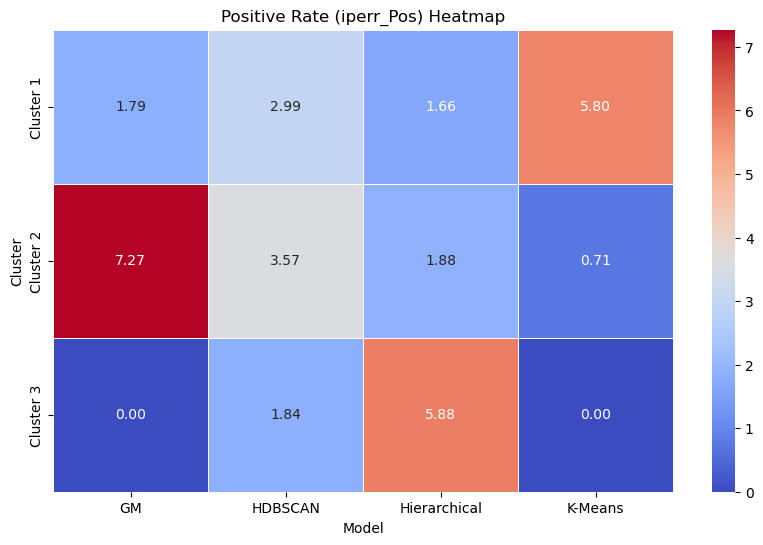

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3524\2814283329.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_pivot = df.pivot("Cluster", "Model", y_col)  # Cluster x Model 구조로 변환


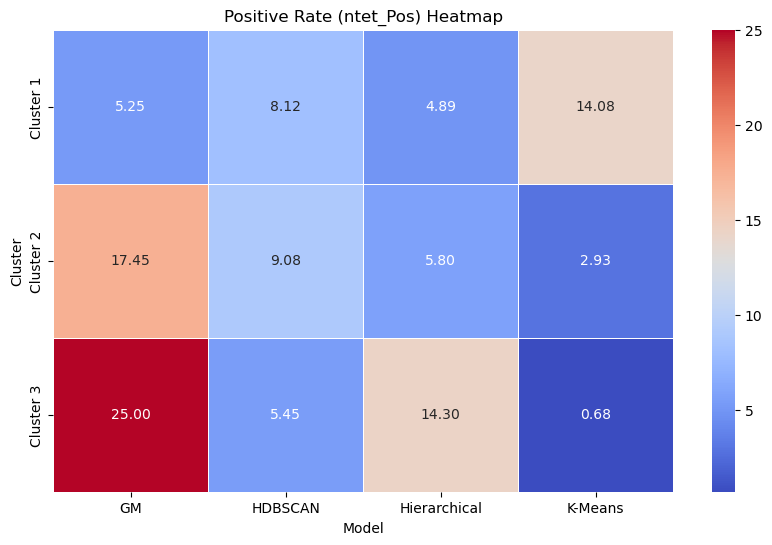

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_3524\2814283329.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_pivot = df.pivot("Cluster", "Model", y_col)  # Cluster x Model 구조로 변환


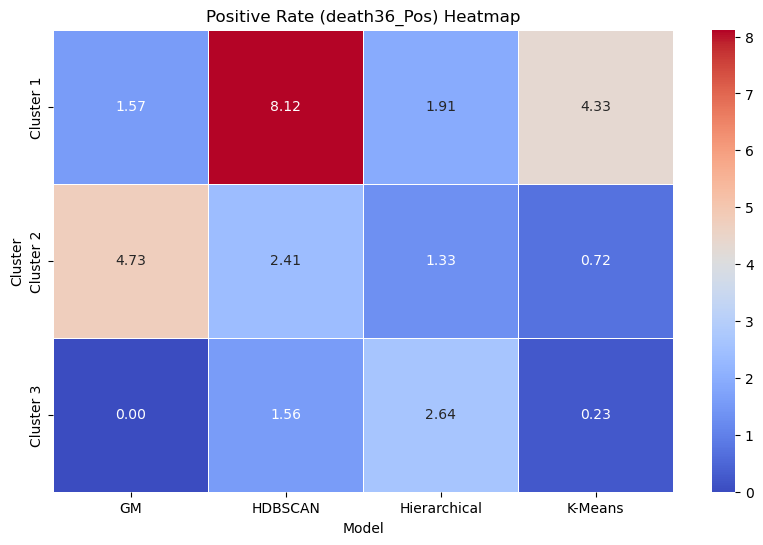

In [15]:
def plot_heatmap(y_col, title):
    plt.figure(figsize=(10, 6))
    df_pivot = df.pivot("Cluster", "Model", y_col)  # Cluster * Model 구조로 변환
    sns.heatmap(df_pivot, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

    plt.title(title)
    plt.show()

# 3가지 Positive Rate에 대해 Heatmap 생성
plot_heatmap("Positive Rate (iperr_Pos)", "Positive Rate (iperr_Pos) Heatmap")
plot_heatmap("Positive Rate (ntet_Pos)", "Positive Rate (ntet_Pos) Heatmap")
plot_heatmap("Positive Rate (death36_Pos)", "Positive Rate (death36_Pos) Heatmap")

In [6]:


# 중복 제거
final_columns = list(set(lower_cols))

# 데이터에서 필요한 칼럼들만 추출
knn_df_cols = knn_df.columns.intersection(final_columns)
# knn_df_ftd = knn_df[knn_df_cols]

# 데이터셋에 없는 칼럼 찾기
missing_columns = list(set(req_cols) - set(knn_df_cols))

# 결과 출력
# print("선택된 칼럼의 데이터:")
print("len(knn_df_cols):", len(knn_df_cols))
print(knn_df_cols)
print()
# print("\n데이터셋에 없는 칼럼:")
print("len(missing_columns):", len(missing_columns))
print(missing_columns)

len(knn_df_cols): 154
Index(['sex_sys_val', 'sex', 'mulg', 'bir1', 'bir2', 'bir3', 'bir4', 'prep',
       'dm', 'htn',
       ...
       'menifs', 'invfpod', 'ntet', 'ntetdt', 'ntety', 'ntetoy', 'ntetdty',
       'iperr', 'iperroy', 'iperrdt'],
      dtype='object', length=154)

len(missing_columns): 173
['ADMD', 'NESE', 'DATE36', 'STRDUD1', 'INHG', 'BHTCUT', 'SFTTHDT', 'PDADDTH', 'BSF3', 'FSF2', 'BHEADUK', 'IPERRDT', 'BSF2', 'INC3', 'SFTUH', 'PHH', 'FSFDT2', 'NTETOY', 'LBPD3', 'CMT2', 'birthdt_sys_val', 'APGUK1', 'BSFFS1', 'BTEM', 'MENIDT', 'ARRE36', 'BHEAD', 'NTETDT', 'PROM', 'FSFFS2', 'DATE362', 'GAGED', 'PADDR1', 'STERD2', 'FSF1', 'MCOU', 'IPERROY', 'MEDU', 'DM', 'MERR', 'PHUD6', 'PHUDOT', 'BDP_J', 'MENI', 'PDADDT', 'GRAN', 'GAGEW', 'SFT', 'BIRD', 'BTEMUK', 'NTET', 'PREP', 'FETC', 'BSFDT2', 'CMT1', 'LBP', 'INC1', 'PHUD7', 'BBBE', 'NIARVHFNC', 'PADDR2', 'BIRDH', 'BBBEUK', 'SEPS', 'NTETDTY', 'METC', 'ATBYN', 'BSFFS3', 'CHOR', 'STRDUD4', 'PROMN', 'PHUD2', 'age_sys_val', 'STRDUT1', 'ME

In [7]:
knn_df_cols

Index(['sex_sys_val', 'sex', 'mulg', 'bir1', 'bir2', 'bir3', 'bir4', 'prep',
       'dm', 'htn',
       ...
       'menifs', 'invfpod', 'ntet', 'ntetdt', 'ntety', 'ntetoy', 'ntetdty',
       'iperr', 'iperroy', 'iperrdt'],
      dtype='object', length=154)

In [8]:
filtered_knn_df = knn_df_ftd[(knn_df_ftd['ntet'] == 2) | (knn_df_ftd['iperr'] == 2)]

# 결과 출력
print("필터링된 데이터의 크기:", filtered_knn_df.shape)
print(filtered_knn_df)

필터링된 데이터의 크기: (1174, 43)
      subjnm  sex_sys_val     birthdt  mulg  bir1  bir2  bir3  bir4  prep  \
0        ㅂㅈㅂ            1  2013-01-05     1   NaN   NaN   NaN   NaN     1   
17       ㅎㅅㅈ            1  2013-02-09     1   NaN   NaN   NaN   NaN     1   
29      ㅈㅇㅎ2            2  2013-04-27     2   NaN   2.0   NaN   NaN     1   
40      ㅂㅈㅇ1            1  2013-07-13     2   1.0   NaN   NaN   NaN     2   
50       ㄱㅈㅇ            1  2013-03-29     1   NaN   NaN   NaN   NaN     1   
...      ...          ...         ...   ...   ...   ...   ...   ...   ...   
14474    ㄱㅅㅇ            1  2019-12-04     1   NaN   NaN   NaN   NaN     2   
14490    ㅊㅅㅇ            2  2019-07-26     1   NaN   NaN   NaN   NaN     2   
14491   ㄱㅅㅎ2            1  2019-07-26     2   NaN   2.0   NaN   NaN     2   
14500    ㅇㅇㄴ            2  2019-10-03     1   NaN   NaN   NaN   NaN     1   
14507    ㅇㅈㅇ            2  2019-11-30     1   NaN   NaN   NaN   NaN     2   

       htn  ...  paddr2  pdadty      pdaddt  pdadd

In [9]:
filtered_knn_df.to_csv(f"{raw_path}/knn_p3.csv")

In [10]:
for column in filtered_knn_df.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {filtered_knn_df[column].dtype}")
    print(f"유니크한 값:")
    print(filtered_knn_df[column].unique())
    print("-" * 40)

칼럼 이름: subjnm
데이터 타입: object
유니크한 값:
['ㅂㅈㅂ' 'ㅎㅅㅈ' 'ㅈㅇㅎ2' 'ㅂㅈㅇ1' 'ㄱㅈㅇ' 'ㅇㅂㄹ' 'ㅊㅇㅎ' 'ㅂㅊㅎ' 'ㅈㅇㅈ3' 'ㅇㅈㅎ1' 'ㅇㄷㅇ2'
 'ㅈㅇㅈ2' 'ㅂㅁㄱ' 'ㅂㅂㄹ' 'ㅊㅈㅇ' 'ㅎㅎㅎ1' 'ㅎㅎㄴ2' 'ㅇㅈㅇ2' 'ㄹㅇㅇ' 'ㅂㄱㅎ' 'ㅇㅇㄹ' 'ㅇㅎㅈ'
 'ㅂㅈㅎ' 'ㅈㅎㅇ' 'ㄱㅎㄴ' 'ㅇㅈㅎ' 'ㅇㅎㅇ' 'ㄱㅎㄹ1' 'ㅁㄱㅇ2' 'ㅇㅊㅅ' 'ㄱㅇㅈ' 'ㅈㅎㄹ' 'ㅇㅇㅈ2'
 'ㅈㅈㅇ' 'ㅇㅅㅇ' 'ㄱㅁㅈ' 'ㅇㅁㅇ1' 'ㅈㅁㅅ1' 'ㅎㅎㅇ' 'ㄱㅈㅎ1' 'ㅇㅎㅎ' 'ㅅㅇㅎ' 'ㅊㄱㅅ' 'ㅈㅎㅈ'
 'ㅂㅇㅈ2' 'ㄱㅈㅎ2' 'ㅇㅎㅅ' 'ㅇㅇㅈ' 'ㄱㅈㅇ2' 'ㄱㄱㅇ' 'ㅊㅈ' 'ㄱㅇ' 'ㅈㅁㅇ' 'ㄱㄱㄹ' 'ㅂㅈㅎ2'
 'ㄱㅇㅅ2' 'ㅂㅎㅈ' 'ㅇㄱㅇ' 'ㅂㅈㅇ' 'ㅇㅂㅇ' 'ㄱㅅㅈ' 'ㅊㅇㅇ' 'ㅇㅈㅅ' 'ㅂㅇㄹ' 'ㅇㅅㅎ' 'ㅅㅂㅎ' 'ㄹㅌㅈ'
 'ㅇㅇㅁ' 'ㅈㅅㅎ' 'ㄱㄷㅇ' 'ㅂㅁㅇ' 'ㄱㅅㅁ3' 'ㅇㅁㄹ' 'ㅇㅈㅇ' 'ㅈㅈㅎ' 'ㄱㅁㅇ' 'ㅂㅅㅇ' 'ㅇㅎㅈㅇㄱ'
 'ㅊㅇㅈ' 'ㅈㅇㅇ' 'ㅂㅅㅎ' 'ㅂㅇㅁ' 'ㄱㅇㄹ' 'ㄱㅈㅇㅇㄱ2' 'ㅇㅅㅇㅇㄱ2' 'ㅊㅇㅁㅇㄱ' 'ㅂㅅㅈ' 'ㅇㅇㅎ'
 'ㅅㅇㅈ1' 'ㄱㅅㅎ' 'ㅊㅎㅅ' 'ㄱㄴㅇ' 'ㅈㅈㅇ1' 'ㄱㅅㅇ2' 'ㅈㅁㅅ' 'ㄱㅊㄹ' 'KHJB' 'ㅊㅈㅎ' 'ㅈㅎㅁ'
 'ㅇㄱㅎ' 'ㄱㅁㅅ' 'ㄱㅅㅎ2' 'ㅎㅁㅎ' 'ㅂㅅㅁ' 'ㅁㅎㅅ1' 'ㅅㅎㄹ2' 'ㄱㅅㅁ' 'ㄹㅅㅅ1' 'ㅈㅅㄹ2' 'ㅂㅇㅅ'
 'ㄹㅅㅅ2' 'ㅂㅅㅎ2' 'ㅎㅅㅂ' 'ㅇㅅㅇ1' 'ㅅㅇㅁ1' 'ㄴㅅㅎ' 'ㅇㅅㅁ1' 'ㄱㅎㅈ' 'ㅅㅈㅎ' 'ㅊㅅㅎ' 'ㄱㅈㅅ'
 'ㄱㅂㄱ' 'ㅈㅂㅇ' 'ㄴㅈㅅ' 'ㅈㅇㅇ2' 'ㅈㅁㅈ2' 'ㄱㅁㅇ2' 'ㅊㅁㄹ2' 'CB' 'ㄱㅈㅎ' 'ㅇㅁㅇ2' 'ㅂㅅㅇ2'
 'ㅇㅁㅈ' '김준서' '정이빈' 'ㄱㅇㅈ1' 'ㅁㅎㅇ' 'ㄱㅅㅇ' 'ㄱㅈㅁ' 'ㅈㅇㄹ' 'ㅎㅈㅇ' 'ㅊㅇㄹ1' 'ㅊㅇㄹ2'
 'ㅇㄷㅇ' 'ㄱㅇㅅ' 'ㅅㄱㅎ1' 'ㅇㅁㅈ1' 'ㅇㅁㅈ2' 'ㅁㅇㅇ' '

In [11]:
df = filtered_knn_df

# 1. 칼럼 'sex_sys_val' 처리
df = df[(df['sex_sys_val'] == 1) | (df['sex_sys_val'] == 2)]
df['sex_sys_val'] = df['sex_sys_val'].replace({1: 0, 2: 1})

# 2. 칼럼 'birthdt' 삭제
df.drop('birthdt', axis=1, inplace=True)

# 3. 칼럼 'mulg'로부터 더미 변수 생성
mulg_dummies = pd.get_dummies(df['mulg'], prefix='mulg', drop_first=False)
mulg_dummies.columns = ['mulg_single', 'mulg_twin', 'mulg_triplet']
df = pd.concat([df, mulg_dummies], axis=1)
df.drop('mulg', axis=1, inplace=True)

# 4. 'ntety', 'bir1', 'bir2', 'bir3' 값 변환
df['ntety'] = df['ntety'].fillna(0)
df['bir1'] = df['bir1'].fillna(0)
df['bir2'] = df['bir2'].fillna(0).replace({2: 1})
df['bir3'] = df['bir3'].fillna(0).replace({3: 1})

# 5. 칼럼 'bir4' 삭제
df.drop('bir4', axis=1, inplace=True)

# 6. 칼럼 'prep' 값 변환
df['prep'] = df['prep'].replace({1: 0, 2: 1})

# 7. 칼럼 'htn' 더미 변수 생성
htn_dummies = pd.get_dummies(df['htn'], prefix='htn')
df = pd.concat([df, htn_dummies], axis=1)
df.drop('htn', axis=1, inplace=True)

'''
# 8. 칼럼 'dm' 더미 변수 생성
dm_dummies = pd.get_dummies(df['dm'], prefix='dm')
df = pd.concat([df, dm_dummies], axis=1)
df.drop('dm', axis=1, inplace=True)
'''

# 9-11. 'prom' 및 'ster', 'resu'처리 (Convert to binary + Nan value)
df['prom'] = df['prom'].replace({1: 0, 2: 1, 3: 2})
df['ster'] = df['ster'].replace({1: 0, 2: 1, 3: 2})
df['resu'] = df['resu'].replace({1: 0, 2: 1, 3: 2})

# 11. 'delm' 값 변환
df['delm'] = df['delm'].replace({1: 0, 2: 1})

# 12. 'sterd2' 값 변환
df['sterd2'] = df['sterd2'].fillna(0).replace({2: 1})

# 14-18. 'resuo', 'resup', 'resui', 'resuh', 'resue' 처리
for column in ['resuo', 'resup', 'resui', 'resuh', 'resue']:
    if df[column].isnull().mean() < 0.5:
        df[column] = df[column].fillna(0).replace({1: 0, 2: 1})
    else:
        df.drop(column, axis=1, inplace=True)

# 19. 'pdad' 처리
if df['pdad'].isnull().mean() < 0.5:
    df['pdad'] = df['pdad'].replace({1: 0, 2: 1})
else:
    df.drop('pdad', axis=1, inplace=True)

# 20. 'paddr2' 값 변환
df['paddr2'] = df['paddr2'].fillna(0).replace({2: 1})

# 21. 'pdadty' 더미 변수 생성 후 조건에 따라 삭제
if df['pdadty'].isnull().mean() < 0.5:
    if (df['pdadty'] == 3).mean() < 0.5:
        pdadty_dummies = pd.get_dummies(df['pdadty'], prefix='pdadty')
        df = pd.concat([df, pdadty_dummies], axis=1)
    df.drop('pdadty', axis=1, inplace=True)

# 22. 'ntet', 'iperr' 값 변환
df['ntet'] = df['ntet'].replace({1: 0, 2: 1, 3: 0, 4: 1})
df['iperr'] = df['iperr'].replace({1: 0, 2: 1, 3: 0, 4: 1})

# 23. 'dcdhm5' 값 변환
df['dcdhm5'] = df['dcdhm5'].fillna(0).replace({5: 1})

# 24. Drop columns
df.drop('pdaddt', axis=1, inplace=True)
df.drop('ntetdt', axis=1, inplace=True)
df.drop('pdad', axis=1, inplace=True)
df.drop('paddr2', axis=1, inplace=True)
df.drop('pdadty', axis=1, inplace=True)
df.drop('pdaddth', axis=1, inplace=True)
df.drop('dthage1', axis=1, inplace=True)
df.drop('subjnm', axis=1, inplace=True)


# 데이터 전처리 후 결과 확인
print(df)

ftd_knn_df = df

       sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  gagew  \
0                0   0.0   0.0   0.0     0     0     1     1     0.0     27   
17               0   0.0   0.0   0.0     0     0     1     1     0.0     28   
29               1   0.0   1.0   0.0     0     0     1     1     0.0     27   
40               0   1.0   0.0   0.0     1     0     1     1     0.0     27   
50               0   0.0   0.0   0.0     0     1     1     1     0.0     28   
...            ...   ...   ...   ...   ...   ...   ...   ...     ...    ...   
14474            0   0.0   0.0   0.0     1     0     0     1     0.0     26   
14490            1   0.0   0.0   0.0     1     1     1     0     1.0     25   
14491            0   0.0   1.0   0.0     1     1     1     1     1.0     25   
14500            1   0.0   0.0   0.0     0     0     1     1     1.0     26   
14507            1   0.0   0.0   0.0     1     1     1     1     1.0     27   

       ...  ntet  ntety  iperr  dcdhm5  mulg_single

C:\Users\AIWM_W01\AppData\Local\Temp\ipykernel_5112\743477656.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex_sys_val'] = df['sex_sys_val'].replace({1: 0, 2: 1})
C:\Users\AIWM_W01\AppData\Local\Temp\ipykernel_5112\743477656.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('birthdt', axis=1, inplace=True)


In [12]:
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

analyse_dataframe(ftd_knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.000000,2
bir1,0,0.000000,2
bir2,0,0.000000,2
bir3,0,0.000000,2
prep,0,0.000000,2
prom,0,0.000000,3
ster,0,0.000000,3
delm,0,0.000000,2
sterd2,0,0.000000,2
gagew,0,0.000000,15


In [13]:
def fill_na_with_mean(df, columns, decimal_places=None):
    """
    지정된 칼럼의 NaN 값을 해당 칼럼의 평균값으로 채웁니다. 
    필요한 경우 평균값을 정수로 변환하거나 소수점을 지정된 자리수로 반올림합니다.
    """
    for column in columns:
        mean_value = df[column].mean()
        if decimal_places is not None:
            mean_value = round(mean_value, decimal_places)
        elif decimal_places is None and column in integer_columns:
            mean_value = int(round(mean_value))
        df[column] = df[column].fillna(mean_value)
    return df

# 데이터프레임 df를 사용한다고 가정
# 정수로 채워야 하는 칼럼
integer_columns = ['apgs1', 'apgs5']
ftd_knn_df = fill_na_with_mean(ftd_knn_df, integer_columns, decimal_places=0)
# 소수점 두 자리로 채워야 하는 칼럼
decimal_columns = ['bhei', 'bhead', 'btem', 'bbph']
ftd_knn_df = fill_na_with_mean(ftd_knn_df, decimal_columns, decimal_places=2)

ftd_knn_df

,sex_sys_val,bir1,bir2,bir3,prep,prom,ster,delm,sterd2,gagew,...,ntet,ntety,iperr,dcdhm5,mulg_single,mulg_twin,mulg_triplet,htn_1,htn_2,htn_3
0,0,0.0,0.0,0.0,0,0,1,1,0.0,27,...,1,1.0,0,0.0,1,0,0,0,0,1
17,0,0.0,0.0,0.0,0,0,1,1,0.0,28,...,1,2.0,0,0.0,1,0,0,0,1,0
29,1,0.0,1.0,0.0,0,0,1,1,0.0,27,...,1,2.0,0,0.0,0,1,0,1,0,0
40,0,1.0,0.0,0.0,1,0,1,1,0.0,27,...,1,2.0,0,0.0,0,1,0,1,0,0
50,0,0.0,0.0,0.0,0,1,1,1,0.0,28,...,0,0.0,1,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14474,0,0.0,0.0,0.0,1,0,0,1,0.0,26,...,1,1.0,0,0.0,1,0,0,0,1,0
14490,1,0.0,0.0,0.0,1,1,1,0,1.0,25,...,0,0.0,1,0.0,1,0,0,1,0,0
14491,0,0.0,1.0,0.0,1,1,1,1,1.0,25,...,1,2.0,0,0.0,0,1,0,1,0,0
14500,1,0.0,0.0,0.0,0,0,1,1,1.0,26,...,1,2.0,0,0.0,1,0,0,1,0,0


In [14]:
analyse_dataframe(ftd_knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
prep,0,0.0,2
prom,0,0.0,3
ster,0,0.0,3
delm,0,0.0,2
sterd2,0,0.0,2
gagew,0,0.0,15


In [15]:
ftd_knn_df.to_csv(f"{raw_path}/knn_p4_fin.csv")

In [123]:
## CLUSTERING

'''
def perform_hierarchical_clustering(df, n_clusters):
    """
    Hierarchical clustering을 수행하고 클러스터 할당 결과를 반환합니다.

    Parameters:
        df (pandas.DataFrame): 클러스터링할 데이터프레임.
        n_clusters (int): 생성할 클러스터의 수.

    Returns:
        array: 각 데이터 포인트의 클러스터 할당 정보.
    """
    # linkage 함수를 사용해 계층적 클러스터 생성
    Z = linkage(df, method='ward')  # Ward 방법을 사용

    # Dendrogram 그리기 (시각화를 위해)
    plt.figure(figsize=(10, 7))
    dendrogram(Z)
    plt.title("Dendrogram")
    plt.xlabel('Data Points')
    plt.ylabel('Euclidean Distance')
    plt.show()

    # fcluster 함수를 사용해 데이터 포인트에 클러스터 라벨 할당
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    return clusters
'''

For n_clusters = 2 The average silhouette_score is : 0.11290105766142103
For n_clusters = 3 The average silhouette_score is : 0.09728612518857442
For n_clusters = 4 The average silhouette_score is : 0.07246467113094282
For n_clusters = 5 The average silhouette_score is : 0.08665260715686983
For n_clusters = 6 The average silhouette_score is : 0.0853346227124348
For n_clusters = 7 The average silhouette_score is : 0.09362713006483946
For n_clusters = 8 The average silhouette_score is : 0.0972106750679064
For n_clusters = 9 The average silhouette_score is : 0.11047667422357514
Best number of clusters: 2


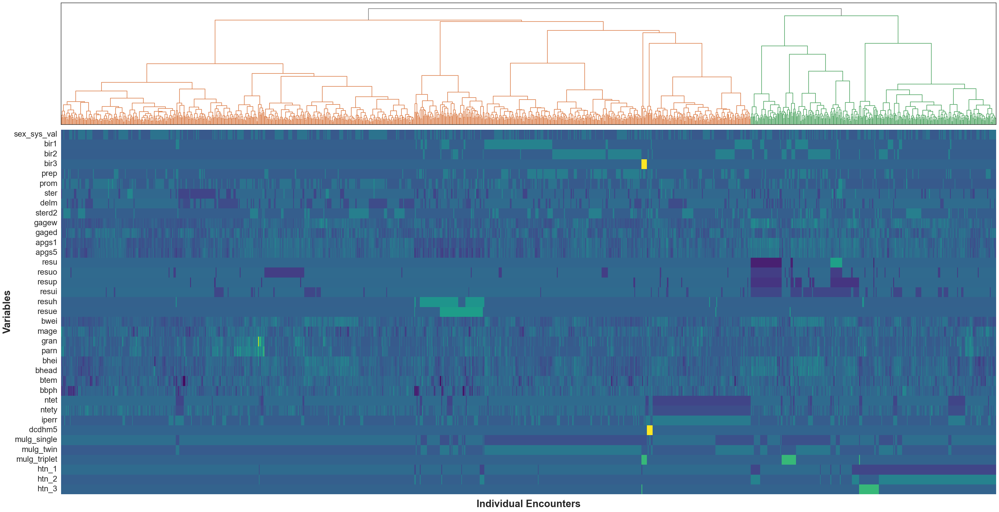

          sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  \
subj_ind                                                                  
0                   0   0.0   0.0   0.0     0     0     1     1     0.0   
17                  0   0.0   0.0   0.0     0     0     1     1     0.0   
29                  1   0.0   1.0   0.0     0     0     1     1     0.0   
40                  0   1.0   0.0   0.0     1     0     1     1     0.0   
50                  0   0.0   0.0   0.0     0     1     1     1     0.0   
...               ...   ...   ...   ...   ...   ...   ...   ...     ...   
14474               0   0.0   0.0   0.0     1     0     0     1     0.0   
14490               1   0.0   0.0   0.0     1     1     1     0     1.0   
14491               0   0.0   1.0   0.0     1     1     1     1     1.0   
14500               1   0.0   0.0   0.0     0     0     1     1     1.0   
14507               1   0.0   0.0   0.0     1     1     1     1     1.0   

          gagew  ...  nt

In [57]:
# Data import
ftd_knn_df = pd.read_csv(f"{raw_path}/knn_p4_fin.csv")
ftd_knn_df.rename(columns={'Unnamed: 0': 'subj_ind'}, inplace=True)
ftd_knn_df.set_index('subj_ind', inplace=True)

# 데이터 표준화 (이진 값을 제외하고 표준화 수행)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ftd_knn_df)

# scaled_data 반영
ftd_scd_knn_df = pd.DataFrame(scaled_data, index=ftd_knn_df.index, columns=ftd_knn_df.columns)

Z_objects = linkage(ftd_scd_knn_df, method='ward')

# 실루엣 점수를 통한 최적의 클러스터 수 찾기
silhouette_scores = []
range_n_clusters = list(range(2, 10))  # 클러스터 수를 2부터 10까지 시도
for n_clusters in range_n_clusters:
    cluster_labels = fcluster(Z_objects, t=n_clusters, criterion='maxclust')
    silhouette_avg = silhouette_score(ftd_scd_knn_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

best_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print("Best number of clusters:", best_n_clusters)

# 최적의 클러스터 수를 사용하여 클러스터 라벨을 다시 할당
final_cluster_labels = fcluster(Z_objects, t=best_n_clusters, criterion='maxclust')

# 덴드로그램 및 히트맵 시각화
sns.set(style="white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(35, 18), gridspec_kw={'height_ratios': [1, 3]})

# Dendrogram
dendro_objects = dendrogram(Z_objects, ax=ax1, orientation='top', color_threshold=0.94 * max(Z_objects[:, 2]), above_threshold_color='grey')
ax1.set_xticks([])
ax1.set_yticks([])

# 데이터 정렬 및 히트맵 추가
sorted_idx = dendro_objects['leaves']
data_sorted = ftd_scd_knn_df.iloc[sorted_idx]

# Heatmap
sns.heatmap(data_sorted.T
            , ax=ax2
            , cbar=False
            , cmap='viridis'
            , yticklabels=ftd_scd_knn_df.columns
           )
ax2.set_xlabel('Individual Encounters', fontsize=25, fontweight='bold')
ax2.set_ylabel('Variables', fontsize=25, fontweight='bold')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=20)  # Y축 레이블의 글자 크기 조절 (축소)

plt.tight_layout()
plt.show()

# 클러스터 라벨을 데이터프레임에 추가
ftd_knn_df['Cluster_Labels'] = final_cluster_labels
# 결과 출력
print(ftd_knn_df)

In [58]:
# len(ftd_knn_df.columns[:-1])
analyse_dataframe(ftd_knn_df)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
bir1,0,0.0,2
bir2,0,0.0,2
bir3,0,0.0,2
prep,0,0.0,2
prom,0,0.0,3
ster,0,0.0,3
delm,0,0.0,2
sterd2,0,0.0,2
gagew,0,0.0,15


In [36]:
print(ftd_knn_df, '\n\n', ftd_scd_knn_df)

          sex_sys_val  bir1  bir2  bir3  prep  prom  ster  delm  sterd2  \
subj_ind                                                                  
0                   0   0.0   0.0   0.0     0     0     1     1     0.0   
17                  0   0.0   0.0   0.0     0     0     1     1     0.0   
29                  1   0.0   1.0   0.0     0     0     1     1     0.0   
40                  0   1.0   0.0   0.0     1     0     1     1     0.0   
50                  0   0.0   0.0   0.0     0     1     1     1     0.0   
...               ...   ...   ...   ...   ...   ...   ...   ...     ...   
14474               0   0.0   0.0   0.0     1     0     0     1     0.0   
14490               1   0.0   0.0   0.0     1     1     1     0     1.0   
14491               0   0.0   1.0   0.0     1     1     1     1     1.0   
14500               1   0.0   0.0   0.0     0     0     1     1     1.0   
14507               1   0.0   0.0   0.0     1     1     1     1     1.0   

          gagew  ...  nt

In [59]:
filtered_knn_df = pd.read_csv(f"{raw_path}/knn_p1.csv")
filtered_knn_df.rename(columns={'Unnamed: 0': 'subj_ind'}, inplace=True)
filtered_knn_df.set_index('subj_ind', inplace=True)
filtered_knn_df.drop('subjnm', axis=1, inplace=True)
filtered_knn_df.rename(columns={'dthage1': 'death_label'}, inplace=True)
filtered_knn_df['death_label'] = filtered_knn_df['death_label'].notna().astype(int)

dthage_data = filtered_knn_df['death_label']
print(dthage_data)

subj_ind
0        0
17       0
29       0
40       0
50       0
        ..
14474    0
14490    0
14491    0
14500    0
14507    0
Name: death_label, Length: 1174, dtype: int32


In [60]:
ftd_knn_df = ftd_knn_df.merge(dthage_data, left_index=True, right_index=True, how='left')
ftd_knn_df

,sex_sys_val,bir1,bir2,bir3,prep,prom,ster,delm,sterd2,gagew,...,iperr,dcdhm5,mulg_single,mulg_twin,mulg_triplet,htn_1,htn_2,htn_3,Cluster_Labels,death_label
subj_ind,,,,,,,,,,,,,,,,,,,,,
0,0,0.0,0.0,0.0,0,0,1,1,0.0,27,...,0,0.0,1,0,0,0,0,1,2,0
17,0,0.0,0.0,0.0,0,0,1,1,0.0,28,...,0,0.0,1,0,0,0,1,0,2,0
29,1,0.0,1.0,0.0,0,0,1,1,0.0,27,...,0,0.0,0,1,0,1,0,0,1,0
40,0,1.0,0.0,0.0,1,0,1,1,0.0,27,...,0,0.0,0,1,0,1,0,0,1,0
50,0,0.0,0.0,0.0,0,1,1,1,0.0,28,...,1,0.0,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14474,0,0.0,0.0,0.0,1,0,0,1,0.0,26,...,0,0.0,1,0,0,0,1,0,2,0
14490,1,0.0,0.0,0.0,1,1,1,0,1.0,25,...,1,0.0,1,0,0,1,0,0,1,0
14491,0,0.0,1.0,0.0,1,1,1,1,1.0,25,...,0,0.0,0,1,0,1,0,0,1,0


In [61]:
ftd_knn_df.describe()
ftd_knn_df.to_csv(f"{crt_path}/knn_standardised_p2+dthage_M02.csv")

In [64]:
ftd_knn_df = pd.read_csv(f"{crt_path}/knn_standardised_p2+dthage_M02.csv", index_col='subj_ind')
print(ftd_knn_df['Cluster_Labels'].value_counts())
print(ftd_knn_df.isnull().sum())

1    865
2    308
Name: Cluster_Labels, dtype: int64
sex_sys_val       0
bir1              0
bir2              0
bir3              0
prep              0
prom              0
ster              0
delm              0
sterd2            0
gagew             0
gaged             0
apgs1             0
apgs5             0
resu              0
resuo             0
resup             0
resui             0
resuh             0
resue             0
bwei              0
mage              0
gran              0
parn              0
bhei              0
bhead             0
btem              0
bbph              0
ntet              0
ntety             0
iperr             0
dcdhm5            0
mulg_single       0
mulg_twin         0
mulg_triplet      0
htn_1             0
htn_2             0
htn_3             0
Cluster_Labels    0
death_label       0
dtype: int64


In [74]:
## WILCOXON TESTING
ftd_knn_df = pd.read_csv(f"{crt_path}/knn_standardised_p2+dthage_M02.csv", index_col='subj_ind')

# 결과 저장을 위한 DataFrame 초기화
stats_df = pd.DataFrame()
p_values_df = pd.DataFrame()

# 각 클러스터 및 변수에 대해 계산
for i in range(1, (best_n_clusters+1)):
    cluster_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] == i]
    outside_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] != i]
    stats = {}
    p_values = {}

    for column in ftd_knn_df.columns[:-2]:  # 'Cluster_Labels'와 'death_label' 컬럼 제외
        u_stat, p_value = mannwhitneyu(cluster_data[column]
                                       , outside_data[column]
                                       , alternative='two-sided'
                                      )
        mean_val = cluster_data[column].mean()
        std_dev = cluster_data[column].std()

        # 평균과 표준편차 저장
        stats[column] = f"{mean_val:.2f} ± {std_dev:.4f}"
        
        # p-value의 조건에 따라 형식 지정
        if p_value < 0.05:
            if p_value < 0.0001:
                formatted_p_value = f"{p_value:.4e}"  # 매우 작은 값에 대해 지수 표현식 사용
            else:
                formatted_p_value = f"{p_value:.4f}"
            p_values[column] = formatted_p_value
        else:
            p_values[column] = "n.s."

    stats_df[f'Cluster {i}'] = pd.Series(stats)
    p_values_df[f'Cluster {i}'] = pd.Series(p_values)

# 결과 출력
print("Mean and Standard Deviation:")
print(stats_df)
print("\nP-values:")
print(p_values_df)

Mean and Standard Deviation:
                      Cluster 1          Cluster 2
sex_sys_val       0.43 ± 0.4960      0.45 ± 0.4981
bir1              0.15 ± 0.3609      0.15 ± 0.3570
bir2              0.17 ± 0.3778      0.21 ± 0.4110
bir3              0.01 ± 0.0896      0.00 ± 0.0000
prep              0.23 ± 0.4233      0.19 ± 0.3967
prom              0.49 ± 0.5205      0.21 ± 0.4611
ster              0.88 ± 0.4135      0.94 ± 0.3788
delm              0.72 ± 0.4503      0.85 ± 0.3602
sterd2            0.20 ± 0.4011      0.19 ± 0.3942
gagew            25.79 ± 2.2013     28.07 ± 2.5603
gaged             2.87 ± 2.0021      2.97 ± 2.0233
apgs1             3.53 ± 1.8262      4.72 ± 1.8721
apgs5             5.89 ± 1.8850      6.98 ± 1.6599
resu              1.00 ± 0.0000      0.91 ± 0.4250
resuo             0.91 ± 0.2816      0.76 ± 0.4259
resup             0.99 ± 0.1170      0.69 ± 0.4626
resui             0.93 ± 0.2600      0.48 ± 0.5005
resuh             0.09 ± 0.2849      0.01 ± 0.0805
re

In [76]:
stats_df.to_excel(f"{crt_path}/knn_wilcoxon_M02_siluette.xlsx")
p_values_df.to_excel(f"{crt_path}/knn_wilcoxon_M02_p_val_siluette.xlsx")

In [73]:
## DEATH RATIO
results_df = pd.DataFrame()

# 각 클러스터의 사망률 계산
for i in range(1, (best_n_clusters+1)):
    # 해당 클러스터 데이터 추출
    cluster_data = ftd_knn_df[ftd_knn_df['Cluster_Labels'] == i]
    total_count = cluster_data.shape[0]
    death_count = cluster_data['death_label'].sum()
    
    # 사망률 계산
    mortality_rate = (death_count / total_count) * 100
    
    # 결과 저장
    results_df.loc[f'Cluster {i}', 'Total'] = total_count
    results_df.loc[f'Cluster {i}', 'Deaths'] = death_count
    results_df.loc[f'Cluster {i}', 'Mortality Rate'] = f"{mortality_rate:.2f}%"
    results_df.loc[f'Cluster {i}', 'Deaths / Total'] = f"{death_count} / {total_count}"

# 결과 출력
print(results_df)

           Total  Deaths Mortality Rate Deaths / Total
Cluster 1  865.0    11.0          1.27%       11 / 865
Cluster 2  308.0     1.0          0.32%        1 / 308



1. blank value & nan value 50% 이하 : 소거
2. 칼럼 '*dt' 등 disease related columns, 'ntet', 'iperr', 'subjnm' 제거
3. 데이터 값들을 one-hot encoding, vector화

4. clustering